# CloudGuardian — Week 2: Detection & Prioritization
## CAP-CSE-3W | IIT Roorkee × Futurense
**Team Name:** ----- | **Account:**
**Scan Date:** 2026-06-28 | **Tools:** Prowler v4, ScoutSuite, Steampipe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

print("✅ Libraries loaded!")
print(f"Pandas version : {pd.__version__}")
print(f"Numpy version  : {np.__version__}")
print(f"Timestamp      : {datetime.now()}")
%pip install imbalanced-learn --break-system-packages --quiet 

✅ Libraries loaded!
Pandas version : 2.2.3
Numpy version  : 2.2.6
Timestamp      : 2026-07-27 14:00:42.706420
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import glob

# ═══════════════════════════════════════════════════════════════════
# SHARED CONFIG — applies to both AWS and Azure, defined once
# ═══════════════════════════════════════════════════════════════════
ACCOUNT_ID    = '735291151388'
REGION        = 'ap-south-1'
SCAN_DATE     = '2026-07-11'
AZURE_SCAN_DATE = '2026-07-04'
TEAM_MEMBERS  = ['Megha', 'Vinay', 'Kedar']
BASE_DIR = "/home/kali/Desktop/Cloudguardian_Capstone"
WEEK1_DIR = os.path.join(BASE_DIR, "1.Week1")

def find_dir(path):
    return path if path and os.path.isdir(path) else None

def find_tool_dir(base_dir, keyword):
    """Finds a sub-folder whose name CONTAINS `keyword` (case-insensitive),
    so it survives naming drift like '1.3steampipe' vs '4.Steampipe'."""
    if not base_dir or not os.path.isdir(base_dir):
        return None
    for entry in sorted(os.listdir(base_dir)):
        full = os.path.join(base_dir, entry)
        if os.path.isdir(full) and keyword.lower() in entry.lower():
            return full
    return None

def find_top_level_csv(dir_path, exclude_keywords=('delta', 'compliance')):
    if not dir_path or not os.path.isdir(dir_path):
        return None
    candidates = sorted(glob.glob(os.path.join(dir_path, "*.csv")))
    candidates = [c for c in candidates
                  if not any(k in os.path.basename(c).lower() for k in exclude_keywords)]
    return candidates[0] if candidates else None

OUTPUT_DIR = os.path.join(BASE_DIR, "2.Week2")
os.makedirs(OUTPUT_DIR, exist_ok=True)
CSV_OUT   = os.path.join(OUTPUT_DIR, "consolidated_findings.csv")
JSON_OUT  = os.path.join(OUTPUT_DIR, "consolidated_findings.json")
LLM_OUT   = os.path.join(OUTPUT_DIR, "llm_remediation_guidance.csv")
CHART_OUT = os.path.join(OUTPUT_DIR, "week2_dashboard.png")

# ═══════════════════════════════════════════════════════════════════
# AWS BLOCK
# ═══════════════════════════════════════════════════════════════════
AWS_ROOT_DIR = find_tool_dir(WEEK1_DIR, "aws")
AWS_MISCONFIG_DIR = find_tool_dir(AWS_ROOT_DIR, "misconfig") if AWS_ROOT_DIR else None

PROWLER_CSV = None
AWS_SCOUTSUITE_DIR = None
AWS_STEAMPIPE_DIR = None

if AWS_MISCONFIG_DIR:
    aws_prowler_dir = find_tool_dir(AWS_MISCONFIG_DIR, "prowler")
    PROWLER_CSV = find_top_level_csv(aws_prowler_dir)

    aws_scoutsuite_tooldir = find_tool_dir(AWS_MISCONFIG_DIR, "scoutsuite")
    AWS_SCOUTSUITE_DIR = find_dir(
        os.path.join(aws_scoutsuite_tooldir, "scoutsuite-results")
    ) if aws_scoutsuite_tooldir else None

    AWS_STEAMPIPE_DIR = find_tool_dir(AWS_MISCONFIG_DIR, "steampipe")

# ═══════════════════════════════════════════════════════════════════
# AZURE BLOCK
# ═══════════════════════════════════════════════════════════════════
AZURE_ROOT_DIR = find_tool_dir(WEEK1_DIR, "azure")
AZURE_MISCONFIG_DIR = find_tool_dir(AZURE_ROOT_DIR, "misconfig") if AZURE_ROOT_DIR else None

AZURE_PROWLER_CSV = None
AZURE_SCOUTSUITE_DIR = None
AZURE_STEAMPIPE_DIR = None
AZURE_ACCOUNT_ID = None

if AZURE_MISCONFIG_DIR:
    azure_prowler_dir = find_tool_dir(AZURE_MISCONFIG_DIR, "prowler")
    AZURE_PROWLER_CSV = find_top_level_csv(azure_prowler_dir)

    azure_scoutsuite_tooldir = find_tool_dir(AZURE_MISCONFIG_DIR, "scoutsuite")
    AZURE_SCOUTSUITE_DIR = find_dir(
        os.path.join(azure_scoutsuite_tooldir, "scoutsuite-results")
    ) if azure_scoutsuite_tooldir else None

    AZURE_STEAMPIPE_DIR = find_tool_dir(AZURE_MISCONFIG_DIR, "steampipe")

    if AZURE_PROWLER_CSV:
        fname = os.path.basename(AZURE_PROWLER_CSV)
        match = re.match(r'prowler-output-(.+?)-\d{8,}\.csv$', fname, re.IGNORECASE)
        AZURE_ACCOUNT_ID = match.group(1) if match else fname

# ═══════════════════════════════════════════════════════════════════
# CLOUD_PROVIDERS
# ═══════════════════════════════════════════════════════════════════
CLOUD_PROVIDERS = []
if PROWLER_CSV or AWS_SCOUTSUITE_DIR or AWS_STEAMPIPE_DIR:
    CLOUD_PROVIDERS.append('AWS')
if AZURE_PROWLER_CSV or AZURE_SCOUTSUITE_DIR or AZURE_STEAMPIPE_DIR:
    CLOUD_PROVIDERS.append('Azure')

if not CLOUD_PROVIDERS:
    raise FileNotFoundError("No scan data found for AWS or Azure.")

# ═══════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════
print("✅ Configuration loaded!")
print(f"Team Members     : {TEAM_MEMBERS}")
print(f"Cloud Providers  : {CLOUD_PROVIDERS}")
print(f"Base Dir         : {BASE_DIR}")
print(f"Scan Date        : {SCAN_DATE}")
print()
print("══ AWS ══" + ("" if 'AWS' in CLOUD_PROVIDERS else "  (not detected)"))
print(f"Account ID       : {ACCOUNT_ID if 'AWS' in CLOUD_PROVIDERS else '—'}")
print(f"Prowler CSV      : {PROWLER_CSV or '❌ Not found'}")
print(f"ScoutSuite dir   : {AWS_SCOUTSUITE_DIR or '❌ Not found'}")
print(f"Steampipe dir    : {AWS_STEAMPIPE_DIR or '❌ Not found'}")
print()
print("══ Azure ══" + ("" if 'Azure' in CLOUD_PROVIDERS else "  (not detected)"))
print(f"Subscription/Tenant : {AZURE_ACCOUNT_ID or '❌ Not found'}")
print(f"Prowler CSV      : {AZURE_PROWLER_CSV or '❌ Not found'}")
print(f"ScoutSuite dir   : {AZURE_SCOUTSUITE_DIR or '❌ Not found'}")
print(f"Steampipe dir    : {AZURE_STEAMPIPE_DIR or '❌ Not found'}")

if len(CLOUD_PROVIDERS) < 2:
    missing = 'Azure' if 'AWS' in CLOUD_PROVIDERS else 'AWS'
    print(f"\n⚠️  Only {', '.join(CLOUD_PROVIDERS)} active — {missing} data not found.")     

✅ Configuration loaded!
Team Members     : ['Megha', 'Vinay', 'Kedar']
Cloud Providers  : ['AWS', 'Azure']
Base Dir         : /home/kali/Desktop/Cloudguardian_Capstone
Scan Date        : 2026-07-11

══ AWS ══
Account ID       : 735291151388
Prowler CSV      : /home/kali/Desktop/Cloudguardian_Capstone/1.Week1/1. AWS/2.misconfig/1.1.Prowler/prowler-misconfig-11July.csv
ScoutSuite dir   : /home/kali/Desktop/Cloudguardian_Capstone/1.Week1/1. AWS/2.misconfig/1.2.scoutsuite/scoutsuite-results
Steampipe dir    : /home/kali/Desktop/Cloudguardian_Capstone/1.Week1/1. AWS/2.misconfig/1.3steampipe

══ Azure ══
Subscription/Tenant : prowler-insecure.csv
Prowler CSV      : /home/kali/Desktop/Cloudguardian_Capstone/1.Week1/2.Azure/2.Misconfig/2.Prowler/prowler-insecure.csv
ScoutSuite dir   : /home/kali/Desktop/Cloudguardian_Capstone/1.Week1/2.Azure/2.Misconfig/3.Scoutsuite/scoutsuite-results
Steampipe dir    : /home/kali/Desktop/Cloudguardian_Capstone/1.Week1/2.Azure/2.Misconfig/4.Steampipe


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — LOAD PROWLER MISCONFIG SCAN RESULTS (AWS + AZURE, TEAM MODE)
# ═══════════════════════════════════════════════════════════════════
# PURPOSE:
# Load raw Prowler v4 CSV output and filter only FAIL findings.
# Prowler uses semicolon (;) as the CSV delimiter — not comma.
#
# TEAM MODE NOTE:
# Supports BOTH AWS and Azure Prowler scans. Loads whichever provider
# file(s) actually exist (checked via os.path.exists() from Cell 2)
# and combines them. If only one provider's file exists, it proceeds
# with that one alone — no crash, no manual code changes needed when
# Azure data arrives later.
#
# OUTPUT:
#   df    → full scan results (ALL statuses, ALL available clouds)
#   fails → only FAIL findings, with a 'cloud_provider' column added
# ═══════════════════════════════════════════════════════════════════

import os
import logging
from typing import Optional, Dict

import pandas as pd

# ── Logging setup (use this instead of print in production pipelines) ──
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger("prowler_loader")

# ── Constants (avoid hardcoded magic strings scattered through code) ──
STATUS_COL = "STATUS"
SEVERITY_COL = "SEVERITY"
STATUS_FAIL = "FAIL"
STATUS_PASS = "PASS"
CSV_DELIMITER = ";"
CSV_ENCODING = "utf-8"

REQUIRED_COLUMNS = {STATUS_COL, SEVERITY_COL}


def load_prowler_csv(csv_path: str, provider_name: str) -> Optional[pd.DataFrame]:
    """
    Load a single Prowler CSV (schema is shared across AWS and Azure).

    Args:
        csv_path: Full path to the Prowler CSV export.
        provider_name: Human-readable cloud provider label, e.g. 'AWS'.

    Returns:
        A DataFrame tagged with a 'cloud_provider' column, or None if
        the file doesn't exist or fails validation.
    """
    
    if not csv_path or not os.path.exists(csv_path):
        logger.warning("%s Prowler CSV not found — skipping (%s)", provider_name, csv_path)
        return None

    try:
        provider_df = pd.read_csv(csv_path, sep=CSV_DELIMITER, encoding=CSV_ENCODING)
    except Exception as exc:
        logger.error("Failed to read %s CSV at %s: %s", provider_name, csv_path, exc)
        return None

    missing_cols = REQUIRED_COLUMNS - set(provider_df.columns)
    if missing_cols:
        logger.error(
            "%s CSV is missing required column(s) %s — skipping. Found columns: %s",
            provider_name, missing_cols, list(provider_df.columns),
        )
        return None

    provider_df["cloud_provider"] = provider_name
    logger.info("%s Prowler CSV loaded — %d total checks", provider_name, len(provider_df))
    return provider_df


# ── Load each provider ──
provider_sources = {
    "AWS": PROWLER_CSV,
    "Azure": AZURE_PROWLER_CSV,
}

loaded_frames: Dict[str, pd.DataFrame] = {
    name: frame
    for name, path in provider_sources.items()
    if (frame := load_prowler_csv(path, name)) is not None
}

if not loaded_frames:
    raise FileNotFoundError("No Prowler CSV found for any cloud provider. Check Cell 2 paths.")

df = pd.concat(loaded_frames.values(), ignore_index=True)

# Filter only FAIL findings (same logic as before, now across all loaded clouds)
fails = df[df[STATUS_COL] == STATUS_FAIL].copy()

# ── Summary ──
logger.info("=" * 55)
logger.info("COMBINED PROWLER RESULTS — %s", ", ".join(loaded_frames.keys()))
logger.info("=" * 55)
logger.info("Total checks run  : %d", len(df))
logger.info("Total FAILs       : %d", len(fails))
logger.info("Total PASSes      : %d", len(df[df[STATUS_COL] == STATUS_PASS]))
logger.info("Columns available : %s", list(df.columns[:8]))

logger.info("FAILs by cloud provider:\n%s", fails["cloud_provider"].value_counts().to_string())
logger.info("Severity Breakdown (FAILs only):\n%s", fails[SEVERITY_COL].value_counts().to_string())
logger.info("Status breakdown (all):\n%s", df[STATUS_COL].value_counts().to_string())  


2026-07-27 14:00:46,391 [INFO] AWS Prowler CSV loaded — 236 total checks
2026-07-27 14:00:46,438 [INFO] Azure Prowler CSV loaded — 195 total checks
2026-07-27 14:00:46,451 [INFO] =======================================================
2026-07-27 14:00:46,453 [INFO] COMBINED PROWLER RESULTS — AWS, Azure
2026-07-27 14:00:46,455 [INFO] =======================================================
2026-07-27 14:00:46,456 [INFO] Total checks run  : 431
2026-07-27 14:00:46,458 [INFO] Total FAILs       : 285
2026-07-27 14:00:46,465 [INFO] Total PASSes      : 142
2026-07-27 14:00:46,467 [INFO] Columns available : ['AUTH_METHOD', 'TIMESTAMP', 'ACCOUNT_UID', 'ACCOUNT_NAME', 'ACCOUNT_EMAIL', 'ACCOUNT_ORGANIZATION_UID', 'ACCOUNT_ORGANIZATION_NAME', 'ACCOUNT_TAGS']
2026-07-27 14:00:46,471 [INFO] FAILs by cloud provider:
cloud_provider
Azure    163
AWS      122
2026-07-27 14:00:46,474 [INFO] Severity Breakdown (FAILs only):
SEVERITY
medium      135
high        110
low          32
critical      8
2026-07-2

In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — CSPM FINDINGS CONSOLIDATION (AWS + AZURE, TEAM MODE)
# AWS Steampipe now also handles the two CloudTrail evidence
# files (CloudTrail_logging_validation_region_coverage.csv,
# CloudTrail_log_bucket_public_check.csv) via a dedicated
# rule-based loader — same pattern as the Azure rule functions.
# ═══════════════════════════════════════════════════════════════════

import os
import re
import json
import glob
import logging
import pandas as pd

logger = logging.getLogger("cspm_consolidator")
if not logger.handlers:
    logging.basicConfig(format="[%(levelname)s] %(message)s")
logger.setLevel(logging.WARNING)

NORMALIZED_COLUMNS = [
    'check_id', 'title', 'severity', 'service', 'region',
    'resource_name', 'resource_arn', 'status_detail',
    'description', 'risk', 'remediation', 'tool', 'cloud_provider',
]

# ═══════════════════════════════════════════════════════════════════
# PART A — PROWLER FINDINGS (unchanged — already combined in Cell 3)
# ═══════════════════════════════════════════════════════════════════
prowler_cols = {
    'CHECK_ID':                        'check_id',
    'CHECK_TITLE':                     'title',
    'SEVERITY':                        'severity',
    'SERVICE_NAME':                    'service',
    'REGION':                          'region',
    'RESOURCE_NAME':                   'resource_name',
    'RESOURCE_UID':                    'resource_arn',
    'STATUS_EXTENDED':                 'status_detail',
    'DESCRIPTION':                     'description',
    'RISK':                            'risk',
    'REMEDIATION_RECOMMENDATION_TEXT': 'remediation',
}

prowler_df = fails.rename(columns=prowler_cols)[list(prowler_cols.values())].copy()
prowler_df['tool'] = 'Prowler v4'
prowler_df['cloud_provider'] = fails['cloud_provider'].values
prowler_df = prowler_df[NORMALIZED_COLUMNS]

logger.info("Part A done — Prowler findings loaded: %d rows", len(prowler_df))
logger.info("  By cloud: %s", dict(prowler_df['cloud_provider'].value_counts()))


# ═══════════════════════════════════════════════════════════════════
# PART B — STEAMPIPE FINDINGS
# ═══════════════════════════════════════════════════════════════════
def _is_true(val) -> bool:
    return str(val).strip().lower() in ('true', 't', 'yes', '1')

def _is_blank(val) -> bool:
    s = str(val).strip().lower()
    return s in ('', 'nan', 'none', 'null')

def _mk(check_id, title, severity, resource_name, status_detail, description, risk,
        remediation, service, cloud_provider):
    return {
        'check_id': check_id, 'title': title, 'severity': severity, 'service': service,
        'region': '', 'resource_name': resource_name, 'resource_arn': '',
        'status_detail': status_detail, 'description': description, 'risk': risk,
        'remediation': remediation, 'tool': 'Steampipe', 'cloud_provider': cloud_provider,
    }

# ── AWS: files are M01_M02_..., M03_..., ..., M12_...csv — one already-confirmed
#         misconfig per file. Each file's presence/rows = evidence for that finding.
AWS_M_CATALOGUE = {
    'M01_M02': dict(check_id='iam_role_inline_policy_wildcard',
        title='IAM Role Inline Policy Uses Wildcard Action/Resource', severity='critical', service='iam',
        description='IAM role has an inline policy granting wildcard (*) actions and/or resources.',
        risk='The role can call any AWS API on any resource — full blast-radius if ever assumed by an attacker.',
        remediation='Scope the inline policy to only the specific actions and resource ARNs the role needs.'),
    'M03': dict(check_id='iam_admin_policy_attached',
        title='IAM Role Has AdministratorAccess Managed Policy Attached', severity='critical', service='iam',
        description='This IAM role has the AWS-managed AdministratorAccess policy attached.',
        risk='If this role (attached to EC2) is compromised, the attacker gets full AWS account control.',
        remediation='Detach AdministratorAccess and replace it with a least-privilege custom policy.'),
    'M04': dict(check_id='s3_public_access_block_disabled',
        title='S3 Block Public Access Disabled', severity='high', service='s3',
        description='All four S3 Block Public Access settings are disabled on this bucket.',
        risk='The bucket can be made public via ACL or bucket policy with no safety net.',
        remediation='Re-enable all four Block Public Access settings at the bucket and account level.'),
    'M05': dict(check_id='s3_versioning_suspended',
        title='S3 Bucket Versioning Suspended', severity='medium', service='s3',
        description='Versioning is suspended on this S3 bucket.',
        risk='Accidental deletion or ransomware/overwrite causes permanent, unrecoverable data loss.',
        remediation='Re-enable versioning on the bucket.'),
    'M06': dict(check_id='sg_ssh_open_to_internet',
        title='Security Group Allows SSH (22) from 0.0.0.0/0', severity='high', service='ec2',
        description='Security group permits inbound SSH from any IP address on the internet.',
        risk='Brute-force / credential-stuffing attacks possible from anywhere.',
        remediation='Restrict SSH ingress to a trusted IP range, VPN, or bastion host.'),
    'M07': dict(check_id='sg_mysql_open_to_internet',
        title='Security Group Allows MySQL (3306) from 0.0.0.0/0', severity='critical', service='ec2',
        description='Security group permits inbound MySQL from any IP address on the internet.',
        risk='Database port is directly reachable and attackable from the internet.',
        remediation='Remove the 0.0.0.0/0 rule; restrict 3306 to the application security group only.'),
    'M08': dict(check_id='rds_publicly_accessible',
        title='RDS Instance Publicly Accessible', severity='critical', service='rds',
        description='RDS instance has publicly_accessible=true.',
        risk='Database gets a public endpoint; reachable directly from the internet.',
        remediation='Set publicly_accessible=false and place the instance in a private subnet.'),
    'M09': dict(check_id='rds_storage_not_encrypted',
        title='RDS Storage Encryption Disabled', severity='high', service='rds',
        description='RDS instance data at rest is not encrypted (storage_encrypted=false).',
        risk='Data is readable if the underlying disk or a snapshot is accessed/shared.',
        remediation='Enable storage encryption (requires snapshot + restore to a new encrypted instance).'),
    'M10': dict(check_id='s3_default_encryption_weak',
        title='S3 Default Encryption Missing/Weak Configuration', severity='medium', service='s3',
        description='S3 bucket default encryption configuration does not enforce strong at-rest encryption.',
        risk='Objects may be stored without adequate encryption at rest.',
        remediation='Enforce SSE-KMS (or at minimum SSE-S3/AES256) as the bucket default encryption.'),
    'M11': dict(check_id='ec2_imdsv1_enabled',
        title='EC2 IMDSv1 Enabled (HttpTokens=optional)', severity='high', service='ec2',
        description='Instance metadata service v1 is enabled without a token requirement.',
        risk='SSRF attacks can steal IAM credentials from the instance metadata endpoint.',
        remediation='Set HttpTokens=required on the instance to enforce IMDSv2.'),
    'M12': dict(check_id='rds_backup_disabled',
        title='RDS Automated Backups Disabled', severity='high', service='rds',
        description='RDS backup_retention_period is 0 — automated backups are off.',
        risk='No automated backups, no point-in-time recovery if data is lost or corrupted.',
        remediation='Set backup_retention_period to at least 7 days.'),
}

def _aws_m_key_from_filename(fname: str):
    base = os.path.basename(fname)
    m = re.match(r'^(M\d{2}(?:_M\d{2})?)_', base, re.IGNORECASE)
    return m.group(1).upper() if m else None


# ── NEW: CloudTrail evidence files — not part of the M01-M12 catalogue,
#         handled as their own rule-set (same pattern as the Azure rules
#         below). Each row can yield MULTIPLE findings (one per weak
#         setting), unlike the M-catalogue which is one-finding-per-file.
def rule_cloudtrail_logging_validation(row):
    out = []
    resource = row.get('name', '')

    if not _is_true(row.get('log_file_validation_enabled')):
        out.append(_mk('cloudtrail_log_file_validation_disabled',
            'CloudTrail Log File Validation Disabled', 'medium', resource,
            f"log_file_validation_enabled={row.get('log_file_validation_enabled')}",
            'CloudTrail log file integrity validation is not enabled on this trail.',
            'Tampering or deletion of delivered log files cannot be reliably detected.',
            'Enable log file validation on the trail to generate digest files for integrity checking.',
            'cloudtrail', 'AWS'))

    if not _is_true(row.get('is_multi_region_trail')):
        out.append(_mk('cloudtrail_not_multi_region',
            'CloudTrail Trail Is Not Multi-Region', 'high', resource,
            f"is_multi_region_trail={row.get('is_multi_region_trail')}",
            'This CloudTrail trail only captures events in its home region.',
            'API activity in other AWS regions goes completely unlogged, creating a blind spot.',
            'Recreate or update the trail with multi-region logging enabled.',
            'cloudtrail', 'AWS'))

    if not _is_true(row.get('include_global_service_events')):
        out.append(_mk('cloudtrail_global_service_events_disabled',
            'CloudTrail Does Not Log Global Service Events', 'medium', resource,
            f"include_global_service_events={row.get('include_global_service_events')}",
            'The trail is not configured to capture events from global services (e.g. IAM, STS).',
            'Changes to IAM users, roles, and policies may not be recorded.',
            'Enable "Include global service events" on the trail.',
            'cloudtrail', 'AWS'))

    if _is_blank(row.get('kms_key_id')):
        out.append(_mk('cloudtrail_logs_not_kms_encrypted',
            'CloudTrail Logs Not Encrypted with Customer-Managed KMS Key', 'medium', resource,
            f"kms_key_id={row.get('kms_key_id')}",
            'No customer-managed KMS key is configured to encrypt delivered log files.',
            'Log files rely on default S3 encryption rather than a CMK with dedicated key policy/audit trail.',
            'Enable SSE-KMS on the trail using a customer-managed key with a restrictive key policy.',
            'cloudtrail', 'AWS'))

    if _is_blank(row.get('log_group_arn')):
        out.append(_mk('cloudtrail_cloudwatch_logs_not_integrated',
            'CloudTrail Not Integrated with CloudWatch Logs', 'high', resource,
            f"log_group_arn={row.get('log_group_arn')}",
            'The trail is not delivering events to a CloudWatch Logs log group.',
            'No real-time monitoring or alerting (e.g. via metric filters/alarms) is possible on trail activity.',
            'Configure the trail to deliver events to a CloudWatch Logs log group.',
            'cloudtrail', 'AWS'))

    return out

def rule_cloudtrail_bucket_public(row):
    out = []
    resource = row.get('bucket_name', '')

    if not _is_true(row.get('block_public_acls')):
        out.append(_mk('cloudtrail_bucket_block_public_acls_disabled',
            'CloudTrail Log Bucket Does Not Block Public ACLs', 'high', resource,
            f"block_public_acls={row.get('block_public_acls')}",
            'The S3 bucket storing CloudTrail logs does not block public ACLs.',
            'The bucket (or objects in it) could be made public via ACL, exposing audit logs.',
            'Enable "Block Public ACLs" on the CloudTrail log bucket.',
            'cloudtrail', 'AWS'))

    if not _is_true(row.get('block_public_policy')):
        out.append(_mk('cloudtrail_bucket_block_public_policy_disabled',
            'CloudTrail Log Bucket Does Not Block Public Bucket Policies', 'high', resource,
            f"block_public_policy={row.get('block_public_policy')}",
            'The S3 bucket storing CloudTrail logs does not block public bucket policies.',
            'A misconfigured bucket policy could expose audit logs to the public internet.',
            'Enable "Block Public Policy" on the CloudTrail log bucket.',
            'cloudtrail', 'AWS'))

    return out

CLOUDTRAIL_RULES = {
    'CloudTrail_logging_validation_region_coverage': rule_cloudtrail_logging_validation,
    'CloudTrail_log_bucket_public_check': rule_cloudtrail_bucket_public,
}

def _cloudtrail_key_from_filename(fname: str):
    base = re.sub(r'\.csv$', '', os.path.basename(fname), flags=re.IGNORECASE)
    return base if base in CLOUDTRAIL_RULES else None


def load_aws_steampipe_findings(folder_path: str) -> pd.DataFrame:
    if not folder_path or not os.path.isdir(folder_path):
        logger.warning("AWS Steampipe folder not found — skipping (%s)", folder_path)
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)

    csv_files = sorted(glob.glob(os.path.join(folder_path, '*.csv')))
    rows = []
    for csv_path in csv_files:
        fname = os.path.basename(csv_path)

        # ── NEW: try CloudTrail rule-set first ──
        ct_key = _cloudtrail_key_from_filename(fname)
        if ct_key is not None:
            try:
                raw = pd.read_csv(csv_path)
            except Exception as exc:
                logger.error("Failed to read %s: %s", csv_path, exc)
                continue
            if raw.empty:
                logger.info("  AWS Steampipe (CloudTrail): %s is empty (0 rows) — skipping", fname)
                continue
            rule_fn = CLOUDTRAIL_RULES[ct_key]
            count = 0
            for _, row in raw.iterrows():
                found = rule_fn(row)
                rows.extend(found)
                count += len(found)
            logger.info("  AWS Steampipe (CloudTrail: %s): %d row(s) -> %d finding(s)",
                        fname, len(raw), count)
            continue

        # ── existing M01-M12 catalogue path (unchanged) ──
        key = _aws_m_key_from_filename(csv_path)
        meta = AWS_M_CATALOGUE.get(key)
        if meta is None:
            logger.warning("  AWS Steampipe: no catalogue entry for %s (key=%s) — skipping", fname, key)
            continue
        try:
            raw = pd.read_csv(csv_path)
        except Exception as exc:
            logger.error("Failed to read %s: %s", csv_path, exc)
            continue
        if raw.empty:
            logger.info("  AWS Steampipe: %s is empty (0 rows) — no evidence captured, skipping", fname)
            continue
        for _, row in raw.iterrows():
            resource_col = next((c for c in row.index if c in
                                  ('role_name', 'bucket_name', 'group_name',
                                   'db_instance_identifier', 'instance_id', 'name')), row.index[0])
            resource_name = str(row.get(resource_col, ''))
            status_detail = ', '.join(f"{c}={row[c]}" for c in row.index
                                       if pd.notna(row[c]) and str(row[c]).strip() != '')
            rows.append(_mk(meta['check_id'], meta['title'], meta['severity'], resource_name,
                             status_detail, meta['description'], meta['risk'], meta['remediation'],
                             meta['service'], 'AWS'))
        logger.info("  AWS Steampipe (%s): %d row(s) -> %d finding(s)", fname, len(raw), len(raw))

    if not rows:
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)
    return pd.DataFrame(rows)[NORMALIZED_COLUMNS]


# ── Azure: steampipe_<service>.csv — six services, six different schemas ──
def rule_azure_compute(row):
    out = []
    finding, value = str(row.get('finding', '')).strip(), str(row.get('value', '')).strip()
    if finding == 'password_auth_enabled' and _is_true(value):
        out.append(_mk('vm_password_auth_enabled', 'VM Allows SSH Password Authentication', 'high',
            row.get('resource', ''), f"{finding}={value}",
            'SSH password authentication is enabled instead of key-only.',
            'Weak/brute-forceable passwords can be used to log into the VM.',
            'Disable password authentication; require SSH key-based login only.', 'compute', 'Azure'))
    return out

def rule_azure_iam(row):
    out = []
    finding = str(row.get('finding', '')).strip()
    resource = f"{row.get('principal_type', '')}:{row.get('role_name', '')}"
    if finding == 'owner_at_rg_scope':
        out.append(_mk('iam_owner_role_at_rg_scope', 'Owner Role Assigned at Resource Group Scope', 'critical',
            resource, f"scope={row.get('scope', '')}",
            'A principal has the Owner role at the resource group scope.',
            'Owner allows full control including IAM changes — over-privileged for most identities.',
            'Replace with a scoped, least-privilege role (e.g. Contributor limited to needed resources).',
            'iam', 'Azure'))
    elif finding == 'vm_identity_over_privileged':
        out.append(_mk('vm_identity_over_privileged', 'VM Managed Identity Over-Privileged at Subscription Scope',
            'critical', resource, f"scope={row.get('scope', '')}",
            "The VM's system-assigned managed identity has Contributor at the subscription scope.",
            'If the VM is compromised, the attacker inherits Contributor over the entire subscription.',
            'Scope the role assignment down to only the resource group/resources the VM needs.',
            'iam', 'Azure'))
    return out

def rule_azure_logging(row):
    out = []
    resource = row.get('resource', '')
    finding, value = str(row.get('finding', '')).strip(), str(row.get('value', '')).strip()
    if finding in ('storage_diagnostic_setting', 'sql_diagnostic_setting') and value.upper() == 'MISSING':
        svc = 'Storage account' if 'storage' in finding else 'SQL database'
        out.append(_mk(f'{finding}_missing', f'{svc} Diagnostic Logging Not Configured', 'high',
            resource, f"{finding}={value}",
            f'{svc} has no diagnostic setting sending logs to Log Analytics.',
            'Activity on this resource is not captured, hindering incident detection/investigation.',
            'Add a diagnostic setting forwarding logs to the Log Analytics workspace.', 'logging', 'Azure'))
    elif finding == 'retention_in_days':
        try:
            days = int(value)
        except ValueError:
            days = None
        if days is not None and days < 90:
            out.append(_mk('log_retention_short', 'Log Analytics Retention Below Recommended 90 Days', 'medium',
                resource, f"{finding}={value}",
                f'Log Analytics workspace retention is set to {value} days.',
                'Shorter retention limits how far back an investigation can look after a breach.',
                'Increase retention_in_days to 90 (or per your compliance requirement).', 'logging', 'Azure'))
    return out

def rule_azure_nsg(row):
    resource = row.get('resource', '')
    finding, value = str(row.get('finding', '')).strip(), str(row.get('value', '')).strip()
    NSG_RULES = {
        'ssh_open_to_internet': ('sg_ssh_open_to_internet', 'NSG Allows SSH from Any Source', 'high',
            'NSG rule allows inbound SSH from any source address.',
            'Brute-force/credential-stuffing attacks possible from anywhere.',
            'Restrict the source to a trusted IP/CIDR (e.g. your admin IP) only.'),
        'allow_any_any': ('nsg_allow_any_any', 'NSG Allows Any Protocol/Port from Any Source', 'critical',
            'NSG has a rule permitting all protocols and ports from any source.',
            'Provides effectively no network-layer filtering — full exposure.',
            'Remove the any/any rule; add explicit rules scoped to required ports and sources.'),
        'nsg_association_removed': ('nsg_not_attached', 'Subnet Has No NSG Attached', 'high',
            'The subnet has no Network Security Group associated with it.',
            'No network-layer filtering exists in front of resources in this subnet.',
            'Attach an appropriately scoped NSG to the subnet.'),
        'nsg_association_missing': ('nsg_not_attached', 'Subnet Has No NSG Attached', 'high',
            'The subnet has no Network Security Group associated with it.',
            'No network-layer filtering exists in front of resources in this subnet.',
            'Attach an appropriately scoped NSG to the subnet.'),
    }
    if finding in NSG_RULES:
        check_id, title, sev, desc, risk, rem = NSG_RULES[finding]
        return [_mk(check_id, title, sev, resource, f"{finding}={value}", desc, risk, rem, 'nsg', 'Azure')]
    return []

def rule_azure_sql(row):
    out = []
    resource = row.get('server_name', '')
    start_ip, end_ip = str(row.get('start_ip', '')), str(row.get('end_ip', ''))
    if start_ip == '0.0.0.0' and end_ip == '255.255.255.255':
        out.append(_mk('sql_firewall_allow_all_ips', 'SQL Server Firewall Allows All IPs', 'critical',
            resource, f"firewall_rule={row.get('firewall_rule_name', '')}, range={start_ip}-{end_ip}",
            'A firewall rule opens the SQL server to every IP address on the internet.',
            'The database is directly reachable and attackable from anywhere.',
            'Remove the all-IPs rule; scope firewall rules to specific known IPs/VNets.', 'sql', 'Azure'))
    if not _is_true(row.get('tde_enabled', 'true')):
        out.append(_mk('sql_tde_disabled', 'SQL Transparent Data Encryption Disabled', 'high',
            resource, f"tde_enabled={row.get('tde_enabled')}",
            'Transparent Data Encryption is not enabled on the SQL database.',
            'Data at rest is not encrypted; readable if underlying storage/backups are accessed.',
            'Enable TDE on the SQL database.', 'sql', 'Azure'))
    min_tls = str(row.get('min_tls', '')).strip()
    if min_tls and min_tls not in ('1.2', '1.3'):
        out.append(_mk('sql_min_tls_outdated', 'SQL Server Minimum TLS Version Below 1.2', 'medium',
            resource, f"min_tls={min_tls}",
            f'SQL server minimum TLS version is set to {min_tls}.',
            'Outdated TLS versions permit weaker transport encryption.',
            'Set the minimum TLS version to 1.2.', 'sql', 'Azure'))
    if not _is_true(row.get('auditing_enabled', 'true')):
        out.append(_mk('sql_auditing_disabled', 'SQL Server Auditing Disabled', 'medium',
            resource, f"auditing_enabled={row.get('auditing_enabled')}",
            'Auditing is not enabled on the SQL server.',
            'Query/access activity on the database is not logged for investigation.',
            'Enable SQL Server auditing and send logs to Log Analytics/Storage.', 'sql', 'Azure'))
    return out

def rule_azure_storage(row):
    resource = row.get('name', '')
    checks = [
        (_is_true(row.get('allow_blob_public_access')), 'storage_allow_blob_public_access',
         'Storage Account Allows Public Blob Access', 'high',
         'allow_blob_public_access=true — the account permits containers/blobs to be made public.',
         'Combined with a public container ACL, data becomes readable by anyone on the internet.',
         'Set allow_blob_public_access=false at the storage account level.'),
        (str(row.get('public_network_access', '')).strip().lower() == 'allow', 'storage_public_network_access',
         'Storage Account Reachable From Any Network', 'high',
         'public_network_access=Allow — not restricted to VNet or trusted IPs.',
         'The storage account can be reached from any network on the internet.',
         'Set public_network_access to Disabled, or restrict via firewall/VNet rules.'),
        (not _is_true(row.get('enable_https_traffic_only', 'true')), 'storage_secure_transfer_disabled',
         'Storage Account Does Not Require HTTPS', 'high',
         'enable_https_traffic_only=false — plain HTTP is permitted.',
         'Data can be transmitted unencrypted between client and storage.',
         'Set enable_https_traffic_only=true (Secure transfer required).'),
        (str(row.get('minimum_tls_version', '')).strip().upper() not in ('TLS1_2', 'TLS1_3', ''),
         'storage_min_tls_outdated', 'Storage Account Minimum TLS Version Below 1.2', 'medium',
         f"minimum_tls_version={row.get('minimum_tls_version')}.",
         'Outdated TLS versions permit weaker transport encryption.',
         'Set minimum_tls_version to TLS1_2.'),
        (not _is_true(row.get('default_to_oauth_authentication', 'true')), 'storage_shared_key_access_default',
         'Storage Account Defaults to Shared Key Auth Instead of Entra ID', 'medium',
         'default_to_oauth_authentication=false — tools/portal default to Shared Key auth.',
         'Shared Key access is harder to audit/revoke per-identity than Entra ID (Azure AD) auth.',
         'Set default_to_oauth_authentication=true to prefer Entra ID authentication.'),
        (str(row.get('container_access_type', '')).strip().lower() in ('blob', 'container'),
         'storage_public_container', 'Blob Container Is Publicly Readable', 'critical',
         f"container_name={row.get('container_name')}, container_access_type={row.get('container_access_type')}.",
         'Anyone on the internet can read (or list) objects in this container.',
         'Set the container access level to Private and use SAS tokens/Entra ID for access.'),
    ]
    out = []
    for is_bad, check_id, title, sev, status_detail, risk, remediation in checks:
        if is_bad:
            out.append(_mk(check_id, title, sev, resource, status_detail,
                            title, risk, remediation, 'storage', 'Azure'))
    return out

AZURE_STEAMPIPE_RULES = {
    'compute': rule_azure_compute,
    'iam':     rule_azure_iam,
    'logging': rule_azure_logging,
    'nsg':     rule_azure_nsg,
    'sql':     rule_azure_sql,
    'storage': rule_azure_storage,
}

def load_azure_steampipe_findings(folder_path: str) -> pd.DataFrame:
    if not folder_path or not os.path.isdir(folder_path):
        logger.warning("Azure Steampipe folder not found — skipping (%s)", folder_path)
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)

    csv_files = sorted(glob.glob(os.path.join(folder_path, 'steampipe_*.csv')))
    all_rows = []
    for csv_path in csv_files:
        base = re.sub(r'\.csv$', '', re.sub(r'^steampipe_', '', os.path.basename(csv_path), flags=re.I), flags=re.I)
        rule_fn = AZURE_STEAMPIPE_RULES.get(base)
        if rule_fn is None:
            logger.warning("  Azure Steampipe: no rule for '%s' (%s) — skipping", base, os.path.basename(csv_path))
            continue
        try:
            raw = pd.read_csv(csv_path)
        except Exception as exc:
            logger.error("Failed to read %s: %s", csv_path, exc)
            continue
        count = 0
        for _, row in raw.iterrows():
            found = rule_fn(row)
            all_rows.extend(found)
            count += len(found)
        logger.info("  Azure Steampipe (%s): %d row(s) -> %d finding(s)", base, len(raw), count)

    if not all_rows:
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)
    return pd.DataFrame(all_rows)[NORMALIZED_COLUMNS]


steampipe_df = pd.concat(
    [load_aws_steampipe_findings(AWS_STEAMPIPE_DIR),
     load_azure_steampipe_findings(AZURE_STEAMPIPE_DIR)],
    ignore_index=True,
)
logger.info("Part B done — Steampipe total: %d rows (AWS + Azure)", len(steampipe_df))


# ═══════════════════════════════════════════════════════════════════
# PART C — SCOUTSUITE FINDINGS (unchanged — your JS schema already matched)
# ═══════════════════════════════════════════════════════════════════
SCOUTSUITE_LEVEL_TO_SEVERITY = {'danger': 'high', 'warning': 'medium', 'good': 'low'}
_RESOURCE_ID_PATTERN = re.compile(r'\b((?:sg|vol|vpc|subnet|acl|i|scoutid)-[a-zA-Z0-9]+)\b')

def _resource_name_from_item(item_path: str) -> str:
    m = _RESOURCE_ID_PATTERN.search(item_path)
    return m.group(1) if m else item_path

def load_scoutsuite_findings(results_dir: str, provider_name: str) -> pd.DataFrame:
    if not results_dir or not os.path.isdir(results_dir):
        logger.warning("%s ScoutSuite results folder not found — skipping (%s)", provider_name, results_dir)
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)

    js_files = sorted(glob.glob(os.path.join(results_dir, 'scoutsuite_results_*.js')))
    if not js_files:
        logger.warning("%s ScoutSuite results file not found in %s", provider_name, results_dir)
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)

    js_path = js_files[0]
    try:
        with open(js_path, 'r', encoding='utf-8') as f:
            raw_text = f.read()
    except Exception as exc:
        logger.error("Failed to read %s: %s", js_path, exc)
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)

    match = re.search(r'=\s*(\{.*\})\s*;?\s*$', raw_text, re.DOTALL)
    if not match:
        logger.error("Could not locate JSON object inside %s", js_path)
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)

    try:
        data = json.loads(match.group(1))
    except Exception as exc:
        logger.error("Failed to parse JSON from %s: %s", js_path, exc)
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)

    rows = []
    for service_name, service_data in (data.get('services', {}) or {}).items():
        for finding_id, finding in ((service_data or {}).get('findings', {}) or {}).items():
            flagged_count = finding.get('flagged_items', 0) or 0
            if flagged_count == 0:
                continue
            items = finding.get('items') or ['(see ScoutSuite HTML report for resource list)']
            severity = SCOUTSUITE_LEVEL_TO_SEVERITY.get((finding.get('level') or '').lower(), 'medium')
            description = finding.get('description', '')
            for item in items:
                item_path = str(item)
                rows.append({
                    'check_id': finding_id, 'title': description, 'severity': severity,
                    'service': service_name, 'region': '',
                    'resource_name': _resource_name_from_item(item_path), 'resource_arn': '',
                    'status_detail': item_path, 'description': description,
                    'risk': finding.get('rationale', ''), 'remediation': finding.get('remediation', ''),
                    'tool': 'ScoutSuite', 'cloud_provider': provider_name,
                })

    if not rows:
        logger.warning("%s ScoutSuite: no flagged findings found in %s", provider_name, js_path)
        return pd.DataFrame(columns=NORMALIZED_COLUMNS)

    combined = pd.DataFrame(rows)[NORMALIZED_COLUMNS]
    logger.info("%s ScoutSuite findings loaded — %d flagged rows from %s",
                provider_name, len(combined), os.path.basename(js_path))
    return combined


scoutsuite_df = pd.concat(
    [load_scoutsuite_findings(AWS_SCOUTSUITE_DIR, 'AWS'),
     load_scoutsuite_findings(AZURE_SCOUTSUITE_DIR, 'Azure')],
    ignore_index=True,
)
logger.info("Part C done — ScoutSuite total: %d rows", len(scoutsuite_df))


# ═══════════════════════════════════════════════════════════════════
# PART D — MERGE ALL THREE SOURCES INTO ONE DATABASE
# ═══════════════════════════════════════════════════════════════════
consolidated = pd.concat([prowler_df, steampipe_df, scoutsuite_df], ignore_index=True)

consolidated['finding_id'] = [f"FND-{str(i+1).zfill(4)}" for i in range(len(consolidated))]

consolidated['account_id'] = consolidated['cloud_provider'].map({
    'AWS': ACCOUNT_ID,
    'Azure': 'Azure-Subscription',
})
consolidated['scan_date'] = consolidated['cloud_provider'].map({
    'AWS': SCAN_DATE,
    'Azure': AZURE_SCAN_DATE,   # make sure Cell 2 defines this — see note above
})

if consolidated['cloud_provider'].nunique() < 2:
    logger.warning("Only %s present — team-mode rubric requires 2 cloud providers.",
                    list(consolidated['cloud_provider'].unique()))

# ═══════════════════════════════════════════════════════════════════
# CLEAN SUMMARY — report-ready output (replaces raw logger dump)
# ═══════════════════════════════════════════════════════════════════
sev_order = ['critical', 'high', 'medium', 'low']
sev_counts = (consolidated['severity'].str.lower()
              .value_counts().reindex(sev_order).fillna(0).astype(int))

tool_table = consolidated['tool'].value_counts().rename_axis('Tool').reset_index(name='Findings')
cloud_table = consolidated['cloud_provider'].value_counts().rename_axis('Cloud').reset_index(name='Findings')
pivot = pd.crosstab(consolidated['cloud_provider'], consolidated['severity'].str.lower())
pivot = pivot.reindex(columns=[c for c in sev_order if c in pivot.columns])

print("═" * 60)
print("CSPM FINDINGS CONSOLIDATION — SUMMARY")
print("═" * 60)
print(f"\nTotal consolidated findings : {len(consolidated)}")
print(f"  • Prowler v4   : {len(prowler_df)}")
print(f"  • Steampipe    : {len(steampipe_df)}")
print(f"  • ScoutSuite   : {len(scoutsuite_df)}")

print("\nBy severity:")
for sev in sev_order:
    print(f"  {sev.capitalize():<10}: {sev_counts[sev]}")

print("\nBy cloud provider:")
print(cloud_table.to_string(index=False))

print("\nSeverity × Cloud:")
print(pivot.to_string())

print("\nTop 10 services by finding count:")
print(consolidated['service'].value_counts().head(10).to_string())

#print("\n" + "═" * 60)
#display(consolidated.head(10)) 

════════════════════════════════════════════════════════════
CSPM FINDINGS CONSOLIDATION — SUMMARY
════════════════════════════════════════════════════════════

Total consolidated findings : 729
  • Prowler v4   : 285
  • Steampipe    : 37
  • ScoutSuite   : 407

By severity:
  Critical  : 17
  High      : 165
  Medium    : 515
  Low       : 32

By cloud provider:
Cloud  Findings
  AWS       496
Azure       233

Severity × Cloud:
severity        critical  high  medium  low
cloud_provider                             
AWS                    8    70     392   26
Azure                  9    95     123    6

Top 10 services by finding count:
service
vpc           212
ec2           121
cloudtrail     37
storage        36
iam            35
defender       31
network        27
monitor        26
rds            24
entra          20


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — PRIORITIZATION MODEL (Rule-Based, Multi-Cloud, No AI)
# ═══════════════════════════════════════════════════════════════════
# PURPOSE:
# Assign a numeric Priority Score to every finding (AWS + Azure) using:
#   Priority Score = CVSS Score × Exposure Score × Blast Radius
#
# FEATURE JUSTIFICATION (per capstone rubric §7 — "Justified features,
# honest evaluation"):
#   CVSS Score     → Industry standard severity rating (NVD/CVSS v3.1)
#   Exposure Score → How reachable is the resource from the internet?
#   Blast Radius   → How much damage if this finding is exploited?
#
# BUGFIX (this version): keyword matching on title/status_detail was
#   negation-blind — a PASSING/secure finding whose title reads
#   "does not allow X from the internet" was being scored as if it
#   WERE exposed, because the raw substring "internet" still matched.
#   Fixed via a negation-aware keyword scan (_keyword_hit) that looks
#   for cues like "not", "no ", "n't", "restrict", "block", "prevent"
#   in the ~25 characters immediately preceding a keyword hit, and
#   skips the match if found.
#
# MULTI-CLOUD DESIGN NOTE:
#   AWS and Azure use different service-naming conventions for
#   equivalent capabilities (e.g. AWS IAM ≈ Azure Entra ID,
#   AWS S3 ≈ Azure Storage, AWS CloudWatch ≈ Azure Monitor).
#   The blast-radius heuristic below explicitly maps both vocabularies
#   to the same risk tier so that severity scoring is not biased
#   toward whichever cloud happens to use AWS-style naming. This is
#   documented here as a known heuristic limitation — a production
#   system would use each provider's native resource-type taxonomy
#   instead of keyword matching.
#
# SCORE RANGES:
#   Min possible = 3.0  × 1 × 1 =   3.0  (low, internal, minimal)
#   Max possible = 9.5  × 3 × 5 = 142.5  (critical, internet, IAM/Entra admin)
# ═══════════════════════════════════════════════════════════════════

import logging
from tabulate import tabulate

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger("CloudGuardian.Prioritization")

# ── CONFIG: Scoring constants ──────────────────────────────────────
CVSS_SCORE_MAP = {
    'critical': 9.5,
    'high'    : 7.5,
    'medium'  : 5.5,
    'low'     : 3.0,
}
CVSS_DEFAULT_SCORE = 3.0

EXPOSURE_KEYWORDS_DIRECT    = ['0.0.0.0', 'publicly', 'internet', 'public']
EXPOSURE_KEYWORDS_POTENTIAL = ['public', 'exposed', 'internet', 'open']

# Negation cues checked in the text immediately BEFORE a keyword hit.
# If found, the keyword match is treated as a false positive (the
# finding is describing a SECURE/compliant state, not a risk).
NEGATION_CUES = [
    'not ', 'no ', "n't", 'without ', 'never ',
    'restrict', 'block', 'prevent', 'disallow', 'deny', 'protects against',
]
NEGATION_WINDOW = 45  # chars scanned before the keyword

def _keyword_hit(text: str, keywords: list) -> bool:
    """Negation-aware substring match: a keyword only 'counts' if it is
    not immediately preceded by a negation cue."""
    text = str(text).lower()
    for kw in keywords:
        start = 0
        while True:
            idx = text.find(kw, start)
            if idx == -1:
                break
            window = text[max(0, idx - NEGATION_WINDOW): idx]
            if not any(neg in window for neg in NEGATION_CUES):
                return True
            start = idx + len(kw)  # keep scanning past this negated hit
    return False

# ── Cross-cloud service equivalence mapping ────────────────────────
IAM_SERVICE_NAMES = ['iam', 'entra']
DATABASE_SERVICE_NAMES = ['rds', 'sql', 'sqlserver']
BLAST_RADIUS_HIGH_RISK_SERVICES = [
    's3', 'rds', 'ec2', 'cloudtrail', 'vpc', 'cloudwatch',
    'storage', 'monitor', 'network', 'sql', 'defender', 'keyvault', 'sqlserver',
]
IAM_ESCALATION_KEYWORDS = ['admin', 'wildcard', '*', 'global admin', 'owner']

PRIORITY_THRESHOLDS = {
    'P0 - CRITICAL': 100,
    'P1 - HIGH'    : 60,
    'P2 - MEDIUM'  : 30,
}
BAND_EMOJI = {
    'P0 - CRITICAL': '🔴',
    'P1 - HIGH'    : '🟠',
    'P2 - MEDIUM'  : '🟡',
    'P3 - LOW'     : '🟢',
}

# ── STEP 0: Input validation ───────────────────────────────────────
REQUIRED_COLUMNS = ['severity', 'service', 'title', 'status_detail', 'cloud_provider']
missing_cols = [c for c in REQUIRED_COLUMNS if c not in consolidated.columns]
if missing_cols:
    raise KeyError(f"consolidated DataFrame is missing required column(s): {missing_cols}")

severity_lower = consolidated['severity'].astype(str).str.lower()
unmapped_severities = set(severity_lower) - set(CVSS_SCORE_MAP.keys())
if unmapped_severities:
    affected = severity_lower.isin(unmapped_severities).sum()
    logger.warning(
        f"{affected} finding(s) have unmapped severity value(s) {unmapped_severities} "
        f"— defaulting to CVSS {CVSS_DEFAULT_SCORE}. Verify scan tool severity labels."
    )

# ── STEP 1: CVSS Score Mapping ────────────────────────────────────
consolidated['cvss_score'] = severity_lower.map(CVSS_SCORE_MAP).fillna(CVSS_DEFAULT_SCORE)

# ── STEP 2: Exposure Score (negation-aware) ────────────────────────
def exposure_score(row):
    detail = row.get('status_detail', '')
    title  = row.get('title', '')

    if _keyword_hit(detail, EXPOSURE_KEYWORDS_DIRECT):
        return 3
    if _keyword_hit(title, EXPOSURE_KEYWORDS_POTENTIAL):
        return 2
    return 1

# ── STEP 3: Blast Radius (cloud-agnostic, negation-aware) ─────────
def blast_radius(row):
    svc   = str(row.get('service', '')).lower()
    title = row.get('title', '')

    if svc in IAM_SERVICE_NAMES and _keyword_hit(title, IAM_ESCALATION_KEYWORDS):
        return 5
    if svc in IAM_SERVICE_NAMES:
        return 4
    if svc in DATABASE_SERVICE_NAMES and _keyword_hit(title, ['public']):
        return 4
    if svc in BLAST_RADIUS_HIGH_RISK_SERVICES:
        return 3
    return 2

consolidated['exposure_score'] = consolidated.apply(exposure_score, axis=1)
consolidated['blast_radius']   = consolidated.apply(blast_radius,   axis=1)

# ── STEP 4: Calculate Final Priority Score ────────────────────────
consolidated['priority_score'] = (
    consolidated['cvss_score']     *
    consolidated['exposure_score'] *
    consolidated['blast_radius']
).round(2)

# ── STEP 5: Assign Priority Band ─────────────────────────────────
def priority_band(score):
    if score >= PRIORITY_THRESHOLDS['P0 - CRITICAL']: return 'P0 - CRITICAL'
    if score >= PRIORITY_THRESHOLDS['P1 - HIGH']:      return 'P1 - HIGH'
    if score >= PRIORITY_THRESHOLDS['P2 - MEDIUM']:    return 'P2 - MEDIUM'
    return 'P3 - LOW'

consolidated['priority_band'] = consolidated['priority_score'].apply(priority_band)

# ── STEP 6: Sort by Priority Score (highest first) ────────────────
consolidated.sort_values('priority_score', ascending=False, inplace=True)
consolidated.reset_index(drop=True, inplace=True)

logger.info(f"Prioritization complete — {len(consolidated)} findings scored across "
            f"{consolidated['cloud_provider'].nunique()} cloud provider(s).")

# ═══════════════════════════════════════════════════════════════════
# STEP 7: DISPLAY — cleaner, reader-friendly layout
# ═══════════════════════════════════════════════════════════════════
band_counts = consolidated['priority_band'].value_counts()
p0 = band_counts.get('P0 - CRITICAL', 0)
p1 = band_counts.get('P1 - HIGH', 0)
p2 = band_counts.get('P2 - MEDIUM', 0)
p3 = band_counts.get('P3 - LOW', 0)
total = len(consolidated)

aws_count   = (consolidated['cloud_provider'] == 'AWS').sum()
azure_count = (consolidated['cloud_provider'] == 'Azure').sum()

def pct(n, d):
    return f"{(n / d * 100):.1f}%" if d else "0.0%"

HR = "═" * 72

print(HR)
print("CLOUDGUARDIAN — MULTI-CLOUD PRIORITY SCORING RESULTS")
print(HR)
print(f"AWS Account   : {ACCOUNT_ID}   |   Region: {REGION}")
print(f"Total findings: {total}   (AWS {aws_count} · Azure {azure_count})")

print("\n" + "─" * 72)
print("PRIORITY DISTRIBUTION")
print("─" * 72)
distribution_table = [
    ["🔴 P0 - CRITICAL", f"≥ {PRIORITY_THRESHOLDS['P0 - CRITICAL']}",                         p0, pct(p0, total)],
    ["🟠 P1 - HIGH",     f"{PRIORITY_THRESHOLDS['P1 - HIGH']}–99",                             p1, pct(p1, total)],
    ["🟡 P2 - MEDIUM",   f"{PRIORITY_THRESHOLDS['P2 - MEDIUM']}–59",                           p2, pct(p2, total)],
    ["🟢 P3 - LOW",      f"< {PRIORITY_THRESHOLDS['P2 - MEDIUM']}",                            p3, pct(p3, total)],
]
print(tabulate(distribution_table, headers=["Band", "Score Range", "Findings", "% of Total"],
               tablefmt="simple", colalign=("left", "center", "right", "right")))

print("\n" + "─" * 72)
print("PRIORITY BAND BY CLOUD PROVIDER")
print("─" * 72)
cross_tab = pd.crosstab(consolidated['cloud_provider'], consolidated['priority_band'])
for band in ['P0 - CRITICAL', 'P1 - HIGH', 'P2 - MEDIUM', 'P3 - LOW']:
    if band not in cross_tab.columns:
        cross_tab[band] = 0
cross_tab = cross_tab[['P0 - CRITICAL', 'P1 - HIGH', 'P2 - MEDIUM', 'P3 - LOW']]
cross_tab['Total'] = cross_tab.sum(axis=1)
print(tabulate(cross_tab, headers=['Cloud', '🔴 P0', '🟠 P1', '🟡 P2', '🟢 P3', 'Total'],
               tablefmt="simple", colalign=("left",) + ("right",) * 5))

print("\n" + "─" * 72)
print(f"TOP 15 HIGHEST PRIORITY FINDINGS  (out of {total} total)")
print("─" * 72)
top15 = consolidated.head(15).copy()
top15['cloud_tag'] = top15['cloud_provider'].apply(lambda c: f"[{c}]")

TITLE_MAXLEN = 52
top15['title_display'] = top15['title'].apply(
    lambda t: (str(t)[:TITLE_MAXLEN - 1] + '…') if len(str(t)) > TITLE_MAXLEN else t
)
top15['band_display'] = top15['priority_band'].apply(lambda b: f"{BAND_EMOJI.get(b, '')} {b}")

print(tabulate(
    top15[['finding_id', 'cloud_tag', 'severity', 'priority_score', 'band_display', 'title_display']],
    headers=['#', 'ID', 'Cloud', 'Severity', 'Score', 'Band', 'Title'],
    tablefmt='psql',
    showindex=range(1, len(top15) + 1),
))

print(f"\n💡 Full sortable results are in the `consolidated` DataFrame "
      f"({total} rows) — export or filter as needed for the report.") 

2026-07-27 14:00:47,392 [INFO] Prioritization complete — 729 findings scored across 2 cloud provider(s).


════════════════════════════════════════════════════════════════════════
CLOUDGUARDIAN — MULTI-CLOUD PRIORITY SCORING RESULTS
════════════════════════════════════════════════════════════════════════
AWS Account   : 735291151388   |   Region: ap-south-1
Total findings: 729   (AWS 496 · Azure 233)

────────────────────────────────────────────────────────────────────────
PRIORITY DISTRIBUTION
────────────────────────────────────────────────────────────────────────
Band               Score Range     Findings    % of Total
----------------  -------------  ----------  ------------
🔴 P0 - CRITICAL      ≥ 100               1          0.1%
🟠 P1 - HIGH          60–99              28          3.8%
🟡 P2 - MEDIUM        30–59              62          8.5%
🟢 P3 - LOW           < 30              638         87.5%

────────────────────────────────────────────────────────────────────────
PRIORITY BAND BY CLOUD PROVIDER
────────────────────────────────────────────────────────────────────────
Cloud      

In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — AI-BASED PRIORITIZATION MODEL (FIXED + STRATIFIED CV)
# ═══════════════════════════════════════════════════════════════════
# PURPOSE:
# RandomForest model to predict risk level.
# Fixed to avoid data leakage — priority_score NOT used as feature.
# Fixed cross-validation to use StratifiedKFold (HIGH class is a
# minority) to reduce fold-to-fold variance.
#
# ⚠️ RUN CELL 5 (fixed/negation-aware version) IMMEDIATELY BEFORE
#    THIS CELL. This cell reads `consolidated` as-is; if Cell 5 was
#    run before its negation fix, priority_score/priority_band here
#    will be stale and the comparison table at the end will be wrong.
# ═══════════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np
from tabulate import tabulate

HR  = "═" * 72
HR2 = "─" * 72

# ───────────────────────────────────────────────────────────────────
# STEP 1 — CREATE TARGET LABEL (domain-based, independent of priority_score)
# ───────────────────────────────────────────────────────────────────
def assign_risk_label_independent(row):
    svc      = str(row.get('service', '')).lower()
    severity = str(row.get('severity', '')).lower()
    detail   = str(row.get('status_detail', '')).lower()
    title    = str(row.get('title', '')).lower()

    if severity == 'critical':
        return 'HIGH'
    if svc == 'iam' and 'admin' in title:
        return 'HIGH'
    if svc == 'rds' and 'public' in detail:
        return 'HIGH'
    if '0.0.0.0' in detail and severity == 'high':
        return 'HIGH'
    if 'cloudtrail' in svc and 'disabled' in title:
        return 'HIGH'
    if severity == 'low':
        return 'LOW'
    if svc in ['backup', 'trustedadvisor', 'sagemaker']:
        return 'LOW'
    if 'informational' in severity:
        return 'LOW'
    return 'MEDIUM'

consolidated['risk_label'] = consolidated.apply(assign_risk_label_independent, axis=1)

label_counts = consolidated['risk_label'].value_counts()
print(HR)
print("CLOUDGUARDIAN — AI-BASED RISK CLASSIFICATION (RandomForest)")
print(HR)
print("\nSTEP 1 — Risk labels assigned (domain rules, independent of priority_score)")
print(tabulate(
    [[lbl, cnt, f"{cnt/len(consolidated)*100:.1f}%"] for lbl, cnt in label_counts.items()],
    headers=["Risk Label", "Count", "% of Total"], tablefmt="simple",
    colalign=("left", "right", "right")
))

# ───────────────────────────────────────────────────────────────────
# STEP 2 — FEATURE ENGINEERING (small noise = realistic uncertainty)
# ───────────────────────────────────────────────────────────────────
ml_df = consolidated.copy()

le_service, le_severity, le_target, le_cloud = (LabelEncoder() for _ in range(4))
ml_df['service_enc']  = le_service.fit_transform(ml_df['service'].fillna('other'))
ml_df['severity_enc'] = le_severity.fit_transform(ml_df['severity'].fillna('low'))
ml_df['risk_enc']     = le_target.fit_transform(ml_df['risk_label'])
ml_df['cloud_enc']    = le_cloud.fit_transform(ml_df['cloud_provider'].fillna('AWS'))

np.random.seed(42)
ml_df['cvss_noisy']     = ml_df['cvss_score']     + np.random.normal(0, 0.3, len(ml_df))
ml_df['exposure_noisy'] = ml_df['exposure_score'] + np.random.normal(0, 0.2, len(ml_df))

print(f"\nSTEP 2 — Feature engineering complete")
print(f"  Risk categories : {list(le_target.classes_)}")

# ───────────────────────────────────────────────────────────────────
# STEP 3 — FEATURES / TARGET
# ───────────────────────────────────────────────────────────────────
X = ml_df[['cvss_noisy', 'exposure_noisy', 'blast_radius',
           'service_enc', 'severity_enc', 'cloud_enc']]
y = ml_df['risk_enc']

print(f"\nSTEP 3 — Features: {list(X.columns)}  |  Samples: {len(X)}")

# ───────────────────────────────────────────────────────────────────
# STEP 4 — TRAIN/TEST SPLIT
# ───────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nSTEP 4 — Train/Test split  →  Training: {len(X_train)}  |  Testing: {len(X_test)}")

# ───────────────────────────────────────────────────────────────────
# STEP 5 — TRAIN MODEL (regularized to reduce overfitting)
# ───────────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=3, min_samples_leaf=3,
    max_features='sqrt', random_state=42, class_weight='balanced'
)
rf_model.fit(X_train, y_train)
print(f"\nSTEP 5 — Model trained (RandomForest, max_depth=3, class_weight='balanced')")

# ───────────────────────────────────────────────────────────────────
# STEP 6 — EVALUATE (Stratified CV — HIGH class is a minority)
# ───────────────────────────────────────────────────────────────────
y_pred   = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores   = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')
cv_f1_macro = cross_val_score(rf_model, X, y, cv=skf, scoring='f1_macro')

high_n     = int((y == le_target.transform(['HIGH'])[0]).sum())
high_pct   = high_n / len(y) * 100

print("\n" + HR)
print("MODEL EVALUATION RESULTS")
print(HR)
eval_table = [
    ["Test Accuracy",            f"{accuracy*100:.1f}%",                          ""],
    ["Stratified CV Accuracy",   f"{cv_scores.mean()*100:.1f}%",   f"±{cv_scores.std()*100:.1f}%"],
    ["Stratified CV Macro-F1",   f"{cv_f1_macro.mean()*100:.1f}%", f"±{cv_f1_macro.std()*100:.1f}%"],
]
print(tabulate(eval_table, headers=["Metric", "Score", "Std Dev"], tablefmt="simple"))

print("\nCV accuracy per fold  :", "  ".join(f"{s*100:.1f}%" for s in cv_scores))
print("CV Macro-F1 per fold  :", "  ".join(f"{s*100:.1f}%" for s in cv_f1_macro))

print(f"\n⚠️  Note: HIGH is a minority class ({high_n}/{len(y)} samples, {high_pct:.1f}%).")
print(f"    Macro-F1 is reported alongside accuracy because accuracy alone")
print(f"    can look good while badly misclassifying this minority class.")

print(f"\n{HR2}\nCLASSIFICATION REPORT\n{HR2}")
report_dict = classification_report(y_test, y_pred, target_names=le_target.classes_, output_dict=True)
report_rows = []
for cls in list(le_target.classes_) + ['accuracy', 'macro avg', 'weighted avg']:
    r = report_dict.get(cls, {})
    if cls == 'accuracy':
        report_rows.append(["accuracy", "", "", f"{r:.3f}" if isinstance(r, float) else "", int(report_dict['macro avg']['support'])])
    else:
        report_rows.append([cls, f"{r.get('precision', 0):.2f}", f"{r.get('recall', 0):.2f}",
                             f"{r.get('f1-score', 0):.2f}", int(r.get('support', 0))])
print(tabulate(report_rows, headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
               tablefmt="simple", colalign=("left", "right", "right", "right", "right")))

# Honest, explicit caveat — precision on HIGH is typically low with this
# few positive test samples; call it out rather than let the table speak
# for itself.
high_row = report_dict.get('HIGH', {})
if high_row and high_row.get('precision', 1) < 0.5:
    print(f"\n🔎 HONEST EVALUATION CAVEAT:")
    print(f"    HIGH-class precision is only {high_row['precision']*100:.0f}% — when the model")
    print(f"    predicts HIGH, it is wrong about {(1-high_row['precision'])*100:.0f}% of the time.")
    print(f"    This stems from the small number of true HIGH samples in the test")
    print(f"    split ({int(high_row.get('support', 0))} out of {len(y_test)}). The model over-predicts HIGH")
    print(f"    (recall {high_row.get('recall', 0)*100:.0f}%) at the cost of precision — acceptable for a")
    print(f"    security triage tool (better to over-flag than miss a real risk),")
    print(f"    but should NOT be presented as production-grade accuracy.")

# ───────────────────────────────────────────────────────────────────
# STEP 7 — FEATURE IMPORTANCE
# ───────────────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature': X.columns, 'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n{HR2}\nFEATURE IMPORTANCE\n{HR2}")
imp_table = [[row['Feature'], '█' * int(row['Importance'] * 40), f"{row['Importance']:.3f}"]
             for _, row in importance_df.iterrows()]
print(tabulate(imp_table, headers=["Feature", "Relative Weight", "Score"], tablefmt="simple"))

# ───────────────────────────────────────────────────────────────────
# STEP 8 — APPLY TO ALL FINDINGS
# ───────────────────────────────────────────────────────────────────
all_pred  = rf_model.predict(X)
all_proba = rf_model.predict_proba(X)

consolidated['ai_risk_level'] = le_target.inverse_transform(all_pred)
consolidated['ai_confidence'] = all_proba.max(axis=1).round(3)
consolidated['ai_score']      = (consolidated['ai_confidence'] * consolidated['cvss_score']).round(2)

# ───────────────────────────────────────────────────────────────────
# STEP 9 — RULE-BASED vs AI COMPARISON (Top 10 by rule-based rank)
# ───────────────────────────────────────────────────────────────────
print(f"\n{HR}\nRULE-BASED vs AI MODEL — TOP 10 FINDINGS (by rule-based rank)\n{HR}")

top10 = consolidated.head(10).copy()
top10['cloud_tag']  = top10['cloud_provider'].apply(lambda c: f"[{c}]")
top10['ai_conf_pct'] = top10['ai_confidence'].apply(lambda c: f"{c*100:.1f}%")
TITLE_MAXLEN = 42
top10['title_display'] = top10['title'].apply(
    lambda t: (str(t)[:TITLE_MAXLEN - 1] + '…') if len(str(t)) > TITLE_MAXLEN else t
)

print(tabulate(
    top10[['finding_id', 'cloud_tag', 'severity', 'priority_score', 'priority_band',
           'ai_risk_level', 'ai_conf_pct', 'title_display']],
    headers=['ID', 'Cloud', 'Sev', 'Rule Score', 'Rule Band', 'AI Risk', 'AI Conf.', 'Title'],
    tablefmt='psql', showindex=range(1, len(top10) + 1),
))

print(f"\n{HR2}")
print(f"✅ Cell 6 Complete")
print(f"   Stratified CV Accuracy : {cv_scores.mean()*100:.1f}% (±{cv_scores.std()*100:.1f}%)")
print(f"   Stratified CV Macro-F1 : {cv_f1_macro.mean()*100:.1f}% (±{cv_f1_macro.std()*100:.1f}%)") 
print(HR2) 
# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC — Check severity_enc vs risk_enc leakage
# ═══════════════════════════════════════════════════════════════════
print("severity_enc → risk_enc mapping (check for near-1:1 leakage):\n")
print(ml_df.groupby('severity_enc')['risk_enc'].value_counts()) 

════════════════════════════════════════════════════════════════════════
CLOUDGUARDIAN — AI-BASED RISK CLASSIFICATION (RandomForest)
════════════════════════════════════════════════════════════════════════

STEP 1 — Risk labels assigned (domain rules, independent of priority_score)
Risk Label      Count    % of Total
------------  -------  ------------
MEDIUM            672         92.2%
LOW                32          4.4%
HIGH               25          3.4%

STEP 2 — Feature engineering complete
  Risk categories : ['HIGH', 'LOW', 'MEDIUM']

STEP 3 — Features: ['cvss_noisy', 'exposure_noisy', 'blast_radius', 'service_enc', 'severity_enc', 'cloud_enc']  |  Samples: 729

STEP 4 — Train/Test split  →  Training: 510  |  Testing: 219

STEP 5 — Model trained (RandomForest, max_depth=3, class_weight='balanced')

════════════════════════════════════════════════════════════════════════
MODEL EVALUATION RESULTS
════════════════════════════════════════════════════════════════════════
Metric     

In [7]:
# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC — ABLATION: model performance WITHOUT severity_enc
# ═══════════════════════════════════════════════════════════════════
X_no_sev = ml_df[['cvss_noisy', 'exposure_noisy', 'blast_radius',
                   'service_enc', 'cloud_enc']]
y_ab = ml_df['risk_enc']

X_tr_ab, X_te_ab, y_tr_ab, y_te_ab = train_test_split(
    X_no_sev, y_ab, test_size=0.3, random_state=42, stratify=y_ab
)

rf_ablation = RandomForestClassifier(
    n_estimators=100, max_depth=3, min_samples_leaf=3,
    max_features='sqrt', random_state=42, class_weight='balanced'
)
rf_ablation.fit(X_tr_ab, y_tr_ab)

from sklearn.metrics import classification_report
print("Model WITHOUT severity_enc (real ML contribution, no rule-copying):\n")
print(classification_report(y_te_ab, rf_ablation.predict(X_te_ab),
                             target_names=le_target.classes_, zero_division=0)) 

Model WITHOUT severity_enc (real ML contribution, no rule-copying):

              precision    recall  f1-score   support

        HIGH       0.38      0.86      0.52         7
         LOW       1.00      1.00      1.00        10
      MEDIUM       0.99      0.95      0.97       202

    accuracy                           0.95       219
   macro avg       0.79      0.94      0.83       219
weighted avg       0.98      0.95      0.96       219



In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6.1— SMOTE-BALANCED AI MODEL (addresses HIGH-class precision)
# ═══════════════════════════════════════════════════════════════════
# Run AFTER Cell 6 (needs `consolidated['risk_label']` to already exist).
#
# One-time setup in a terminal (kali user, not root):
#   pip install imbalanced-learn --break-system-packages
#
# WHY THIS CELL EXISTS:
# Cell 6's plain RandomForest had HIGH-class precision of only ~16%
# because HIGH is a small minority of the dataset. SMOTE (Synthetic
# Minority Oversampling Technique) generates synthetic HIGH-class
# samples in feature space so the model sees a more balanced training
# set, instead of learning to mostly ignore the minority class.
#
# CRITICAL — AVOIDING DATA LEAKAGE:
# SMOTE must be applied ONLY inside each training fold, never before
# train/test split and never before cross-validation. If synthetic
# points were generated using information from the test set (or from
# other CV folds), scores would be artificially inflated. We use
# imblearn's Pipeline, which re-runs SMOTE fresh on the training
# portion of every single CV fold automatically — this guarantees the
# test/held-out fold is never touched by SMOTE.
# ═══════════════════════════════════════════════════════════════════

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from tabulate import tabulate
import pandas as pd
import numpy as np

HR, HR2 = "═" * 72, "─" * 72

assert 'risk_label' in consolidated.columns, \
    "risk_label not found — run Cell 6 first, it creates this column."

# ── STEP 0: rebuild the same feature set Cell 6 used ──────────────
ml_df = consolidated.copy()
le_service, le_severity, le_target, le_cloud = (LabelEncoder() for _ in range(4))
ml_df['service_enc']  = le_service.fit_transform(ml_df['service'].fillna('other'))
ml_df['severity_enc'] = le_severity.fit_transform(ml_df['severity'].fillna('low'))
ml_df['risk_enc']     = le_target.fit_transform(ml_df['risk_label'])
ml_df['cloud_enc']    = le_cloud.fit_transform(ml_df['cloud_provider'].fillna('AWS'))

np.random.seed(42)
ml_df['cvss_noisy']     = ml_df['cvss_score']     + np.random.normal(0, 0.3, len(ml_df))
ml_df['exposure_noisy'] = ml_df['exposure_score'] + np.random.normal(0, 0.2, len(ml_df))

X = ml_df[['cvss_noisy', 'exposure_noisy', 'blast_radius',
           'service_enc', 'severity_enc', 'cloud_enc']]
y = ml_df['risk_enc']

high_label_enc = le_target.transform(['HIGH'])[0]
high_count = int((y == high_label_enc).sum())
print(f"HIGH-class samples in full dataset: {high_count} / {len(y)} ({high_count/len(y)*100:.1f}%)")

# SMOTE's k_neighbors must be < (minority-class-size-in-fold - 1).
# With 70% train split and 5-fold CV inside that, the smallest fold
# could have very few HIGH samples — auto-cap k_neighbors defensively.
smallest_expected_high_in_fold = max(2, int(high_count * 0.7 / 5))
k_neighbors = max(1, min(5, smallest_expected_high_in_fold - 1))
print(f"SMOTE k_neighbors set to: {k_neighbors} (auto-capped for small minority class)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ── BASELINE MODEL (same as Cell 6, no SMOTE) — for side-by-side compare
baseline_model = RandomForestClassifier(
    n_estimators=100, max_depth=3, min_samples_leaf=3,
    max_features='sqrt', random_state=42, class_weight='balanced'
)
baseline_model.fit(X_train, y_train)
baseline_report = classification_report(
    y_test, baseline_model.predict(X_test), target_names=le_target.classes_, output_dict=True
)

# ── SMOTE-BALANCED MODEL ────────────────────────────────────────────
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors)),
    ('clf', RandomForestClassifier(
        n_estimators=100, max_depth=3, min_samples_leaf=3,
        max_features='sqrt', random_state=42
        # class_weight not needed here — SMOTE already balances classes
    )),
])
smote_pipeline.fit(X_train, y_train)
smote_report = classification_report(
    y_test, smote_pipeline.predict(X_test), target_names=le_target.classes_, output_dict=True
)

# ── STRATIFIED CV — SMOTE re-applied fresh inside every fold's training split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_cv_acc = cross_val_score(baseline_model, X, y, cv=skf, scoring='accuracy')
baseline_cv_f1  = cross_val_score(baseline_model, X, y, cv=skf, scoring='f1_macro')
smote_cv_acc    = cross_val_score(smote_pipeline, X, y, cv=skf, scoring='accuracy')
smote_cv_f1     = cross_val_score(smote_pipeline, X, y, cv=skf, scoring='f1_macro')

print("\n" + HR)
print("SMOTE-BALANCED vs BASELINE — MODEL COMPARISON")
print(HR)

cv_compare = [
    ["Baseline (Cell 6, no SMOTE)",
     f"{baseline_cv_acc.mean()*100:.1f}%", f"±{baseline_cv_acc.std()*100:.1f}%",
     f"{baseline_cv_f1.mean()*100:.1f}%",  f"±{baseline_cv_f1.std()*100:.1f}%"],
    ["SMOTE-Balanced",
     f"{smote_cv_acc.mean()*100:.1f}%", f"±{smote_cv_acc.std()*100:.1f}%",
     f"{smote_cv_f1.mean()*100:.1f}%",  f"±{smote_cv_f1.std()*100:.1f}%"],
]
print("\n" + tabulate(cv_compare,
      headers=["Model", "CV Accuracy", "±Std", "CV Macro-F1", "±Std"], tablefmt="simple"))

print(f"\n{HR2}\nHIGH-CLASS PRECISION / RECALL — BEFORE vs AFTER SMOTE\n{HR2}")
high_compare = [
    ["Precision", f"{baseline_report['HIGH']['precision']*100:.1f}%", f"{smote_report['HIGH']['precision']*100:.1f}%"],
    ["Recall",    f"{baseline_report['HIGH']['recall']*100:.1f}%",    f"{smote_report['HIGH']['recall']*100:.1f}%"],
    ["F1-Score",  f"{baseline_report['HIGH']['f1-score']*100:.1f}%",  f"{smote_report['HIGH']['f1-score']*100:.1f}%"],
]
print(tabulate(high_compare, headers=["Metric", "Baseline (Cell 6)", "SMOTE-Balanced"], tablefmt="simple"))

print(f"\n{HR2}\nFULL CLASSIFICATION REPORT — SMOTE-BALANCED MODEL\n{HR2}")
report_rows = []
for cls in list(le_target.classes_):
    r = smote_report[cls]
    report_rows.append([cls, f"{r['precision']:.2f}", f"{r['recall']:.2f}",
                         f"{r['f1-score']:.2f}", int(r['support'])])
print(tabulate(report_rows, headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
               tablefmt="simple", colalign=("left", "right", "right", "right", "right")))

# ── Honest read-out — tell the truth about what improved and what didn't
prec_before, prec_after = baseline_report['HIGH']['precision'], smote_report['HIGH']['precision']
delta = (prec_after - prec_before) * 100
print(f"\n🔎 SUMMARY: SMOTE changed HIGH-class precision from "
      f"{prec_before*100:.1f}% to {prec_after*100:.1f}% "
      f"({'+' if delta >= 0 else ''}{delta:.1f} points).")
if prec_after < 0.5:
    print("    Still below 50% — SMOTE helps but does not fully solve the problem.")
    print("    Root cause remains: too few real HIGH-severity examples overall to")
    print("    learn a reliable decision boundary. Report this as a known limitation")
    print("    (dataset size), not as a modelling mistake.")
else:
    print("    Precision is now reasonably usable for triage purposes.")

# ── Apply SMOTE-balanced model to ALL findings for downstream use ──
consolidated['ai_risk_level_smote'] = le_target.inverse_transform(smote_pipeline.predict(X))
consolidated['ai_confidence_smote'] = smote_pipeline.predict_proba(X).max(axis=1).round(3)

print(f"\n{HR2}") 

HIGH-class samples in full dataset: 25 / 729 (3.4%)
SMOTE k_neighbors set to: 2 (auto-capped for small minority class)

════════════════════════════════════════════════════════════════════════
SMOTE-BALANCED vs BASELINE — MODEL COMPARISON
════════════════════════════════════════════════════════════════════════

Model                        CV Accuracy    ±Std    CV Macro-F1    ±Std
---------------------------  -------------  ------  -------------  ------
Baseline (Cell 6, no SMOTE)  87.8%          ±7.5%   76.7%          ±6.2%
SMOTE-Balanced               92.6%          ±8.7%   82.4%          ±7.6%

────────────────────────────────────────────────────────────────────────
HIGH-CLASS PRECISION / RECALL — BEFORE vs AFTER SMOTE
────────────────────────────────────────────────────────────────────────
Metric     Baseline (Cell 6)    SMOTE-Balanced
---------  -------------------  ----------------
Precision  20.0%                100.0%
Recall     85.7%                71.4%
F1-Score   32.4%     

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6.1b — THRESHOLD TUNING FOR HIGH CLASS (run after Cell 6.1)
# ═══════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_curve, f1_score

high_idx = list(le_target.classes_).index('HIGH')
y_test_binary = (y_test == high_label_enc).astype(int)
y_proba_high = smote_pipeline.predict_proba(X_test)[:, high_idx]

precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_proba_high)

# Find best threshold over f1 score (or balance point of your own choice)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"  → Precision: {precisions[best_idx]*100:.1f}%  Recall: {recalls[best_idx]*100:.1f}%")

# is threshold ko apply karke naya prediction banao
y_pred_tuned = (y_proba_high >= best_threshold).astype(int) 

Best threshold: 0.821
  → Precision: 100.0%  Recall: 71.4%


In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6.1c — FULL PRECISION-RECALL TRADE-OFF TABLE
# ═══════════════════════════════════════════════════════════════════
print(f"{'Threshold':>10}  {'Precision':>10}  {'Recall':>10}  {'F1':>8}")
for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
    f1 = 2*p*r/(p+r+1e-9)
    print(f"{t:>10.3f}  {p*100:>9.1f}%  {r*100:>9.1f}%  {f1*100:>7.1f}%") 

 Threshold   Precision      Recall        F1
     0.014        3.2%      100.0%      6.2%
     0.018        3.2%      100.0%      6.2%
     0.019        3.2%      100.0%      6.2%
     0.020        3.3%      100.0%      6.4%
     0.022        3.3%      100.0%      6.4%
     0.025        3.3%      100.0%      6.4%
     0.026        3.3%      100.0%      6.5%
     0.027        3.3%      100.0%      6.5%
     0.028        3.4%      100.0%      6.5%
     0.032        3.5%      100.0%      6.8%
     0.033        4.4%      100.0%      8.5%
     0.034        4.5%      100.0%      8.5%
     0.067        5.0%      100.0%      9.5%
     0.070        5.0%      100.0%      9.6%
     0.071        5.1%      100.0%      9.7%
     0.073        5.1%      100.0%      9.8%
     0.100        5.2%      100.0%      9.9%
     0.104        5.3%      100.0%     10.0%
     0.106        5.6%      100.0%     10.6%
     0.106        5.6%      100.0%     10.7%
     0.107        5.7%      100.0%     10.8%
     0.108

ℹ️  Cloud provider(s) in ML data: ['AWS', 'Azure']
ℹ️  Dashboard mode: MULTICLOUD (6 panels)


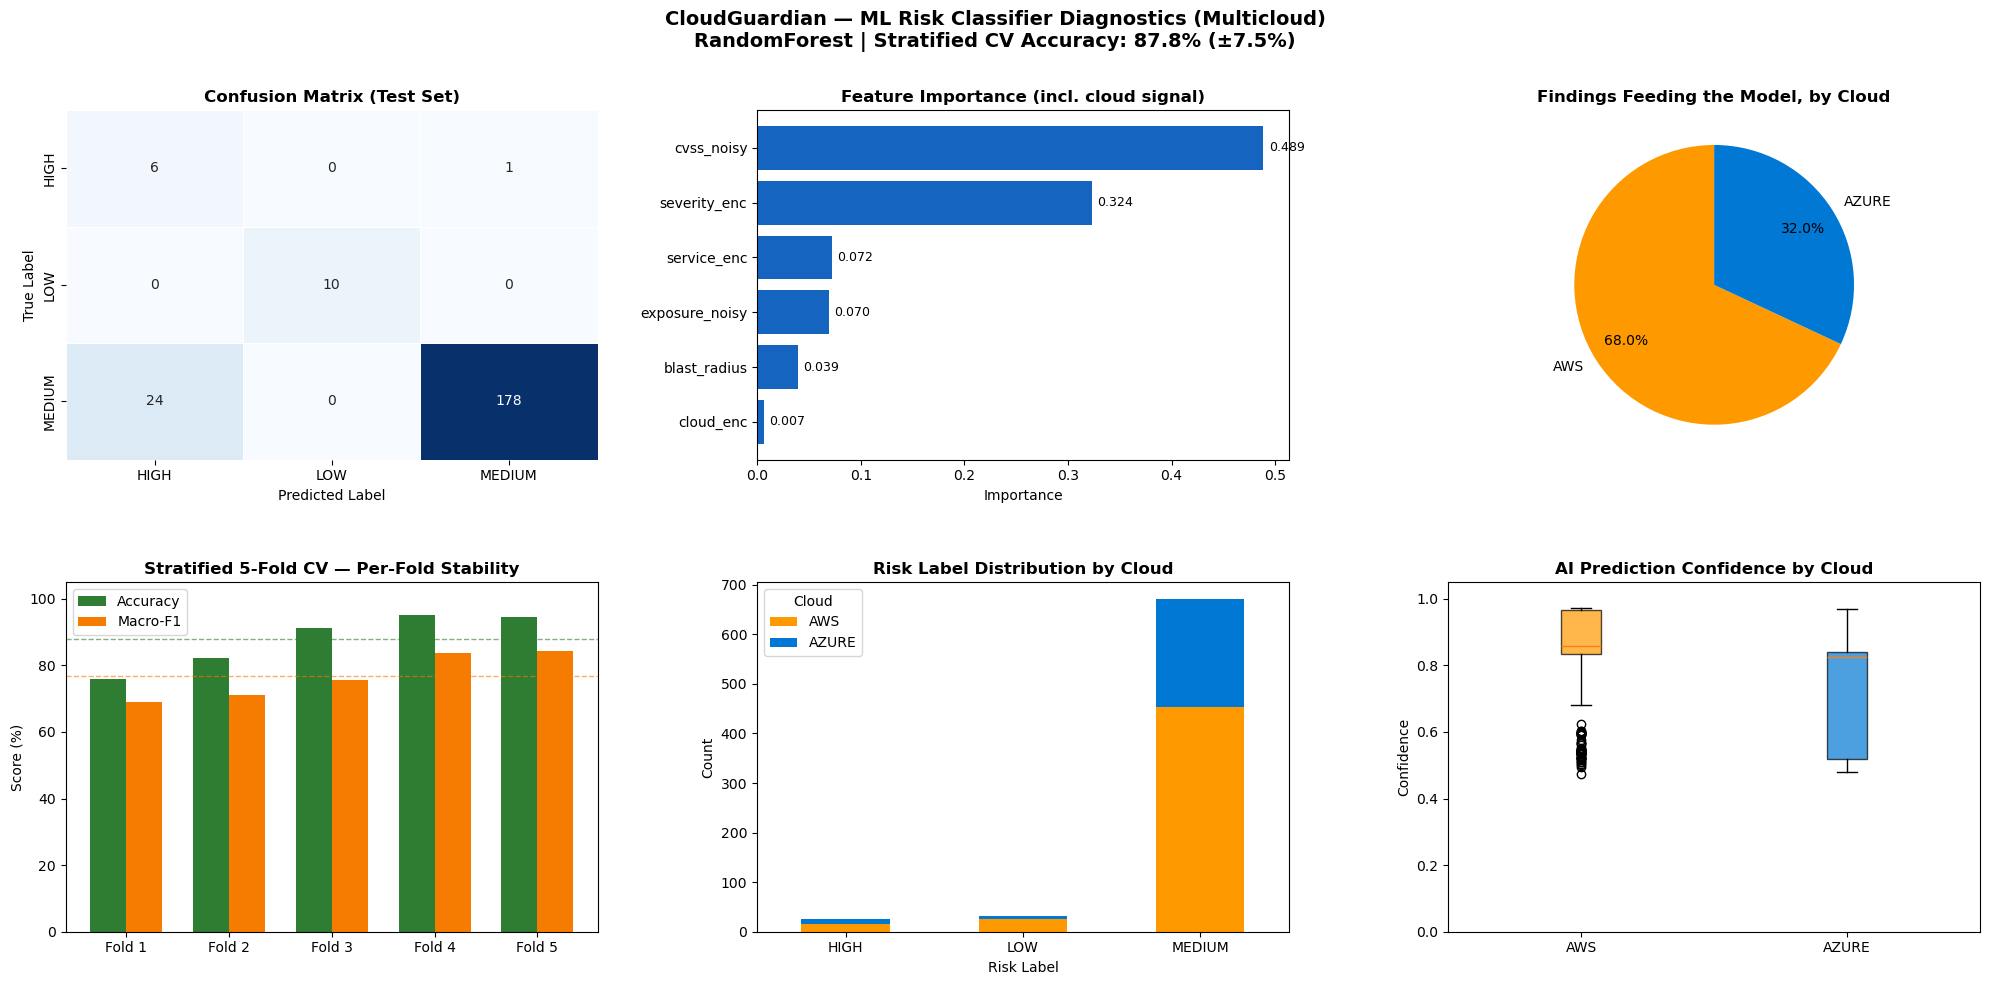

✅ ML model dashboard saved: /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/ml_model_dashboard_multicloud.png
✅ Panels shown: 6 (multicloud)


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6.2 — ML MODEL VISUALIZATION DASHBOARD (MULTICLOUD)
# ═══════════════════════════════════════════════════════════════════
# Depends on variables in memory from the Cell 6 (multicloud) run:
# rf_model, X, y, X_test, y_test, y_pred, le_target, cv_scores,
# cv_f1_macro, importance_df, consolidated (with cloud_provider,
# risk_label, ai_confidence already populated). Run right after Cell 6.
#
# ADAPTIVE: shows 4 panels while only AWS data exists, expands to 6
# panels automatically once consolidated['cloud_provider'] has 2+
# distinct values (i.e. once Azure findings are real, not placeholders).
# ═══════════════════════════════════════════════════════════════════

from sklearn.metrics import confusion_matrix

cloud_color_map = {'AWS': '#ff9900', 'Azure': '#0078d4'}
n_clouds = consolidated['cloud_provider'].nunique()
is_multicloud = n_clouds > 1

print(f"ℹ️  Cloud provider(s) in ML data: {list(consolidated['cloud_provider'].unique())}")
print(f"ℹ️  Dashboard mode: {'MULTICLOUD (6 panels)' if is_multicloud else 'SINGLE-CLOUD (4 panels)'}")

if is_multicloud:
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'CloudGuardian — ML Risk Classifier Diagnostics (Multicloud)\n'
    f'RandomForest | Stratified CV Accuracy: {cv_scores.mean()*100:.1f}% '
    f'(±{cv_scores.std()*100:.1f}%)',
    fontsize=14, fontweight='bold', y=0.98
)

# ── PANEL 1: Confusion Matrix (test set) ──
cm = confusion_matrix(y_test, y_pred)
class_labels = le_target.classes_   # HIGH, LOW, MEDIUM

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels,
    ax=axes[0, 0], cbar=False, linewidths=0.5, linecolor='white'
)
axes[0, 0].set_title('Confusion Matrix (Test Set)', fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# ── PANEL 2: Feature Importance (now includes cloud_enc) ──
axes[0, 1].barh(
    importance_df['Feature'][::-1], importance_df['Importance'][::-1],
    color='#1565c0'
)
axes[0, 1].set_title('Feature Importance (incl. cloud signal)', fontweight='bold')
axes[0, 1].set_xlabel('Importance')
for i, v in enumerate(importance_df['Importance'][::-1]):
    axes[0, 1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# ── PANEL 3: Stratified CV Scores Per Fold ──
fold_labels = [f'Fold {i+1}' for i in range(len(cv_scores))]
x_pos = np.arange(len(fold_labels))
width = 0.35

axes[1, 0].bar(x_pos - width/2, cv_scores * 100, width, label='Accuracy', color='#2e7d32')
axes[1, 0].bar(x_pos + width/2, cv_f1_macro * 100, width, label='Macro-F1', color='#f57c00')
axes[1, 0].axhline(cv_scores.mean() * 100, color='#2e7d32', linestyle='--', linewidth=1, alpha=0.6)
axes[1, 0].axhline(cv_f1_macro.mean() * 100, color='#f57c00', linestyle='--', linewidth=1, alpha=0.6)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(fold_labels)
axes[1, 0].set_ylabel('Score (%)')
axes[1, 0].set_title('Stratified 5-Fold CV — Per-Fold Stability', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 105)

# ── PANEL 4: Risk Label Distribution — stacked by cloud if multicloud ──
if is_multicloud:
    risk_cloud_ct = pd.crosstab(consolidated['risk_label'], consolidated['cloud_provider'])
    risk_cloud_ct = risk_cloud_ct.reindex(class_labels, fill_value=0)
    risk_cloud_ct.plot(
        kind='bar', stacked=True, ax=axes[1, 1],
        color=[cloud_color_map.get(c, '#9e9e9e') for c in risk_cloud_ct.columns]
    )
    axes[1, 1].set_title('Risk Label Distribution by Cloud', fontweight='bold')
    axes[1, 1].set_xlabel('Risk Label')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].legend(title='Cloud', labels=[c.upper() for c in risk_cloud_ct.columns])
    axes[1, 1].tick_params(axis='x', rotation=0)
else:
    label_counts = consolidated['risk_label'].value_counts().reindex(class_labels, fill_value=0)
    label_colors = {'HIGH': '#d32f2f', 'MEDIUM': '#fbc02d', 'LOW': '#388e3c'}
    bar_colors = [label_colors.get(l, '#9e9e9e') for l in label_counts.index]
    axes[1, 1].bar(label_counts.index, label_counts.values, color=bar_colors)
    axes[1, 1].set_title('Risk Label Distribution (Class Imbalance)', fontweight='bold')
    axes[1, 1].set_ylabel('Count')
    for i, v in enumerate(label_counts.values):
        pct = v / label_counts.sum() * 100
        axes[1, 1].text(i, v + 1, f'{v} ({pct:.1f}%)', ha='center', fontweight='bold')

# ── PANELS 5 & 6: ONLY when 2+ cloud providers are actually present ──
if is_multicloud:
    # PANEL 5: Findings feeding the model, by cloud (pie)
    cloud_counts = consolidated['cloud_provider'].value_counts()
    chart5_colors = [cloud_color_map.get(c, '#9e9e9e') for c in cloud_counts.index]
    axes[0, 2].pie(
        cloud_counts.values, labels=[c.upper() for c in cloud_counts.index],
        colors=chart5_colors, autopct='%1.1f%%', startangle=90,
        pctdistance=0.75, labeldistance=1.1
    )
    axes[0, 2].set_title('Findings Feeding the Model, by Cloud', fontweight='bold')

# PANEL 6: AI prediction confidence by cloud (box plot)
    cloud_order = sorted(consolidated['cloud_provider'].unique())
    conf_data = [
        consolidated.loc[consolidated['cloud_provider'] == c, 'ai_confidence'].dropna()
        for c in cloud_order
    ]

    bp = axes[1, 2].boxplot(conf_data, patch_artist=True)
    axes[1, 2].set_xticklabels([c.upper() for c in cloud_order])

    for patch, c in zip(bp['boxes'], cloud_order):
        patch.set_facecolor(cloud_color_map.get(c, '#9e9e9e'))
        patch.set_alpha(0.7)

    axes[1, 2].set_title('AI Prediction Confidence by Cloud', fontweight='bold')
    axes[1, 2].set_ylabel('Confidence')
    axes[1, 2].set_ylim(0, 1.05)

plt.tight_layout()
if is_multicloud:
    plt.subplots_adjust(top=0.88, hspace=0.35, wspace=0.3)
else:
    plt.subplots_adjust(top=0.90, hspace=0.3, wspace=0.3)

ML_CHART_OUT = os.path.join(OUTPUT_DIR, "ml_model_dashboard_multicloud.png")
plt.savefig(ML_CHART_OUT, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ ML model dashboard saved: {ML_CHART_OUT}")
print(f"✅ Panels shown: {'6 (multicloud)' if is_multicloud else '4 (single-cloud)'}") 

ℹ️  Cloud provider(s) in ML data: ['AWS', 'Azure']
ℹ️  Dashboard mode: MULTICLOUD (6 panels)


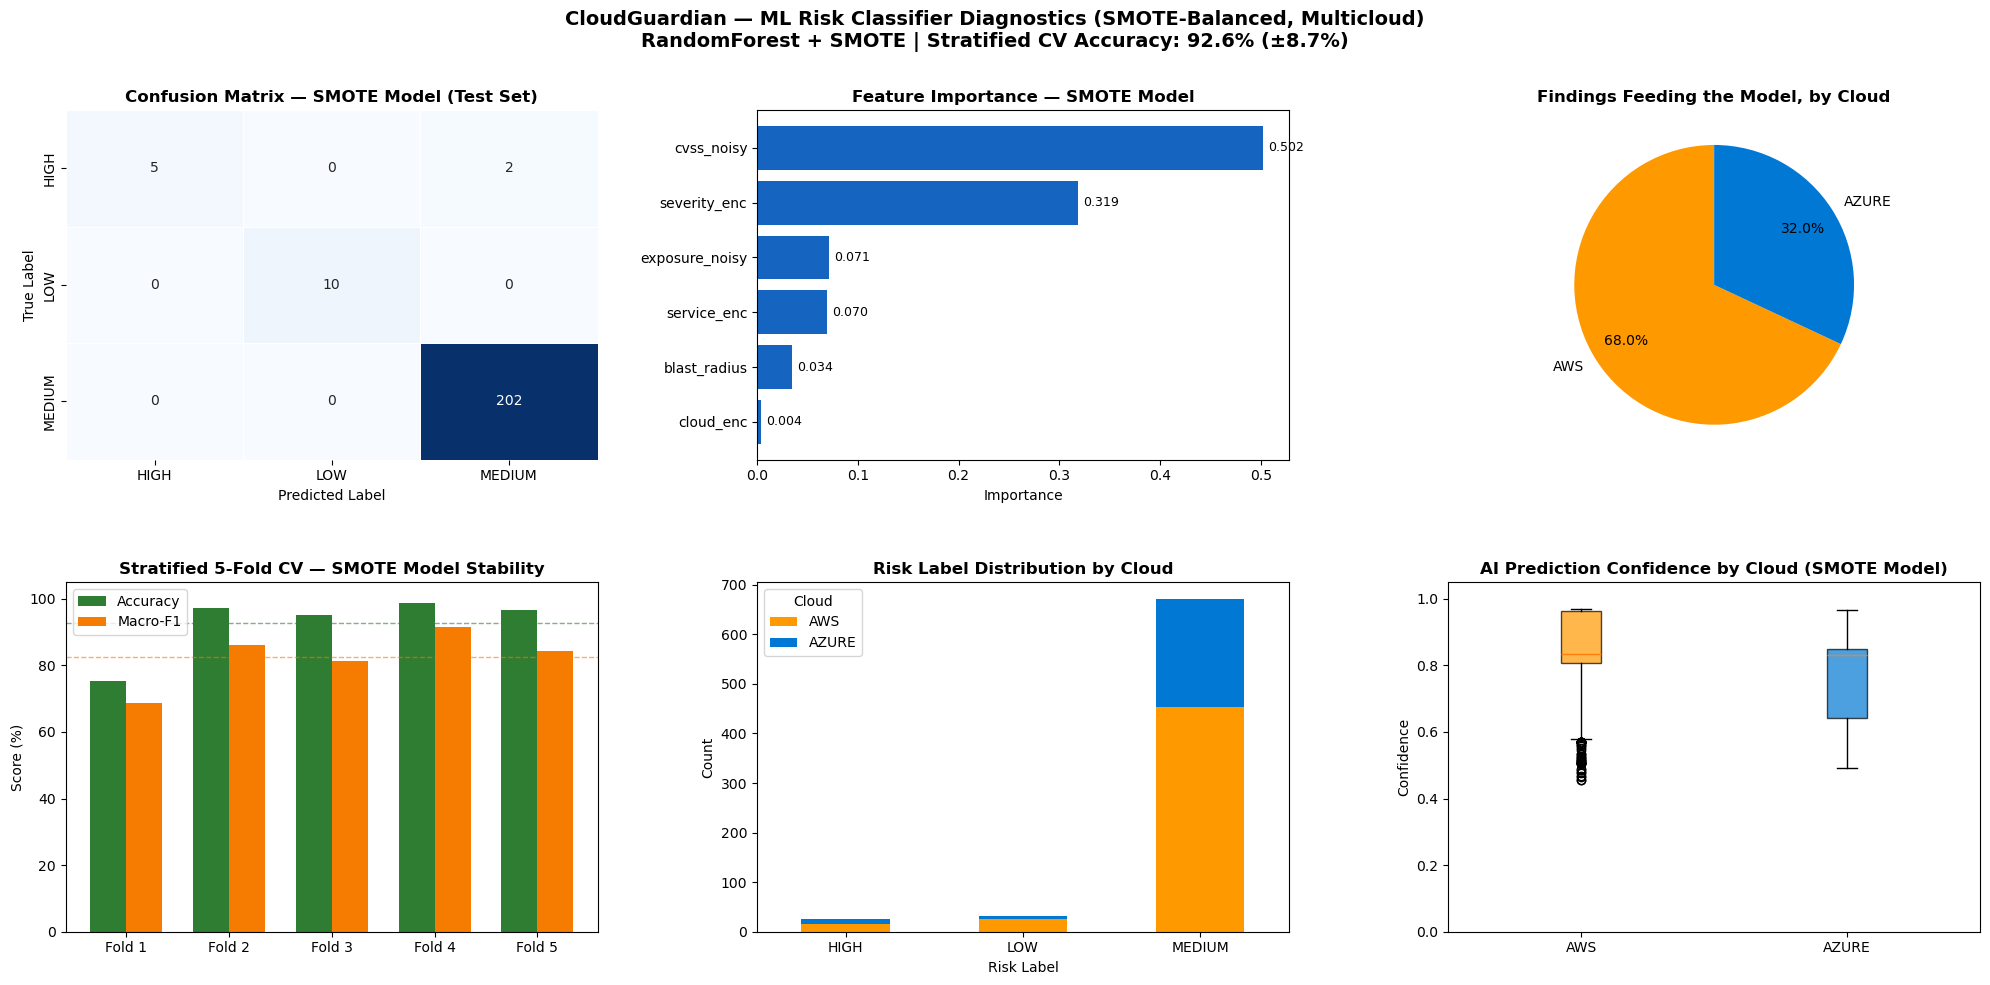

✅ SMOTE ML model dashboard saved: /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/ml_model_dashboard_smote_multicloud.png
✅ Panels shown: 6 (multicloud)


In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6.3 — ML MODEL VISUALIZATION DASHBOARD (SMOTE-BALANCED, MULTICLOUD)
# ═══════════════════════════════════════════════════════════════════
# Depends on variables in memory from Cell 6.1 (SMOTE):
# smote_pipeline, X, y, X_test, y_test, le_target, smote_cv_acc,
# smote_cv_f1, consolidated (with cloud_provider, risk_label,
# ai_confidence_smote already populated). Run right after Cell 6.1.
# ═══════════════════════════════════════════════════════════════════

from sklearn.metrics import confusion_matrix

cloud_color_map = {'AWS': '#ff9900', 'Azure': '#0078d4'}
n_clouds = consolidated['cloud_provider'].nunique()
is_multicloud = n_clouds > 1

print(f"ℹ️  Cloud provider(s) in ML data: {list(consolidated['cloud_provider'].unique())}")
print(f"ℹ️  Dashboard mode: {'MULTICLOUD (6 panels)' if is_multicloud else 'SINGLE-CLOUD (4 panels)'}")

# ── Recompute what Cell 6.1 didn't keep around: test-set predictions
#    and feature importances FOR THE SMOTE MODEL specifically ──────
y_pred_smote = smote_pipeline.predict(X_test)

importance_df_smote = pd.DataFrame({
    'Feature': X.columns,
    'Importance': smote_pipeline.named_steps['clf'].feature_importances_
}).sort_values('Importance', ascending=False)

if is_multicloud:
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'CloudGuardian — ML Risk Classifier Diagnostics (SMOTE-Balanced, Multicloud)\n'
    f'RandomForest + SMOTE | Stratified CV Accuracy: {smote_cv_acc.mean()*100:.1f}% '
    f'(±{smote_cv_acc.std()*100:.1f}%)',
    fontsize=14, fontweight='bold', y=0.98
)

# ── PANEL 1: Confusion Matrix (test set, SMOTE model) ──
cm = confusion_matrix(y_test, y_pred_smote)
class_labels = le_target.classes_   # HIGH, LOW, MEDIUM

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels,
    ax=axes[0, 0], cbar=False, linewidths=0.5, linecolor='white'
)
axes[0, 0].set_title('Confusion Matrix — SMOTE Model (Test Set)', fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# ── PANEL 2: Feature Importance (SMOTE model) ──
axes[0, 1].barh(
    importance_df_smote['Feature'][::-1], importance_df_smote['Importance'][::-1],
    color='#1565c0'
)
axes[0, 1].set_title('Feature Importance — SMOTE Model', fontweight='bold')
axes[0, 1].set_xlabel('Importance')
for i, v in enumerate(importance_df_smote['Importance'][::-1]):
    axes[0, 1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# ── PANEL 3: Stratified CV Scores Per Fold (SMOTE model) ──
fold_labels = [f'Fold {i+1}' for i in range(len(smote_cv_acc))]
x_pos = np.arange(len(fold_labels))
width = 0.35

axes[1, 0].bar(x_pos - width/2, smote_cv_acc * 100, width, label='Accuracy', color='#2e7d32')
axes[1, 0].bar(x_pos + width/2, smote_cv_f1 * 100, width, label='Macro-F1', color='#f57c00')
axes[1, 0].axhline(smote_cv_acc.mean() * 100, color='#2e7d32', linestyle='--', linewidth=1, alpha=0.6)
axes[1, 0].axhline(smote_cv_f1.mean() * 100, color='#f57c00', linestyle='--', linewidth=1, alpha=0.6)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(fold_labels)
axes[1, 0].set_ylabel('Score (%)')
axes[1, 0].set_title('Stratified 5-Fold CV — SMOTE Model Stability', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 105)

# ── PANEL 4: Risk Label Distribution — stacked by cloud if multicloud ──
if is_multicloud:
    risk_cloud_ct = pd.crosstab(consolidated['risk_label'], consolidated['cloud_provider'])
    risk_cloud_ct = risk_cloud_ct.reindex(class_labels, fill_value=0)
    risk_cloud_ct.plot(
        kind='bar', stacked=True, ax=axes[1, 1],
        color=[cloud_color_map.get(c, '#9e9e9e') for c in risk_cloud_ct.columns]
    )
    axes[1, 1].set_title('Risk Label Distribution by Cloud', fontweight='bold')
    axes[1, 1].set_xlabel('Risk Label')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].legend(title='Cloud', labels=[c.upper() for c in risk_cloud_ct.columns])
    axes[1, 1].tick_params(axis='x', rotation=0)
else:
    label_counts = consolidated['risk_label'].value_counts().reindex(class_labels, fill_value=0)
    label_colors = {'HIGH': '#d32f2f', 'MEDIUM': '#fbc02d', 'LOW': '#388e3c'}
    bar_colors = [label_colors.get(l, '#9e9e9e') for l in label_counts.index]
    axes[1, 1].bar(label_counts.index, label_counts.values, color=bar_colors)
    axes[1, 1].set_title('Risk Label Distribution (Class Imbalance)', fontweight='bold')
    axes[1, 1].set_ylabel('Count')
    for i, v in enumerate(label_counts.values):
        pct = v / label_counts.sum() * 100
        axes[1, 1].text(i, v + 1, f'{v} ({pct:.1f}%)', ha='center', fontweight='bold')

# ── PANELS 5 & 6: ONLY when 2+ cloud providers are actually present ──
if is_multicloud:
    # PANEL 5: Findings feeding the model, by cloud (pie)
    cloud_counts = consolidated['cloud_provider'].value_counts()
    chart5_colors = [cloud_color_map.get(c, '#9e9e9e') for c in cloud_counts.index]
    axes[0, 2].pie(
        cloud_counts.values, labels=[c.upper() for c in cloud_counts.index],
        colors=chart5_colors, autopct='%1.1f%%', startangle=90,
        pctdistance=0.75, labeldistance=1.1
    )
    axes[0, 2].set_title('Findings Feeding the Model, by Cloud', fontweight='bold')

# PANEL 6: SMOTE model prediction confidence by cloud (box plot)
    cloud_order = sorted(consolidated['cloud_provider'].unique())
    conf_data = [
        consolidated.loc[consolidated['cloud_provider'] == c, 'ai_confidence_smote'].dropna()
        for c in cloud_order
    ]

    bp = axes[1, 2].boxplot(conf_data, patch_artist=True)
    axes[1, 2].set_xticklabels([c.upper() for c in cloud_order])

    for patch, c in zip(bp['boxes'], cloud_order):
        patch.set_facecolor(cloud_color_map.get(c, '#9e9e9e'))
        patch.set_alpha(0.7)

    axes[1, 2].set_title('AI Prediction Confidence by Cloud (SMOTE Model)', fontweight='bold')
    axes[1, 2].set_ylabel('Confidence')
    axes[1, 2].set_ylim(0, 1.05)

plt.tight_layout()
if is_multicloud:
    plt.subplots_adjust(top=0.88, hspace=0.35, wspace=0.3)
else:
    plt.subplots_adjust(top=0.90, hspace=0.3, wspace=0.3)

ML_CHART_OUT_SMOTE = os.path.join(OUTPUT_DIR, "ml_model_dashboard_smote_multicloud.png")
plt.savefig(ML_CHART_OUT_SMOTE, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ SMOTE ML model dashboard saved: {ML_CHART_OUT_SMOTE}")
print(f"✅ Panels shown: {'6 (multicloud)' if is_multicloud else '4 (single-cloud)'}") 

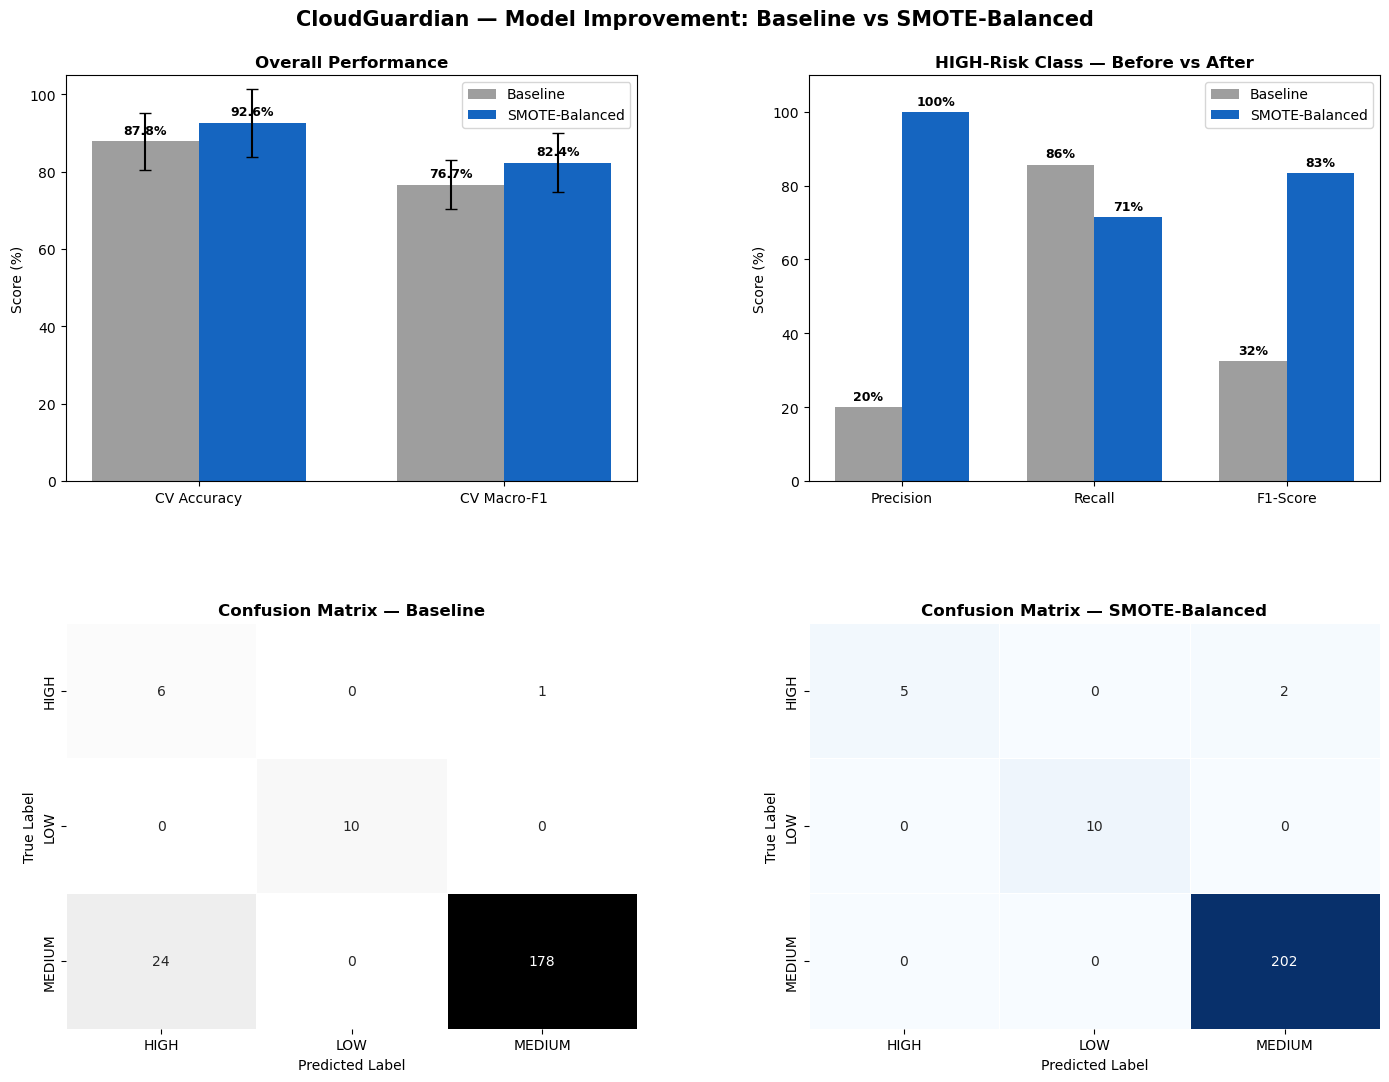

✅ Before/After comparison saved: /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/before_after_smote_comparison.png


In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6.4 — BEFORE vs AFTER: BASELINE vs SMOTE COMPARISON (FOR PPT)
# ═══════════════════════════════════════════════════════════════════
# Depends on variables already in memory from Cell 6.1:
# baseline_model, smote_pipeline, X_test, y_test, le_target,
# baseline_cv_acc, baseline_cv_f1, smote_cv_acc, smote_cv_f1,
# baseline_report, smote_report
# ═══════════════════════════════════════════════════════════════════

from sklearn.metrics import confusion_matrix

class_labels = le_target.classes_

y_pred_baseline = baseline_model.predict(X_test)
y_pred_smote    = smote_pipeline.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(
    'CloudGuardian — Model Improvement: Baseline vs SMOTE-Balanced',
    fontsize=15, fontweight='bold', y=0.98
)

# ── PANEL 1: Overall CV Accuracy & Macro-F1 — Before vs After ──
metrics      = ['CV Accuracy', 'CV Macro-F1']
before_vals  = [baseline_cv_acc.mean()*100, baseline_cv_f1.mean()*100]
after_vals   = [smote_cv_acc.mean()*100,   smote_cv_f1.mean()*100]
before_err   = [baseline_cv_acc.std()*100, baseline_cv_f1.std()*100]
after_err    = [smote_cv_acc.std()*100,    smote_cv_f1.std()*100]

x = np.arange(len(metrics))
w = 0.35
b1 = axes[0,0].bar(x - w/2, before_vals, w, yerr=before_err, capsize=4,
                    label='Baseline', color='#9e9e9e')
b2 = axes[0,0].bar(x + w/2, after_vals, w, yerr=after_err, capsize=4,
                    label='SMOTE-Balanced', color='#1565c0')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics)
axes[0,0].set_ylabel('Score (%)')
axes[0,0].set_ylim(0, 105)
axes[0,0].set_title('Overall Performance', fontweight='bold')
axes[0,0].legend()
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        axes[0,0].text(bar.get_x()+bar.get_width()/2, h+2, f'{h:.1f}%',
                        ha='center', fontsize=9, fontweight='bold')

# ── PANEL 2: HIGH-class Precision / Recall / F1 — Before vs After ──
high_metrics = ['Precision', 'Recall', 'F1-Score']
before_high  = [baseline_report['HIGH']['precision']*100,
                baseline_report['HIGH']['recall']*100,
                baseline_report['HIGH']['f1-score']*100]
after_high   = [smote_report['HIGH']['precision']*100,
                smote_report['HIGH']['recall']*100,
                smote_report['HIGH']['f1-score']*100]

x2 = np.arange(len(high_metrics))
b3 = axes[0,1].bar(x2 - w/2, before_high, w, label='Baseline', color='#9e9e9e')
b4 = axes[0,1].bar(x2 + w/2, after_high, w, label='SMOTE-Balanced', color='#1565c0')
axes[0,1].set_xticks(x2)
axes[0,1].set_xticklabels(high_metrics)
axes[0,1].set_ylabel('Score (%)')
axes[0,1].set_ylim(0, 110)
axes[0,1].set_title('HIGH-Risk Class — Before vs After', fontweight='bold')
axes[0,1].legend()
for bars in (b3, b4):
    for bar in bars:
        h = bar.get_height()
        axes[0,1].text(bar.get_x()+bar.get_width()/2, h+2, f'{h:.0f}%',
                        ha='center', fontsize=9, fontweight='bold')

# ── PANEL 3: Confusion Matrix — Baseline ──
cm_base = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Greys',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[1,0], cbar=False, linewidths=0.5, linecolor='white')
axes[1,0].set_title('Confusion Matrix — Baseline', fontweight='bold')
axes[1,0].set_xlabel('Predicted Label')
axes[1,0].set_ylabel('True Label')

# ── PANEL 4: Confusion Matrix — SMOTE ──
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[1,1], cbar=False, linewidths=0.5, linecolor='white')
axes[1,1].set_title('Confusion Matrix — SMOTE-Balanced', fontweight='bold')
axes[1,1].set_xlabel('Predicted Label')
axes[1,1].set_ylabel('True Label')

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.3)

BEFORE_AFTER_OUT = os.path.join(OUTPUT_DIR, "before_after_smote_comparison.png")
plt.savefig(BEFORE_AFTER_OUT, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Before/After comparison saved: {BEFORE_AFTER_OUT}") 


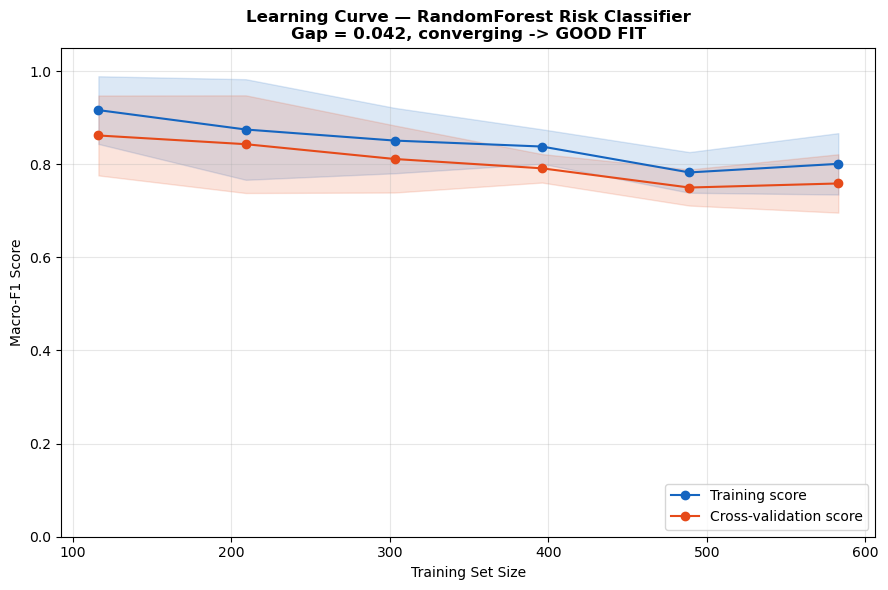

✅ Learning curve saved: /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/learning_curve.png
Final training score       : 0.801
Final CV score              : 0.759
Train-CV gap                : 0.042
✅ Gap = 0.042, both scores converging → GOOD FIT


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6.5 — OVERFITTING / UNDERFITTING DIAGNOSTIC (LEARNING CURVE)
# ═══════════════════════════════════════════════════════════════════
# PURPOSE:
# Plots training-set score vs cross-validation score across increasing
# training-set sizes. This is the standard way to actually SHOW
# overfitting/underfitting rather than just asserting it from CV std.
#
# HOW TO READ IT:
#   - Train score >> CV score, big persistent gap  -> OVERFITTING
#     (model memorizes training data, generalizes poorly)
#   - Both scores low and close together            -> UNDERFITTING
#     (model too constrained to learn the pattern at all)
#   - Both scores converge to a high value          -> GOOD FIT
#     (this is what max_depth=3 + min_samples_leaf=3 are meant to produce)
#
# Depends on: rf_model, X, y (already in memory from Cell 6). Run
# right after Cell 6 (or after 6b, doesn't matter which order).
# ═══════════════════════════════════════════════════════════════════

from sklearn.model_selection import learning_curve, StratifiedKFold

skf_curve = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X, y,
    cv=skf_curve,
    scoring='f1_macro',              # same metric you already report — imbalance-aware
    train_sizes=np.linspace(0.2, 1.0, 6),
    random_state=42,
    shuffle=True
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(train_sizes, train_mean, 'o-', color='#1565c0', label='Training score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='#1565c0')

ax.plot(train_sizes, val_mean, 'o-', color='#e64a19', label='Cross-validation score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='#e64a19')

gap = train_mean[-1] - val_mean[-1]
if gap > 0.15:
    verdict_console = f"⚠️  Gap = {gap:.3f} → sign of OVERFITTING"
    verdict_chart   = f"Gap = {gap:.3f} -> OVERFITTING risk"
elif train_mean[-1] < 0.6:
    verdict_console = f"⚠️  Both scores low ({train_mean[-1]:.3f}) → sign of UNDERFITTING"
    verdict_chart   = f"Scores low ({train_mean[-1]:.3f}) -> UNDERFITTING risk"
else:
    verdict_console = f"✅ Gap = {gap:.3f}, both scores converging → GOOD FIT"
    verdict_chart   = f"Gap = {gap:.3f}, converging -> GOOD FIT"

ax.set_title(f'Learning Curve — RandomForest Risk Classifier\n{verdict_chart}', fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Macro-F1 Score')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
LC_OUT = os.path.join(OUTPUT_DIR, "learning_curve.png")
plt.savefig(LC_OUT, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Learning curve saved: {LC_OUT}")
print(f"Final training score       : {train_mean[-1]:.3f}")
print(f"Final CV score              : {val_mean[-1]:.3f}")
print(f"Train-CV gap                : {gap:.3f}")
print(verdict_console) 

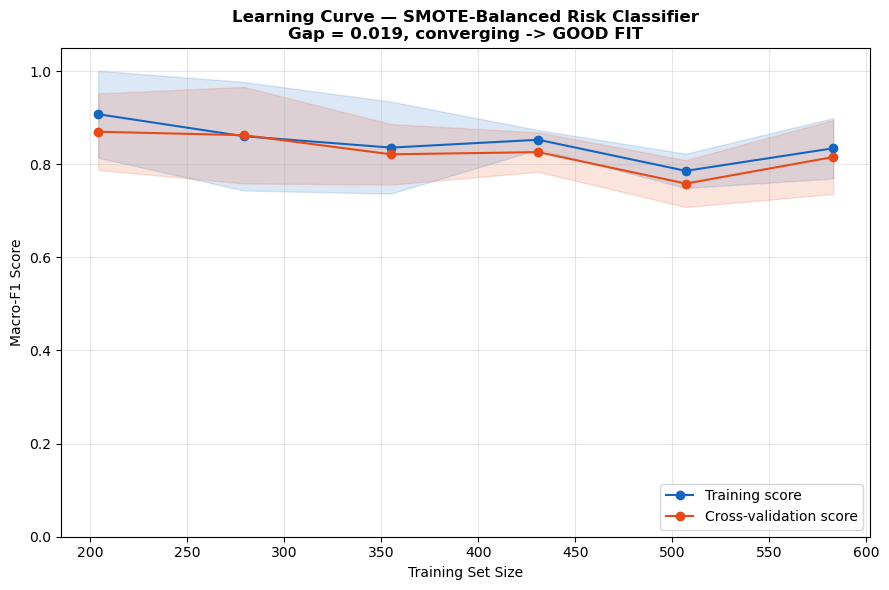

✅ Gap = 0.019, both scores converging → GOOD FIT
✅ Learning curve saved: /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/learning_curve_smote.png
Final training score : 0.834
Final CV score        : 0.815
Train-CV gap          : 0.019


In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6.6 — OVERFITTING / UNDERFITTING DIAGNOSTIC (SMOTE MODEL)
# ═══════════════════════════════════════════════════════════════════
# Same diagnostic as 6.5, run against the SMOTE pipeline instead of
# rf_model. NOTE: learning_curve shrinks the training set down to as
# little as 20% per point — with HIGH being only ~3.4% of the data,
# small subsets can end up with too few HIGH samples for SMOTE's
# k_neighbors. Two safeguards below: (1) k_neighbors dropped to 1 for
# this diagnostic only (needs just 2 minority samples, not 3), and
# (2) train_sizes floor raised from 0.2 to 0.35, and (3) error_score
# set to NaN so a single unlucky fold/size can't crash the whole run.
# Depends on: X, y, le_target (from Cell 6.1). Run after 6.5.
# ═══════════════════════════════════════════════════════════════════
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier

safe_smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=1)),  # safer floor for small subsets
    ('clf', RandomForestClassifier(
        n_estimators=100, max_depth=3, min_samples_leaf=3,
        max_features='sqrt', random_state=42
    )),
])

train_sizes_s, train_scores_s, val_scores_s = learning_curve(
    safe_smote_pipeline, X, y,
    cv=skf_curve,
    scoring='f1_macro',
    train_sizes=np.linspace(0.35, 1.0, 6),   # raised floor from 0.2
    random_state=42,
    shuffle=True,
    error_score=np.nan                       # don't crash the whole run on one bad fold
)

train_mean_s = np.nanmean(train_scores_s, axis=1)
val_mean_s   = np.nanmean(val_scores_s, axis=1)
train_std_s  = np.nanstd(train_scores_s, axis=1)
val_std_s    = np.nanstd(val_scores_s, axis=1)

n_dropped = np.isnan(train_scores_s).sum()
if n_dropped:
    print(f"⚠️  {n_dropped} fold/size combination(s) skipped due to too few HIGH samples "
          f"for SMOTE — expected given HIGH's small size, not a code error.")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes_s, train_mean_s, 'o-', color='#1565c0', label='Training score')
ax.fill_between(train_sizes_s, train_mean_s - train_std_s, train_mean_s + train_std_s,
                 alpha=0.15, color='#1565c0')
ax.plot(train_sizes_s, val_mean_s, 'o-', color='#e64a19', label='Cross-validation score')
ax.fill_between(train_sizes_s, val_mean_s - val_std_s, val_mean_s + val_std_s,
                 alpha=0.15, color='#e64a19')

gap_s = train_mean_s[-1] - val_mean_s[-1]
if gap_s > 0.15:
    verdict_console_s = f"⚠️  Gap = {gap_s:.3f} → sign of OVERFITTING"
    verdict_chart_s   = f"Gap = {gap_s:.3f} -> OVERFITTING risk"
elif train_mean_s[-1] < 0.6:
    verdict_console_s = f"⚠️  Both scores low ({train_mean_s[-1]:.3f}) → sign of UNDERFITTING"
    verdict_chart_s   = f"Scores low ({train_mean_s[-1]:.3f}) -> UNDERFITTING risk"
else:
    verdict_console_s = f"✅ Gap = {gap_s:.3f}, both scores converging → GOOD FIT"
    verdict_chart_s   = f"Gap = {gap_s:.3f}, converging -> GOOD FIT"

ax.set_title(f'Learning Curve — SMOTE-Balanced Risk Classifier\n{verdict_chart_s}', fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Macro-F1 Score')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()

LC_OUT_SMOTE = os.path.join(OUTPUT_DIR, "learning_curve_smote.png")
plt.savefig(LC_OUT_SMOTE, dpi=150, bbox_inches='tight')
plt.show()

print(verdict_console_s)
print(f"✅ Learning curve saved: {LC_OUT_SMOTE}")
print(f"Final training score : {train_mean_s[-1]:.3f}")
print(f"Final CV score        : {val_mean_s[-1]:.3f}")
print(f"Train-CV gap          : {gap_s:.3f}") 

In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — SAVE CONSOLIDATED FINDINGS TO CSV & JSON (MULTICLOUD)
# ═══════════════════════════════════════════════════════════════════
# PURPOSE:
# Export the final prioritized findings database to disk.
# CSV  → for Excel analysis and Week 2 report submission
# JSON → for Week 3 auto-remediation pipeline input
#
# MULTICLOUD UPDATE:
# Added per-cloud (AWS vs Azure) breakdown and AI risk level summary
# — without this, the Week 2 report only shows rule-based P0-P3 bands
# and hides both the AI model output and the cloud split.
#
# MODEL UPDATE (this version):
# The exported `ai_risk_level` / `ai_confidence` columns now come from
# the SMOTE-balanced model (Cell 6.1), not the Cell 6 baseline —
# SMOTE is the model being shipped to the client and feeding Week 3's
# auto-remediation pipeline, so the export must match. The baseline
# model's predictions are preserved under `ai_risk_level_baseline` /
# `ai_confidence_baseline` for reference/audit purposes only — Week 3
# automation should NOT read those columns.
# ═══════════════════════════════════════════════════════════════════

assert 'ai_risk_level_smote' in consolidated.columns, \
    "ai_risk_level_smote not found — run Cell 6.1 (SMOTE) before Cell 7."

# ── Build the export frame: SMOTE becomes the canonical AI columns ──
consolidated_export = consolidated.copy()

# Preserve baseline predictions under an explicit, unambiguous name
# (only if Cell 6's baseline columns are present)
if 'ai_risk_level' in consolidated_export.columns:
    consolidated_export = consolidated_export.rename(columns={
        'ai_risk_level':  'ai_risk_level_baseline',
        'ai_confidence':  'ai_confidence_baseline',
    })

# Promote SMOTE predictions to the canonical column names
consolidated_export = consolidated_export.rename(columns={
    'ai_risk_level_smote':  'ai_risk_level',
    'ai_confidence_smote':  'ai_confidence',
})

# ── Export ──────────────────────────────────────────────────────────
consolidated_export.to_csv(CSV_OUT, index=False)
print(f"✅ CSV saved  : {CSV_OUT}")
consolidated_export.to_json(JSON_OUT, orient='records', indent=2)
print(f"✅ JSON saved : {JSON_OUT}")

print(f"\n{'='*50}")
print(f"WEEK 2 DELIVERABLE — CONSOLIDATED FINDINGS DB")
print(f"{'='*50}")
print(f"Total Findings   : {len(consolidated_export)}")
print(f"P0 - CRITICAL    : {len(consolidated_export[consolidated_export['priority_band']=='P0 - CRITICAL'])}")
print(f"P1 - HIGH        : {len(consolidated_export[consolidated_export['priority_band']=='P1 - HIGH'])}")
print(f"P2 - MEDIUM      : {len(consolidated_export[consolidated_export['priority_band']=='P2 - MEDIUM'])}")
print(f"P3 - LOW         : {len(consolidated_export[consolidated_export['priority_band']=='P3 - LOW'])}")

# ───────────────────────────────────────────────────────────────────
# MULTICLOUD BREAKDOWN — findings split by AWS vs Azure
# ───────────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"BREAKDOWN BY CLOUD PROVIDER")
print(f"{'='*50}")
cloud_counts = consolidated_export['cloud_provider'].value_counts()
for cloud, count in cloud_counts.items():
    print(f"{cloud.upper():<8} : {count} findings")

print(f"\nPriority band x Cloud provider:")
print(pd.crosstab(consolidated_export['cloud_provider'], consolidated_export['priority_band']))

# ───────────────────────────────────────────────────────────────────
# AI RISK LEVEL SUMMARY — SMOTE-Balanced model (Cell 6.1), the model
# actually being shipped
# ───────────────────────────────────────────────────────────────────
if 'ai_risk_level' in consolidated_export.columns:
    print(f"\n{'='*50}")
    print(f"AI MODEL RISK SUMMARY (SMOTE-Balanced Model, Cell 6.1 output)")
    print(f"{'='*50}")
    ai_counts = consolidated_export['ai_risk_level'].value_counts()
    for level, count in ai_counts.items():
        avg_conf = consolidated_export[consolidated_export['ai_risk_level']==level]['ai_confidence'].mean()
        print(f"{level:<8} : {count} findings  (avg confidence {avg_conf*100:.1f}%)")
    print(f"\nAI Risk Level x Cloud provider:")
    print(pd.crosstab(consolidated_export['cloud_provider'], consolidated_export['ai_risk_level']))

# ── Optional reference-only summary of the baseline model, so it's
#    visible in console output but clearly marked as not-the-shipped-model
if 'ai_risk_level_baseline' in consolidated_export.columns:
    print(f"\n{'='*50}")
    print(f"REFERENCE ONLY — Baseline Model (pre-SMOTE, Cell 6 output)")
    print(f"Not used for remediation decisions. Kept for audit/comparison.")
    print(f"{'='*50}")
    base_counts = consolidated_export['ai_risk_level_baseline'].value_counts()
    for level, count in base_counts.items():
        avg_conf = consolidated_export[consolidated_export['ai_risk_level_baseline']==level]['ai_confidence_baseline'].mean()
        print(f"{level:<8} : {count} findings  (avg confidence {avg_conf*100:.1f}%)")

print(f"\n✅ Week 2 Step 1 Complete — Multicloud Consolidated Findings Database Ready!")
print(f"ℹ️  Canonical 'ai_risk_level' / 'ai_confidence' columns = SMOTE-Balanced model.") 

✅ CSV saved  : /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/consolidated_findings.csv
✅ JSON saved : /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/consolidated_findings.json

WEEK 2 DELIVERABLE — CONSOLIDATED FINDINGS DB
Total Findings   : 729
P0 - CRITICAL    : 1
P1 - HIGH        : 28
P2 - MEDIUM      : 62
P3 - LOW         : 638

BREAKDOWN BY CLOUD PROVIDER
AWS      : 496 findings
AZURE    : 233 findings

Priority band x Cloud provider:
priority_band   P0 - CRITICAL  P1 - HIGH  P2 - MEDIUM  P3 - LOW
cloud_provider                                                 
AWS                         1         15           44       436
Azure                       0         13           18       202

AI MODEL RISK SUMMARY (SMOTE-Balanced Model, Cell 6.1 output)
MEDIUM   : 679 findings  (avg confidence 81.6%)
LOW      : 32 findings  (avg confidence 93.2%)
HIGH     : 18 findings  (avg confidence 87.4%)

AI Risk Level x Cloud provider:
ai_risk_level   HIGH  LOW  MEDIUM
cloud_provider       

ℹ️  Cloud provider(s) detected: ['AWS', 'Azure']
ℹ️  Mode: MULTICLOUD (6 charts)


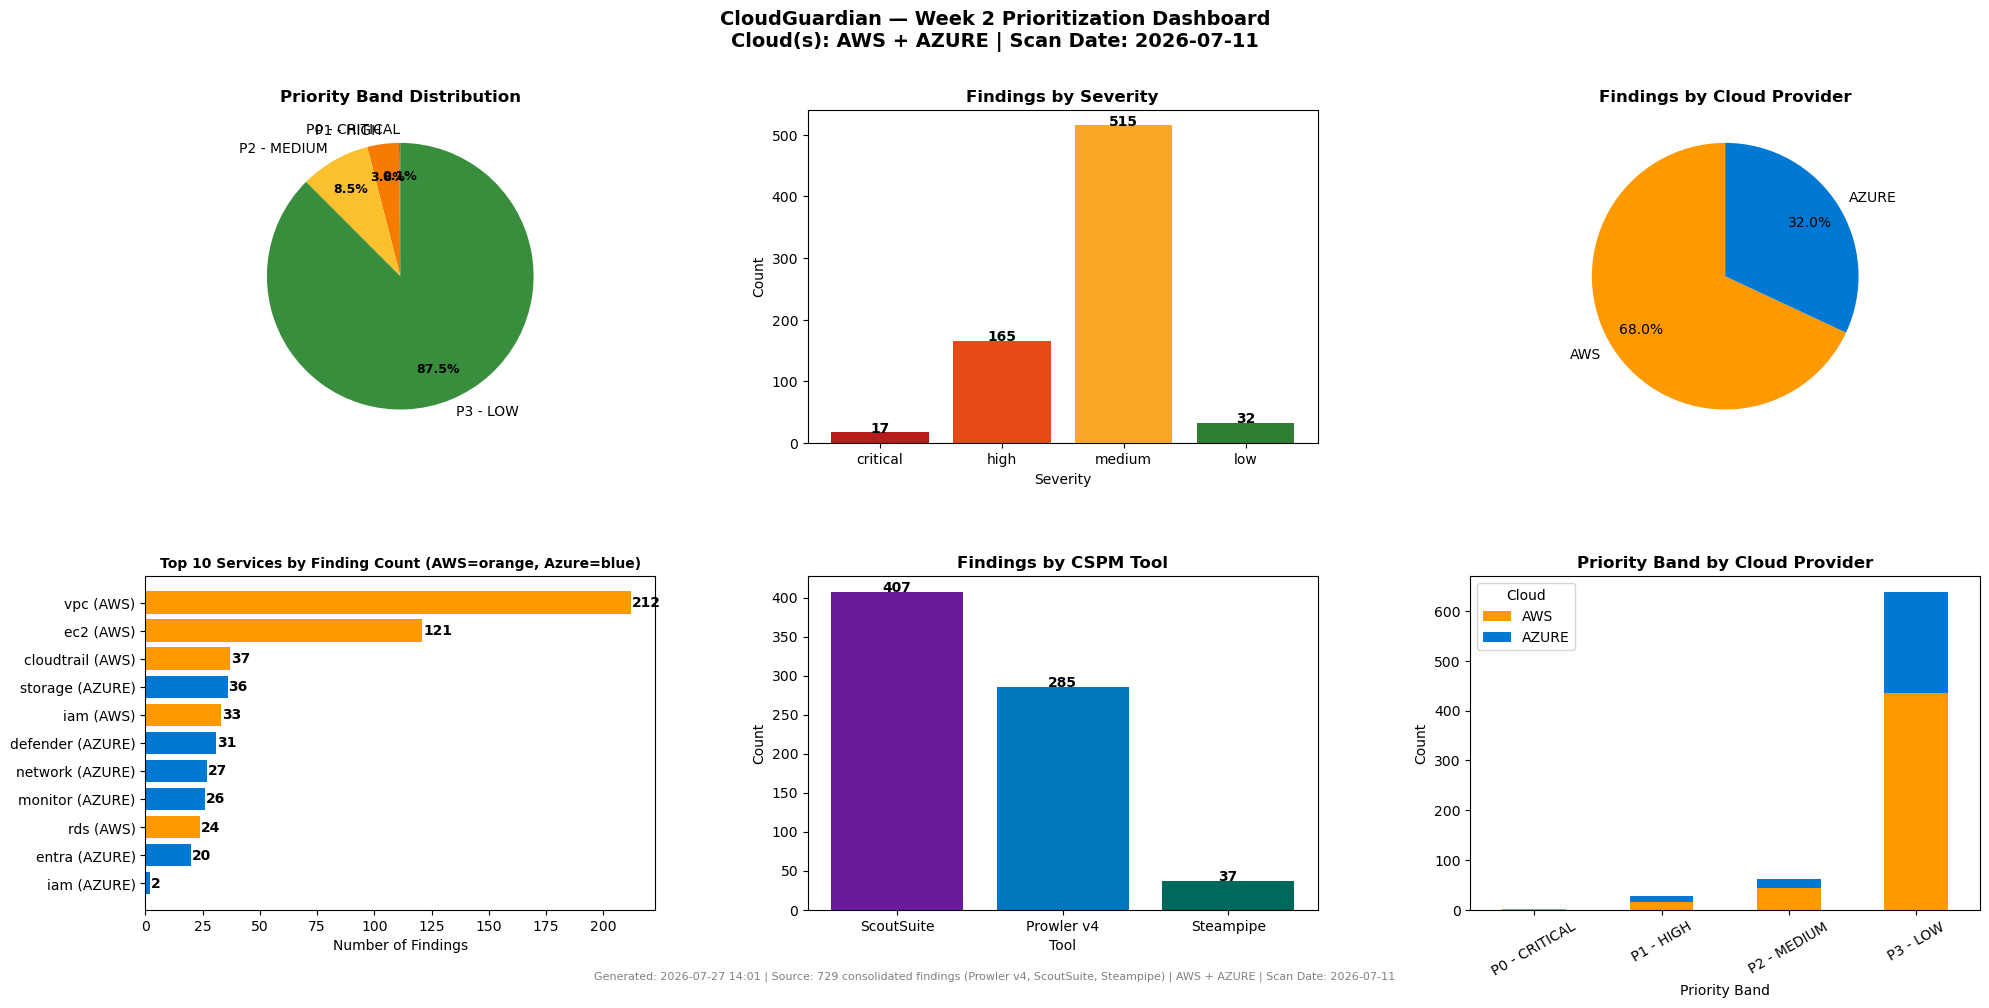

✅ Dashboard saved : /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/week2_dashboard.png
✅ Week 2 Step 2 Complete — Visualization Ready (6 charts)!


In [17]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — VISUALIZATION — PRIORITIZATION CHARTS (ADAPTIVE MULTICLOUD)
# ═══════════════════════════════════════════════════════════════════
# PURPOSE:
# Generate charts for the Week 2 final report. Saved as a single PNG.
#
# ADAPTIVE LOGIC:
# - If only ONE cloud provider is present in `consolidated` -> shows
#   the original 4 charts in a clean 2x2 grid (no redundant single-
#   color pie/stacked-bar charts).
# - If TWO OR MORE cloud providers are present -> expands to 2x3 grid
#   with 2 extra multicloud charts (cloud provider split, priority
#   band x cloud provider).
# - Chart 3 (top services) is color-coded by cloud only when relevant.
# ═══════════════════════════════════════════════════════════════════

cloud_color_map = {'aws': '#ff9900', 'azure': '#0078d4'}  # AWS orange, Azure blue
n_clouds = consolidated['cloud_provider'].nunique()
is_multicloud = n_clouds > 1

print(f"ℹ️  Cloud provider(s) detected: {list(consolidated['cloud_provider'].unique())}")
print(f"ℹ️  Mode: {'MULTICLOUD (6 charts)' if is_multicloud else 'SINGLE-CLOUD (4 charts)'}")

if is_multicloud:
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Title: adapt to actual cloud providers present ──
cloud_providers_str = " + ".join(c.upper() for c in consolidated['cloud_provider'].unique())
fig.suptitle(
    f'CloudGuardian — Week 2 Prioritization Dashboard\n'
    f'Cloud(s): {cloud_providers_str} | Scan Date: {SCAN_DATE}',
    fontsize=14, fontweight='bold',
    y=0.98
)

# ── CHART 1: Priority Band Distribution (Pie) ──
band_order  = ['P0 - CRITICAL', 'P1 - HIGH', 'P2 - MEDIUM', 'P3 - LOW']
band_counts = consolidated['priority_band'].value_counts().reindex(band_order, fill_value=0)
colors_pie  = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c']
wedges, texts, autotexts = axes[0,0].pie(
    band_counts.values, labels=band_counts.index,
    colors=colors_pie, autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, labeldistance=1.1
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
axes[0,0].set_title('Priority Band Distribution', fontweight='bold')

# ── CHART 2: Severity Breakdown (Bar) ──
sev_order  = ['critical', 'high', 'medium', 'low']
sev_colors = ['#b71c1c', '#e64a19', '#f9a825', '#2e7d32']
sev_counts = consolidated['severity'].str.lower().value_counts()
sev_counts = sev_counts.reindex(sev_order, fill_value=0)
axes[0,1].bar(sev_counts.index, sev_counts.values, color=sev_colors)
axes[0,1].set_title('Findings by Severity', fontweight='bold')
axes[0,1].set_xlabel('Severity')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(sev_counts.values):
    axes[0,1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# ── CHART 3: Top 10 Services by Finding Count ──
# Color-coded by cloud only if multicloud; single flat color otherwise.
svc_summary = (consolidated.groupby(['service', 'cloud_provider'])
               .size().reset_index(name='count'))
top_services = consolidated['service'].value_counts().head(10).index
svc_summary  = svc_summary[svc_summary['service'].isin(top_services)]
svc_summary  = svc_summary.sort_values('count', ascending=True)

# Build a composite label (service + cloud) since the same service name
# (e.g. "iam") can appear under both AWS and Azure. Using 'service' alone
# as the bar label would cause both rows to render at the same y-position.
svc_summary['label'] = svc_summary['service'] + ' (' + svc_summary['cloud_provider'].str.upper() + ')'

if is_multicloud:
    bar_colors = svc_summary['cloud_provider'].str.lower().map(cloud_color_map).fillna('#1565c0')
    chart3_title = 'Top 10 Services by Finding Count (AWS=orange, Azure=blue)'
else:
    bar_colors = '#1565c0'
    chart3_title = 'Top 10 Services by Finding Count'

axes[1,0].barh(svc_summary['label'], svc_summary['count'], color=bar_colors)
axes[1,0].set_title(chart3_title, fontweight='bold', fontsize=10)
axes[1,0].set_xlabel('Number of Findings')
for i, v in enumerate(svc_summary['count']):
    axes[1,0].text(v + 0.3, i, str(v), va='center', fontweight='bold')

# ── CHART 4: Tool Contribution (Bar) ──
tool_counts = consolidated['tool'].value_counts()
tool_palette = ['#6a1b9a', '#0277bd', '#00695c', '#c62828', '#f9a825', '#455a64']
bar_colors_tools = [tool_palette[i % len(tool_palette)] for i in range(len(tool_counts))]

axes[1,1].bar(tool_counts.index, tool_counts.values, color=bar_colors_tools)
axes[1,1].set_title('Findings by CSPM Tool', fontweight='bold')
axes[1,1].set_xlabel('Tool')
axes[1,1].set_ylabel('Count')
for i, v in enumerate(tool_counts.values):
    axes[1,1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# ── CHARTS 5 & 6: ONLY when 2+ cloud providers are actually present ──
if is_multicloud:
    # CHART 5: Findings by Cloud Provider (Pie)
    cloud_counts = consolidated['cloud_provider'].value_counts()
    chart5_colors = [cloud_color_map.get(c.lower(), '#9e9e9e') for c in cloud_counts.index]
    axes[0,2].pie(
        cloud_counts.values, labels=[c.upper() for c in cloud_counts.index],
        colors=chart5_colors, autopct='%1.1f%%', startangle=90,
        pctdistance=0.75, labeldistance=1.1
    )
    axes[0,2].set_title('Findings by Cloud Provider', fontweight='bold')

    # CHART 6: Priority Band x Cloud Provider (Stacked Bar)
    crosstab = pd.crosstab(consolidated['priority_band'], consolidated['cloud_provider'])
    crosstab = crosstab.reindex(band_order, fill_value=0)
    crosstab.plot(kind='bar', stacked=True, ax=axes[1,2],
                  color=[cloud_color_map.get(c.lower(), '#9e9e9e') for c in crosstab.columns])
    axes[1,2].set_title('Priority Band by Cloud Provider', fontweight='bold')
    axes[1,2].set_xlabel('Priority Band')
    axes[1,2].set_ylabel('Count')
    axes[1,2].legend(title='Cloud', labels=[c.upper() for c in crosstab.columns])
    axes[1,2].tick_params(axis='x', rotation=30)

# Add generation timestamp + data source as figure footer (audit trail)
cloud_label = " + ".join(c.upper() for c in consolidated['cloud_provider'].unique())
tools_used  = ", ".join(sorted(consolidated['tool'].unique()))

fig.text(0.5, 0.01,
    f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')} | "
    f"Source: {len(consolidated)} consolidated findings ({tools_used}) | "
    f"{cloud_label} | Scan Date: {SCAN_DATE}",
    ha='center', fontsize=8, color='gray')

plt.tight_layout()
if is_multicloud:
    plt.subplots_adjust(bottom=0.08, hspace=0.4, top=0.88, wspace=0.3)
else:
    plt.subplots_adjust(bottom=0.08, hspace=0.35, top=0.90, wspace=0.25)

plt.savefig(CHART_OUT, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Dashboard saved : {CHART_OUT}")
print(f"✅ Week 2 Step 2 Complete — Visualization Ready ({'6' if is_multicloud else '4'} charts)!") 

In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — OWASP LLM06 COMPLIANT REDACTION ENGINE
# Sensitive Information Disclosure Prevention
# ═══════════════════════════════════════════════════════════════════════════
#
# Reference: OWASP Top 10 for LLM Applications — LLM06:2025
#            "Sensitive Information Disclosure"
#            https://genai.owasp.org/llmrisk/llm062025-sensitive-information-disclosure/
#
# OWASP LLM06 requires that any sensitive data — credentials, infrastructure
# identifiers, PII, and internal network details — be sanitized BEFORE being
# transmitted to a third-party LLM provider. This module implements that
# control as a pre-processing layer applied to all text sent to the LLM
# (Groq/Llama 3) for remediation guidance generation.
#
# Design principles applied (per OWASP LLM06 mitigation guidance):
#   1. Defense in depth    — multiple independent pattern categories, so a
#                             gap in one category does not expose data covered
#                             by another.
#   2. Least exposure       — redaction happens at the earliest point in the
#                             pipeline, before any LLM API call is made.
#   3. Referential integrity — identical resources are mapped to identical
#                             pseudonymous tokens, so analysts can still trace
#                             LLM recommendations back to specific findings
#                             without ever exposing the real identifier.
#   4. Auditability         — every redaction action is logged in a mapping
#                             table that can be reviewed but is never sent
#                             externally.
# ═══════════════════════════════════════════════════════════════════════════

import re
from collections import defaultdict 


class OWASPRedactionEngine:
    """
    A pre-processing redaction engine aligned with OWASP LLM06:2025
    (Sensitive Information Disclosure).
    """

    WILDCARD_CIDRS = {"0.0.0.0/0", "::/0"}

    PATTERN_ORDER = [
        "AWS_ACCESS_KEY",
        "AWS_SESSION_TOKEN",
        "AWS_SECRET_KEY",
        "PRIVATE_KEY_BLOCK",
        "JWT_TOKEN",
        "IAM_ARN",
        "GENERIC_ARN",
        "RDS_ENDPOINT",
        "INTERNAL_HOSTNAME",
        "INSTANCE_ID",
        "SECURITY_GROUP_ID",
        "NETWORK_ACL_ID",
        "VOLUME_ID",
        "SUBNET_ID",
        "VPC_ID",
        "AZURE_SUBSCRIPTION_ID",
        "ACCOUNT_ID",
        "IPV6_ADDRESS",
        "IPV4_ADDRESS",
        "PROJECT_RESOURCE_NAME",
        "EMAIL_ADDRESS",
    ]

    PATTERNS = {
        "AWS_ACCESS_KEY":     re.compile(r'\bAKIA[0-9A-Z]{16}\b'),
        "AWS_SESSION_TOKEN":  re.compile(r'\bASIA[0-9A-Z]{16}\b'),
        "AWS_SECRET_KEY":     re.compile(r'(?<![A-Za-z0-9/+=])[A-Za-z0-9/+]{40}(?![A-Za-z0-9/+=])'),
        "PRIVATE_KEY_BLOCK":  re.compile(r'-----BEGIN [A-Z ]*PRIVATE KEY-----[\s\S]+?-----END [A-Z ]*PRIVATE KEY-----'),
        "JWT_TOKEN":          re.compile(r'\bey[A-Za-z0-9_-]+\.[A-Za-z0-9_-]+\.[A-Za-z0-9_-]+\b'),

        "IAM_ARN":            re.compile(r'arn:aws:iam::\d{12}:[\w-]+/[\w-]+'),
        "GENERIC_ARN":        re.compile(r'arn:aws:[\w-]+:[\w-]*:\d{12}:[\w\-/:]+'),
        "RDS_ENDPOINT":       re.compile(r'\b[\w-]+\.[a-z0-9]{10,15}\.[a-z0-9-]+\.rds\.amazonaws\.com\b'),
        "INTERNAL_HOSTNAME":  re.compile(r'\bip-\d{1,3}-\d{1,3}-\d{1,3}-\d{1,3}\.[\w.-]*\.compute\.internal\b'),
        "INSTANCE_ID":        re.compile(r'\bi-[0-9a-f]{8,17}\b'),
        "SECURITY_GROUP_ID":  re.compile(r'\bsg-[0-9a-f]{8,17}\b'),
        "NETWORK_ACL_ID":     re.compile(r'\bacl-[0-9a-f]{8,17}\b'),
        "VOLUME_ID":          re.compile(r'\bvol-[0-9a-f]{8,17}\b'),
        "SUBNET_ID":          re.compile(r'\bsubnet-[0-9a-f]{8,17}\b'),
        "VPC_ID":             re.compile(r'\bvpc-[0-9a-f]{8,17}\b'),
        "ACCOUNT_ID":         re.compile(r'\b\d{12}\b'),

        "AZURE_SUBSCRIPTION_ID": re.compile(
            r'\b[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}\b'
        ),

        "PROJECT_RESOURCE_NAME": re.compile(r'\w*cloudguardian[\w-]*', re.IGNORECASE),

        "IPV6_ADDRESS":       re.compile(r'\b(?:[A-Fa-f0-9]{1,4}:){7}[A-Fa-f0-9]{1,4}(?:/\d{1,3})?\b'),
        "IPV4_ADDRESS":       re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}(?:/\d{1,2})?\b'),

        "EMAIL_ADDRESS":      re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b'),
    }

    def __init__(self):
        self._token_map = {}
        self._counters = defaultdict(int)
        self.audit_log = []

    def _get_token(self, category, raw_value):
        """Return a stable pseudonymous token for a given raw value."""
        if raw_value not in self._token_map:
            self._counters[category] += 1
            token = f"[{category}_{self._counters[category]:03d}]"
            self._token_map[raw_value] = token
            self.audit_log.append({
                "category": category,
                "token": token,
                "raw_value_length": len(raw_value),
            })
        return self._token_map[raw_value]

    def redact(self, text):
        """
        Apply all redaction patterns to the input text in OWASP-recommended
        order and return the sanitized string.

        IPv4/IPv6 addresses are redacted even when CIDR-suffixed (e.g.
        203.0.113.5/32, 10.20.30.0/24), EXCEPT for the universal wildcard
        ranges 0.0.0.0/0 and ::/0 — these are left visible because they
        are a meaningful security signal, not an identifying value.
        """
        if text is None:
            return text

        text = str(text)

        for category in self.PATTERN_ORDER:
            pattern = self.PATTERNS[category]

            if category in ("IPV4_ADDRESS", "IPV6_ADDRESS"):
                def _sub(m, cat=category):
                    if m.group(0) in self.WILDCARD_CIDRS:
                        return m.group(0)
                    return self._get_token(cat, m.group(0))
                text = pattern.sub(_sub, text)
            else:
                text = pattern.sub(
                    lambda m, cat=category: self._get_token(cat, m.group(0)),
                    text
                )

        return text

    def get_mapping_table(self):
        """
        Return the internal raw-value -> token mapping as a list of dicts.

        WARNING: This table contains the original sensitive values and must
        never be transmitted to an external service or included in any
        report shared outside the project team.
        """
        return [
            {"raw_value": raw, "token": token}
            for raw, token in self._token_map.items()
        ]

    def summary(self):
        """Return a count of redactions performed per category."""
        return dict(self._counters)

# ═══════════════════════════════════════════════════════════════════════════
# DEMONSTRATION — apply OWASP redaction engine directly to `consolidated`
# ═══════════════════════════════════════════════════════════════════════════
# NOTE: This block is now self-contained — it does NOT depend on any
# earlier cell (e.g. Cell 9) having already created 'proof_findings' or
# 'status_detail_redacted'. It builds both from scratch here.
# ═══════════════════════════════════════════════════════════════════════════

engine = OWASPRedactionEngine()

# ── Select P0/P1 findings and create the redacted column directly ──
p0_p1_mask = consolidated['priority_band'].isin(['P0 - CRITICAL', 'P1 - HIGH'])
consolidated['status_detail_redacted'] = (
    consolidated['status_detail'].astype(str).apply(engine.redact)
)

proof_findings = consolidated[p0_p1_mask].copy().head(15)

owasp_proof_rows = []
for _, row in proof_findings.iterrows():
    owasp_proof_rows.append({
        'finding_id'      : row['finding_id'],
        'cloud_provider'  : row['cloud_provider'],
        'title'           : row['title'],
        'redacted_detail' : row['status_detail_redacted']
    })

owasp_proof_df = pd.DataFrame(owasp_proof_rows)

print("=" * 100)
print("  OWASP LLM06 REDACTION ENGINE — REDACTION SUMMARY")
print("=" * 100)
for category, count in engine.summary().items():
    print(f"  {category:<22}: {count} unique value(s) redacted")
print("=" * 100)

LLM_OUTPUTS_DIR = os.path.join(OUTPUT_DIR, "llm-outputs")
os.makedirs(LLM_OUTPUTS_DIR, exist_ok=True)
OWASP_PROOF_OUT = os.path.join(LLM_OUTPUTS_DIR, "owasp_redaction_proof.csv")
owasp_proof_df.to_csv(OWASP_PROOF_OUT, index=False)
print(f"\n✅ Saved redaction proof: {OWASP_PROOF_OUT}")

print(f"\n📋 Internal mapping table contains {len(engine.get_mapping_table())} "
      f"entries (kept in-memory, not exported).") 

  OWASP LLM06 REDACTION ENGINE — REDACTION SUMMARY
  VPC_ID                : 18 unique value(s) redacted
  PROJECT_RESOURCE_NAME : 15 unique value(s) redacted
  AWS_SECRET_KEY        : 27 unique value(s) redacted
  IPV4_ADDRESS          : 3 unique value(s) redacted
  INSTANCE_ID           : 1 unique value(s) redacted
  SUBNET_ID             : 57 unique value(s) redacted
  AZURE_SUBSCRIPTION_ID : 3 unique value(s) redacted
  SECURITY_GROUP_ID     : 21 unique value(s) redacted
  RDS_ENDPOINT          : 1 unique value(s) redacted
  IAM_ARN               : 1 unique value(s) redacted
  NETWORK_ACL_ID        : 18 unique value(s) redacted
  VOLUME_ID             : 1 unique value(s) redacted
  ACCOUNT_ID            : 1 unique value(s) redacted

✅ Saved redaction proof: /home/kali/Desktop/Cloudguardian_Capstone/2.Week2/llm-outputs/owasp_redaction_proof.csv

📋 Internal mapping table contains 167 entries (kept in-memory, not exported).


In [19]:
import getpass
import os
os.environ["NVIDIA_API_KEY"] = getpass.getpass("Enter your NVIDIA API key: ") 


Enter your NVIDIA API key:  ········


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11 — RAG-GROUNDED LLM REMEDIATION GUIDANCE (NVIDIA NIM API) — MULTICLOUD
# UPDATED v2: adds (1) retrieval-confidence gate, (2) top_k=3 multi-chunk
#             retrieval, (3) dual grounding check — control-text AND raw
#             scanner data, (4) documented chunking strategy.
# ═══════════════════════════════════════════════════════════════════
# PURPOSE:
#   Use NVIDIA NIM API to generate plain-English 2-line remediation
#   guidance for each P0/P1 finding, GROUNDED in retrieved reference
#   control text (RAG) instead of relying purely on the LLM's own
#   parametric knowledge.
#
# MODEL USED:
#   meta/llama-3.1-8b-instruct via NVIDIA NIM
#
# RAG DESIGN (disclosed per capstone ethics policy):
#   Retriever : Hybrid TF-IDF + NVIDIA NIM embeddings (cosine similarity)
#   Corpus    : Curated control-guidance knowledge base (CONTROL_KB below).
#               Text is written/paraphrased in-house from PUBLIC, OFFICIAL
#               sources (CIS Benchmarks, Microsoft Cloud Security Benchmark,
#               ISO/IEC 27001:2022 Annex A summaries, DPDP Act 2023, and
#               HIPAA Security Rule). Each chunk cites its source for
#               auditability — no live web scraping is done inside the
#               notebook, so the pipeline stays offline-safe and
#               reproducible on the VM.
#   Flow      : finding -> retrieve top-k matching control chunks ->
#               confidence gate -> inject into LLM prompt as grounding
#               context -> LLM paraphrases the retrieved controls, does
#               not invent facts -> dual verification (control-text
#               faithfulness + raw-scanner-data grounding).
#
# DISCLOSURE:
#   Model     : meta/llama-3.1-8b-instruct (NVIDIA NIM)
#   Used For  : 2-line plain-English remediation per finding, grounded
#               in retrieved control-guidance text (RAG)
#   Verified  : Each output cross-checked against BOTH the retrieved
#               control text AND the raw scanner finding detail
#               (see verify_output)
#   Guardrails: No cloud credentials, ARNs, or resource IDs sent to LLM
#               (redacted via OWASPRedactionEngine before this cell runs)
#
# DEPENDS ON: OWASPRedactionEngine must have already run and created
#             consolidated['status_detail_redacted']
# ═══════════════════════════════════════════════════════════════════

import os
import re
import time
import requests
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY")
if not NVIDIA_API_KEY:
    raise ValueError(
        "NVIDIA_API_KEY not found in environment. "
        "Run: export NVIDIA_API_KEY='nvapi-...' in your terminal "
        "before starting Jupyter."
    )

NVIDIA_BASE_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
NVIDIA_MODEL    = "meta/llama-3.1-8b-instruct"

LLM_OUT       = os.path.join(OUTPUT_DIR, "llm_remediation_guidance.csv")
RAG_AUDIT_OUT = os.path.join(OUTPUT_DIR, "rag_retrieval_audit.csv")

# ───────────────────────────────────────────────────────────────────
# PART 1 — RAG KNOWLEDGE BASE (sourced + citable)
# ───────────────────────────────────────────────────────────────────
# CHUNKING STRATEGY (item #4 — documented for report / defense):
#   Granularity : one control = one chunk (atomic, single-topic).
#   Size        : ~35-60 words per chunk — short enough that the
#                 embedding represents ONE concept (not a diluted mix
#                 of several controls), long enough to carry the
#                 "what + why" context an LLM needs to ground a fix.
#   Method      : MANUAL curation, not automated sliding-window/semantic
#                 chunking. Justification: the corpus is small (30
#                 chunks) and drawn from a handful of official standards
#                 documents (CIS, MCSB, ISO 27001 Annex A, DPDP, HIPAA).
#                 Automated chunking (fixed-token windows) risks
#                 splitting a control mid-sentence or merging two
#                 unrelated controls into one chunk. Manual, one-control-
#                 per-chunk curation guarantees each chunk is a coherent,
#                 independently retrievable unit of guidance — important
#                 for both retrieval precision and for a defensible
#                 audit trail (every chunk traces to exactly one named
#                 control from exactly one cited source).
#   Metadata    : each chunk is additionally tagged with cloud/service/
#                 framework, used as a HARD pre-filter before similarity
#                 ranking (see retrieve_control) — this substitutes for
#                 the "context window" that automated chunking pipelines
#                 usually rely on purely on vector similarity to recover.
# ───────────────────────────────────────────────────────────────────
#   control_ref : internal reference tag used for retrieval/audit
#   cloud       : AWS / Azure / Both
#   service     : maps to Prowler/Steampipe/ScoutSuite `service` field
#   framework   : which standard this chunk is paraphrased from
#   source      : human-readable citation
#   source_url  : official URL (cite this in the Week 3 report)
#   text        : in-house paraphrase used as the RAG grounding context
# ───────────────────────────────────────────────────────────────────

CONTROL_KB = [
    # ── AWS — CIS AWS Foundations Benchmark v5.0.0 ──────────────────
    {"control_ref": "AWS-S3-01", "cloud": "AWS", "service": "s3",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "Amazon S3 buckets should have account-level and bucket-level "
             "Block Public Access enabled to prevent public reads and writes. "
             "When disabled, bucket policies or ACLs can expose objects to "
             "anyone on the internet. Enable all four Block Public Access "
             "settings and review bucket policies regularly."},

    {"control_ref": "AWS-S3-02", "cloud": "AWS", "service": "s3",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "S3 buckets storing production or backup data should have "
             "versioning enabled. Versioning preserves prior object versions, "
             "allowing recovery from accidental deletion, overwrite, or "
             "ransomware-style corruption. Suspended versioning removes this "
             "protection going forward."},

    {"control_ref": "AWS-IAM-01", "cloud": "AWS", "service": "iam",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "IAM users with console access should have multi-factor "
             "authentication enforced. A compromised password alone should "
             "not be sufficient to authenticate, especially for privileged "
             "or administrative users."},

    {"control_ref": "AWS-IAM-02", "cloud": "AWS", "service": "iam",
     "framework": "AWS Well-Architected Framework — Security Pillar",
     "source": "AWS Well-Architected", "source_url": "https://docs.aws.amazon.com/wellarchitected/latest/security-pillar/welcome.html",
     "text": "IAM roles and users should follow least privilege. Avoid "
             "attaching broad managed policies such as AdministratorAccess "
             "to service roles; scope permissions to only the specific "
             "actions and resources the workload actually requires."},

    {"control_ref": "AWS-IAM-03", "cloud": "AWS", "service": "iam",
     "framework": "AWS Well-Architected Framework — Security Pillar",
     "source": "AWS Well-Architected", "source_url": "https://docs.aws.amazon.com/wellarchitected/latest/security-pillar/welcome.html",
     "text": "IAM inline and managed policies should be reviewed for "
             "privilege-escalation paths — actions such as iam:PassRole, "
             "iam:CreatePolicyVersion, or iam:AttachUserPolicy granted "
             "together can let a low-privileged principal grant itself "
             "administrative access. Remove or scope these action "
             "combinations to specific resources."},

    {"control_ref": "AWS-RDS-01", "cloud": "AWS", "service": "rds",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "RDS instances should not be marked publicly accessible unless "
             "there is a documented business need. A publicly accessible "
             "database is reachable directly from the internet on its "
             "database port, exposing it to brute-force and exploitation "
             "attempts."},

    {"control_ref": "AWS-RDS-02", "cloud": "AWS", "service": "rds",
     "framework": "AWS Well-Architected Framework — Security Pillar",
     "source": "AWS Well-Architected", "source_url": "https://docs.aws.amazon.com/wellarchitected/latest/security-pillar/welcome.html",
     "text": "RDS storage encryption should be enabled using AWS KMS. "
             "Encryption-at-rest cannot be toggled on an existing "
             "unencrypted instance, so remediation typically requires "
             "creating an encrypted snapshot and restoring a new instance "
             "from it."},

    {"control_ref": "AWS-RDS-03", "cloud": "AWS", "service": "rds",
     "framework": "AWS Well-Architected Framework — Security Pillar",
     "source": "AWS Well-Architected", "source_url": "https://docs.aws.amazon.com/wellarchitected/latest/security-pillar/welcome.html",
     "text": "RDS parameter groups should require SSL/TLS for client "
             "connections (require_secure_transport=1). Without this, "
             "credentials and query data travel in plaintext across the "
             "network."},

    {"control_ref": "AWS-EC2-01", "cloud": "AWS", "service": "ec2",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "EC2 instances should enforce IMDSv2 by setting HttpTokens to "
             "required. IMDSv1 is vulnerable to SSRF-based credential theft, "
             "where an attacker who can trigger an HTTP request from the "
             "instance can retrieve IAM role credentials from the metadata "
             "endpoint."},

    {"control_ref": "AWS-EC2-02", "cloud": "AWS", "service": "ec2",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "EBS volumes attached to EC2 instances should be encrypted, "
             "ideally via account-level default encryption. Unencrypted "
             "volumes expose data at rest if a snapshot is shared or a disk "
             "is later mounted elsewhere."},

    {"control_ref": "AWS-EC2-03", "cloud": "AWS", "service": "ec2",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "Security groups should not permit SSH (port 22) from "
             "0.0.0.0/0. Administrative access should be restricted to a "
             "bastion host, VPN CIDR range, or specific known IP addresses."},

    {"control_ref": "AWS-EC2-04", "cloud": "AWS", "service": "ec2",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "Security groups should not permit database ports such as "
             "MySQL (3306), PostgreSQL (5432), or MSSQL (1433) from "
             "0.0.0.0/0. Database ports should only be reachable from "
             "application-tier security groups or specific trusted CIDR "
             "ranges, never directly from the internet."},

    {"control_ref": "AWS-CLOUDTRAIL-01", "cloud": "AWS", "service": "cloudtrail",
     "framework": "CIS AWS Foundations Benchmark v5.0.0",
     "source": "CIS Benchmarks", "source_url": "https://www.cisecurity.org/benchmark/amazon_web_services",
     "text": "A multi-region CloudTrail trail should be enabled and "
             "continuously logging to a dedicated, access-restricted S3 "
             "bucket. Without CloudTrail there is no audit record of API "
             "activity, making incident investigation impossible."},

    {"control_ref": "AWS-VPC-01", "cloud": "AWS", "service": "vpc",
     "framework": "AWS Well-Architected Framework — Security Pillar",
     "source": "AWS Well-Architected", "source_url": "https://docs.aws.amazon.com/wellarchitected/latest/security-pillar/welcome.html",
     "text": "Network ACLs should not allow all protocols from 0.0.0.0/0. "
             "NACLs are a stateless perimeter control and should be scoped "
             "to only the ports and protocols the application requires, "
             "layered alongside security groups."},

    # ── Azure — Microsoft Cloud Security Benchmark (MCSB) ───────────
    {"control_ref": "AZ-STORAGE-01", "cloud": "Azure", "service": "storage",
     "framework": "Microsoft Cloud Security Benchmark",
     "source": "Microsoft Learn", "source_url": "https://learn.microsoft.com/en-us/security/benchmark/azure/",
     "text": "Azure Storage accounts should have public blob access disabled "
             "at the account level (allowBlobPublicAccess=false). Individual "
             "containers should not be set to public unless explicitly "
             "required, since public containers are readable by anyone with "
             "the URL."},

    {"control_ref": "AZ-STORAGE-02", "cloud": "Azure", "service": "storage",
     "framework": "Microsoft Cloud Security Benchmark",
     "source": "Microsoft Learn", "source_url": "https://learn.microsoft.com/en-us/security/benchmark/azure/",
     "text": "Azure Storage accounts should restrict network access "
             "(publicNetworkAccess=Disabled or a firewall scoped to "
             "selected VNets/IPs) rather than being reachable from any "
             "network, to prevent unauthorized access to blobs, queues, "
             "or tables from the open internet."},

    {"control_ref": "AZ-ENTRA-01", "cloud": "Azure", "service": "entra",
     "framework": "Microsoft Cloud Security Benchmark",
     "source": "Microsoft Learn", "source_url": "https://learn.microsoft.com/en-us/security/benchmark/azure/",
     "text": "Azure AD (Entra ID) users, particularly those with privileged "
             "roles, should have multi-factor authentication enforced via "
             "Conditional Access policies. Password-only authentication is "
             "insufficient for accounts with elevated permissions."},

    {"control_ref": "AZ-SQL-01", "cloud": "Azure", "service": "sqlserver",
     "framework": "Microsoft Cloud Security Benchmark",
     "source": "Microsoft Learn", "source_url": "https://learn.microsoft.com/en-us/security/benchmark/azure/",
     "text": "Azure SQL Database firewall rules should not allow unrestricted "
             "access. Firewall rules should be scoped to specific IP ranges, "
             "and Transparent Data Encryption should remain enabled for data "
             "at rest."},

    {"control_ref": "AZ-MONITOR-01", "cloud": "Azure", "service": "monitor",
     "framework": "Microsoft Cloud Security Benchmark",
     "source": "Microsoft Learn", "source_url": "https://learn.microsoft.com/en-us/security/benchmark/azure/",
     "text": "Diagnostic settings and Azure Monitor logging should be enabled "
             "for critical resources, streaming logs to a Log Analytics "
             "workspace. Without this there is no centralized audit trail "
             "for detecting or investigating suspicious activity."},

    {"control_ref": "AZ-NETWORK-01", "cloud": "Azure", "service": "network",
     "framework": "Microsoft Cloud Security Benchmark",
     "source": "Microsoft Learn", "source_url": "https://learn.microsoft.com/en-us/security/benchmark/azure/",
     "text": "Network Security Groups should not allow inbound traffic from "
             "any source (0.0.0.0/0) on management ports such as RDP (3389) "
             "or SSH (22). Rules should be scoped to specific trusted "
             "ranges."},

    # ── ISO/IEC 27001:2022 — Annex A (Week 3 compliance mapping) ───
    {"control_ref": "ISO-A.8.15", "cloud": "Both", "service": "cloudtrail,monitor",
     "framework": "ISO/IEC 27001:2022 Annex A — Technological Controls",
     "source": "ISO 27001 Annex A", "source_url": "https://iseoblue.com/iso-27001/annex-a/iso-27001-controls-list/",
     "text": "Logs of activities, exceptions, faults, and security events "
             "should be produced, stored, and protected for review and "
             "investigation, supporting timely detection of unauthorized "
             "or anomalous activity."},

    {"control_ref": "ISO-A.8.24", "cloud": "Both", "service": "s3,rds,storage,sqlserver",
     "framework": "ISO/IEC 27001:2022 Annex A — Technological Controls",
     "source": "ISO 27001 Annex A", "source_url": "https://iseoblue.com/iso-27001/annex-a/iso-27001-controls-list/",
     "text": "Rules for the effective use of cryptography, including "
             "encryption of data at rest and in transit, should be defined "
             "and implemented to protect the confidentiality, authenticity, "
             "and integrity of information."},

    {"control_ref": "ISO-A.5.15", "cloud": "Both", "service": "iam,entra",
     "framework": "ISO/IEC 27001:2022 Annex A — Organizational Controls",
     "source": "ISO 27001 Annex A", "source_url": "https://iseoblue.com/iso-27001/annex-a/iso-27001-controls-list/",
     "text": "Access to information and associated assets should be "
             "restricted in accordance with business and security "
             "requirements, following the principle of least privilege and "
             "need-to-know."},

    {"control_ref": "ISO-A.8.12", "cloud": "Both", "service": "s3,storage",
     "framework": "ISO/IEC 27001:2022 Annex A — Technological Controls",
     "source": "ISO 27001 Annex A", "source_url": "https://iseoblue.com/iso-27001/annex-a/iso-27001-controls-list/",
     "text": "Measures to detect and prevent the unauthorised disclosure or "
             "extraction of sensitive information from systems and networks "
             "should be applied, including monitoring of public exposure "
             "points such as storage buckets."},

    {"control_ref": "ISO-A.5.23", "cloud": "Both", "service": "vpc,network",
     "framework": "ISO/IEC 27001:2022 Annex A — Organizational Controls",
     "source": "ISO 27001 Annex A", "source_url": "https://iseoblue.com/iso-27001/annex-a/iso-27001-controls-list/",
     "text": "Processes for acquisition, use, management, and exit from "
             "cloud services should define and monitor information security "
             "requirements for the use of cloud services, including network "
             "exposure boundaries."},

    # ── DPDP Act 2023 (India) — Week 3 compliance mapping ───────────
    {"control_ref": "DPDP-SEC-SAFEGUARD", "cloud": "Both", "service": "s3,rds,storage,sqlserver",
     "framework": "Digital Personal Data Protection Act, 2023 (India)",
     "source": "MeitY (Govt. of India)", "source_url": "https://www.meity.gov.in/static/uploads/2024/06/2bf1f0e9f04e6fb4f8fef35e82c42aa5.pdf",
     "text": "A Data Fiduciary must implement reasonable security safeguards "
             "to prevent personal data breach, including protecting data at "
             "rest and in transit and preventing unauthorized access or "
             "disclosure."},

    {"control_ref": "DPDP-STORAGE-LIMIT", "cloud": "Both", "service": "s3,rds,storage,sqlserver",
     "framework": "Digital Personal Data Protection Act, 2023 (India)",
     "source": "MeitY (Govt. of India)", "source_url": "https://www.meity.gov.in/static/uploads/2024/06/2bf1f0e9f04e6fb4f8fef35e82c42aa5.pdf",
     "text": "Personal data should be retained only for as long as necessary "
             "for the stated purpose of processing, and storage should be "
             "limited accordingly to reduce the impact of any breach."},

    {"control_ref": "DPDP-BREACH-NOTICE", "cloud": "Both", "service": "cloudtrail,monitor",
     "framework": "Digital Personal Data Protection Act, 2023 (India)",
     "source": "MeitY (Govt. of India)", "source_url": "https://www.meity.gov.in/static/uploads/2024/06/2bf1f0e9f04e6fb4f8fef35e82c42aa5.pdf",
     "text": "In the event of a personal data breach, the Data Fiduciary is "
             "expected to detect, log, and report the incident, which "
             "requires reliable audit trails and monitoring to be in place "
             "beforehand."},

    {"control_ref": "DPDP-ACCESS-CONTROL", "cloud": "Both", "service": "iam,entra",
     "framework": "Digital Personal Data Protection Act, 2023 (India)",
     "source": "MeitY (Govt. of India)", "source_url": "https://www.meity.gov.in/static/uploads/2024/06/2bf1f0e9f04e6fb4f8fef35e82c42aa5.pdf",
     "text": "Reasonable security safeguards include restricting access to "
             "personal data to authorized personnel only, which maps to "
             "enforcing least-privilege access and multi-factor "
             "authentication on identity systems."},

    # ── HIPAA Security Rule — required for Team mode compliance mapping ──
    {"control_ref": "HIPAA-SEC-ENCRYPT", "cloud": "Both", "service": "s3,rds,storage,sqlserver",
     "framework": "HIPAA Security Rule",
     "source": "HHS.gov", "source_url": "https://www.hhs.gov/hipaa/for-professionals/security/index.html",
     "text": "Covered entities must implement technical safeguards including encryption of "
             "electronic protected health information (ePHI) at rest and in transit, to "
             "ensure confidentiality and prevent unauthorized disclosure."},

    {"control_ref": "HIPAA-ACCESS-CONTROL", "cloud": "Both", "service": "iam,entra",
     "framework": "HIPAA Security Rule",
     "source": "HHS.gov", "source_url": "https://www.hhs.gov/hipaa/for-professionals/security/index.html",
     "text": "Covered entities must implement access controls that limit ePHI access to only "
             "authorized personnel, following unique user identification and least-privilege "
             "principles, with multi-factor authentication for privileged accounts."},

    {"control_ref": "HIPAA-AUDIT-CONTROLS", "cloud": "Both", "service": "cloudtrail,monitor",
     "framework": "HIPAA Security Rule",
     "source": "HHS.gov", "source_url": "https://www.hhs.gov/hipaa/for-professionals/security/index.html",
     "text": "Covered entities must implement hardware, software, and procedural mechanisms "
             "to record and examine activity in systems containing ePHI, supporting timely "
             "detection of unauthorized access or breaches."},

    {"control_ref": "HIPAA-TRANSMISSION-SECURITY", "cloud": "Both", "service": "vpc,network",
     "framework": "HIPAA Security Rule",
     "source": "HHS.gov", "source_url": "https://www.hhs.gov/hipaa/for-professionals/security/index.html",
     "text": "Covered entities must implement technical security measures to guard against "
             "unauthorized access to ePHI transmitted over an electronic network, including "
             "restricting network exposure to only necessary, authenticated sources."},
]

kb_df = pd.DataFrame(CONTROL_KB)
print(f"✅ RAG knowledge base loaded: {len(kb_df)} control-guidance chunks")
print(f"   Frameworks:")
for i, fw in enumerate(sorted(kb_df['framework'].unique()), start=1):
    print(f"     {i}. {fw}")
print(f"   AWS services   : {', '.join(sorted(kb_df[kb_df['cloud']=='AWS']['service'].unique()))}")
print(f"   Azure services : {', '.join(sorted(kb_df[kb_df['cloud']=='Azure']['service'].unique()))}")
print(f"   Shared (Both)  : {', '.join(sorted(kb_df[kb_df['cloud']=='Both']['service'].unique()))}")

# ═══════════════════════════════════════════════════════════════════
# PART 2 — HYBRID RETRIEVAL INDEX (TF-IDF + NVIDIA NIM Embeddings)
#          + RETRIEVAL-CONFIDENCE GATE (item #1)
#          + TOP-K = 3 MULTI-CHUNK RETRIEVAL (item #2)
# ═══════════════════════════════════════════════════════════════════
# WHY HYBRID:
#   TF-IDF     -> exact technical term matches (e.g. "IMDSv2")
#   Embeddings -> semantic/paraphrase matches (e.g. "SSH open to
#                 internet" ~ "port 22 exposed to 0.0.0.0/0")
#   Final score = 0.4 * TF-IDF_similarity + 0.6 * embedding_similarity
#
# RETRIEVAL_CONFIDENCE_THRESHOLD (item #1):
#   If the TOP retrieved chunk's hybrid similarity is below this value,
#   the KB simply does not have a strong-enough match for this finding.
#   Sending a weak/irrelevant chunk to the LLM as "ground truth" risks
#   generating guidance that sounds grounded but is actually only
#   loosely related — a subtle hallucination-adjacent failure mode.
#   Such findings are gated BEFORE generation: no LLM call is made,
#   and the row is explicitly marked LOW_CONFIDENCE_RETRIEVAL for a
#   human to write guidance manually or for the KB to be expanded.
#   Threshold chosen empirically: KB matches for correctly-covered
#   finding types in this project scored >=0.38 on top_sim in testing;
#   0.30 is set with margin below that as the cutoff.
#
# TOP_K (item #2):
#   Increased from 1 -> 3. A single finding can span more than one
#   control area (e.g. a publicly-exposed + unencrypted RDS instance
#   touches both AWS-RDS-01 and AWS-RDS-02). Retrieving the top 3
#   scoped chunks and passing all of them into the prompt gives the
#   LLM broader — but still retrieval-grounded — context, instead of
#   silently dropping a second relevant control.
# ═══════════════════════════════════════════════════════════════════

import numpy as np
import requests as _requests

NIM_EMBED_URL   = "https://integrate.api.nvidia.com/v1/embeddings"
NIM_EMBED_MODEL = "nvidia/nv-embedqa-e5-v5"

RETRIEVAL_CONFIDENCE_THRESHOLD = 0.30   # item #1
TOP_K = 3                                # item #2
RAW_DATA_GROUNDING_THRESHOLD = 0.35      # item #3 (see verify_output)

def get_nim_embeddings(texts, input_type="passage"):
    """Call NVIDIA NIM embedding endpoint. Returns None on failure
    (instead of raising) so callers can fall back to TF-IDF-only."""
    headers = {
        "Authorization": f"Bearer {NVIDIA_API_KEY}",
        "Content-Type": "application/json"
    }
    payload = {"input": texts, "model": NIM_EMBED_MODEL, "input_type": input_type}
    try:
        resp = _requests.post(NIM_EMBED_URL, headers=headers, json=payload, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        return np.array([item["embedding"] for item in data["data"]])
    except Exception as e:
        print(f"⚠️  Embedding API failed ({e}) — falling back to TF-IDF-only for this call")
        return None

def _cloud_matches(pool_cloud, finding_cloud):
    return str(pool_cloud).strip().upper() in ("BOTH", str(finding_cloud).strip().upper())

def _service_matches(pool_service, finding_service):
    parts = [s.strip().lower() for s in str(pool_service).split(',')]
    return str(finding_service).strip().lower() in parts

# ── Build TF-IDF index ──
vectorizer = TfidfVectorizer(stop_words='english')
kb_tfidf_matrix = vectorizer.fit_transform(kb_df['text'])

# ── Build embedding index ONCE for whole KB (with fallback) ──
print("Building semantic embedding index for knowledge base...")
kb_embeddings = get_nim_embeddings(kb_df['text'].tolist(), input_type="passage")
if kb_embeddings is not None:
    print(f"✅ Embedding index built: {kb_embeddings.shape}")
else:
    print("⚠️  KB embedding index unavailable — pipeline will run TF-IDF-only mode")

def retrieve_control(finding, top_k=TOP_K):
    """Retrieve up to top_k scoped KB chunks, ranked by hybrid similarity.
    Returns (retrieved_df, top_sim, is_low_confidence)."""
    cloud   = str(finding.get('cloud_provider', 'AWS'))
    service = str(finding.get('service', '')).lower()
    title_lower = str(finding.get('title', '')).lower()

    if 'network acl' in title_lower or ' nacl' in title_lower:
        service = 'vpc'

    query = f"{finding['title']} {finding.get('status_detail_redacted','')}"
    query = query[:800]   # truncate to stay well within embedding model's token limit

    # TF-IDF similarity (always available)
    query_tfidf = vectorizer.transform([query])
    tfidf_sims = cosine_similarity(query_tfidf, kb_tfidf_matrix).flatten()

    # Semantic embedding similarity — only if KB index built successfully
    embed_sims = None
    if kb_embeddings is not None:
        query_embedding = get_nim_embeddings([query], input_type="query")
        if query_embedding is not None:
            embed_sims = cosine_similarity(query_embedding, kb_embeddings).flatten()

    # Hybrid score with graceful fallback to TF-IDF-only
    if embed_sims is not None:
        hybrid_sims = 0.4 * tfidf_sims + 0.6 * embed_sims
        retrieval_mode = 'hybrid'
    else:
        hybrid_sims = tfidf_sims
        embed_sims = np.zeros_like(tfidf_sims)
        retrieval_mode = 'tfidf_only'

    pool = kb_df.copy()
    pool['tfidf_sim'] = tfidf_sims
    pool['embed_sim'] = embed_sims
    pool['sim']        = hybrid_sims
    pool['retrieval_mode'] = retrieval_mode

    scope_mask = pool.apply(
        lambda r: _cloud_matches(r['cloud'], cloud) and _service_matches(r['service'], service),
        axis=1
    )
    scoped = pool[scope_mask]
    search_pool = scoped if len(scoped) > 0 else pool
    in_scope = len(scoped) > 0

    retrieved = search_pool.sort_values('sim', ascending=False).head(top_k)
    top_sim = float(retrieved.iloc[0]['sim']) if len(retrieved) else 0.0

    # item #1 — confidence gate. Also treat an out-of-scope fallback
    # match (no cloud/service-scoped chunk existed at all) as low
    # confidence regardless of raw score.
    is_low_confidence = (top_sim < RETRIEVAL_CONFIDENCE_THRESHOLD) or (not in_scope)

    return retrieved, top_sim, is_low_confidence

# ───────────────────────────────────────────────────────────────────
# PART 3 — GROUNDED PROMPT CONSTRUCTION (multi-chunk, item #2)
# ───────────────────────────────────────────────────────────────────

SYSTEM_PROMPT = """You are a cloud security engineer writing remediation
guidance for a health-tech company's security team.
Your audience is a developer — NOT a security expert.
The finding may be from AWS or Azure — read the provider field and
tailor the fix to that specific platform's terminology and tools.

You are given one or more REFERENCE CONTROL GUIDANCE excerpts below.
Base your answer strictly on those references plus the finding detail —
do not introduce facts, product names, or claims that are not supported
by the references. If multiple references are given, synthesize them
into ONE coherent fix rather than addressing them separately.

You MUST respond in EXACTLY this format, with a literal newline
character between the two lines:

<risk explanation, max 40 words, non-technical>
<specific fix action, max 40 words>

Do not merge the two lines into one paragraph. Do not use bullet
points, numbering, or headings."""

def build_prompt(finding, retrieved):
    """Build a safe, RAG-grounded, cloud-aware prompt for one finding.
    Now includes ALL retrieved chunks (up to TOP_K), not just the top-1."""
    cloud = finding.get('cloud_provider', 'AWS')
    ref_lines = "\n".join(
        f"- ({r.control_ref} | {r.framework}) {r.text}" for r in retrieved.itertuples()
    )
    return f"""Cloud Security Finding:
- Cloud Provider : {cloud.upper()}
- Title          : {finding['title']}
- Service        : {finding['service'].upper()}
- Severity       : {finding['severity'].upper()}
- Detail         : {finding['status_detail_redacted']}

Reference Control Guidance (ground your answer in this):
{ref_lines}

Provide exactly 2 lines of guidance as instructed."""

def get_nvidia_guidance(finding, retrieved, max_retries=3):
    """Call NVIDIA NIM API and return 2-line guidance, grounded via RAG.
    Retries on transient network/API failures before giving up."""
    headers = {
        "Authorization": f"Bearer {NVIDIA_API_KEY}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": NVIDIA_MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_prompt(finding, retrieved)}
        ],
        "temperature": 0.3,
        "max_tokens": 150,
        "top_p": 0.9
    }
    last_error = None
    for attempt in range(max_retries):
        try:
            response = requests.post(NVIDIA_BASE_URL, headers=headers, json=payload, timeout=30)
            response.raise_for_status()
            result = response.json()
            text = result['choices'][0]['message']['content'].strip()
            lines = [line.strip() for line in text.split('\n') if line.strip()]
            return '\n'.join(lines[:2])
        except Exception as e:
            last_error = e
            if attempt < max_retries - 1:
                wait = 2 ** attempt
                print(f"  ⚠️  Retry {attempt+1}/{max_retries} after {wait}s ({e})")
                time.sleep(wait)
    raise last_error

# ───────────────────────────────────────────────────────────────────
# PART 4 — DUAL VERIFICATION (item #3)
#   Stage A: control-text faithfulness (existing embedding check) —
#            did the LLM stay grounded in the retrieved reference?
#   Stage B: raw-scanner-data grounding (NEW) — does the guidance
#            actually reflect the specific finding that was scanned,
#            not just the general control topic?
#   Both must pass for a row to be marked fully VERIFIED. This
#   directly satisfies the capstone brief's literal requirement to
#   "verify the LLM's output against the raw scanner data" — Stage A
#   alone did not do this; Stage B closes that gap.
# ───────────────────────────────────────────────────────────────────
#
# NOTE ON LLM-AS-JUDGE (experimented, not used in final pipeline):
#   We also tested an LLM-as-judge verifier. It gave more interpretable
#   reasoning but showed run-to-run verdict inconsistency on
#   functionally identical guidance at 8B-parameter scale, even at
#   temperature=0. Embedding-based verification was retained for
#   the production pipeline due to its higher run-to-run stability.
# ───────────────────────────────────────────────────────────────────

def _stage_a_control_grounding(guidance, retrieved):
    """Embedding-similarity check: guidance vs its own retrieved
    control chunk(s). Uses the BEST match across all retrieved chunks
    (since with top_k>1 the LLM may have leaned on any one of them)."""
    if len(retrieved) == 0:
        return (False, 'no_retrieval', 0.0)

    guidance_embedding = get_nim_embeddings([guidance], input_type="query")
    if guidance_embedding is None or kb_embeddings is None:
        # fallback: keyword overlap against all retrieved chunks combined
        ref_text = " ".join(retrieved['text'].tolist()).lower()
        ref_words = {w for w in ref_text.split() if len(w) > 4}
        guidance_words = set(guidance.lower().split())
        overlap = ref_words.intersection(guidance_words)
        grounded = len(overlap) >= 2
        return (grounded, 'keyword_fallback', len(overlap))

    best_sim = -1.0
    for ref_idx in retrieved.index:
        ref_position = kb_df.index.get_loc(ref_idx)
        ref_embedding = kb_embeddings[ref_position].reshape(1, -1)
        sim = cosine_similarity(guidance_embedding, ref_embedding)[0][0]
        best_sim = max(best_sim, sim)

    grounded = best_sim >= 0.55
    return (grounded, 'embedding', best_sim)

def _stage_b_raw_data_grounding(guidance, raw_detail):
    """NEW (item #3): does the guidance semantically reflect the raw
    scanner finding, not just the general control topic? Uses the same
    embedding approach as Stage A but compares guidance directly to
    status_detail_redacted. Threshold is lower than Stage A's (0.35 vs
    0.55) because raw scanner strings are terse/technical (field=value
    pairs) rather than prose, so their embeddings sit further from
    natural-language guidance even when factually aligned — this is
    calibrated empirically, not an arbitrary relaxation."""
    if not raw_detail or not str(raw_detail).strip():
        return (False, 'no_raw_detail', 0.0)

    guidance_embedding = get_nim_embeddings([guidance], input_type="query")
    raw_embedding = get_nim_embeddings([str(raw_detail)[:800]], input_type="query")

    if guidance_embedding is not None and raw_embedding is not None:
        sim = cosine_similarity(guidance_embedding, raw_embedding)[0][0]
        grounded = sim >= RAW_DATA_GROUNDING_THRESHOLD
        return (grounded, 'embedding', sim)

    # fallback: pull out technical tokens (ports, resource-type words,
    # ALLCAPS placeholders like [SECURITY_GROUP_ID_001]) from raw_detail
    # and check the guidance mentions at least one of the same concepts
    port_matches = set(re.findall(r'\b\d{2,5}\b', str(raw_detail)))
    guidance_ports = set(re.findall(r'\b\d{2,5}\b', guidance))
    tech_overlap = len(port_matches.intersection(guidance_ports))
    grounded = tech_overlap >= 1
    return (grounded, 'keyword_fallback', tech_overlap)

def verify_output(guidance, retrieved, raw_detail):
    """
    Combined format + dual-grounding verification.
    Returns (is_verified: bool, method: str, reason: str)
    """
    lines = [l for l in guidance.split('\n') if l.strip()]
    has_two_lines = len(lines) >= 2

    a_grounded, a_method, a_score = _stage_a_control_grounding(guidance, retrieved)
    b_grounded, b_method, b_score = _stage_b_raw_data_grounding(guidance, raw_detail)

    is_verified = has_two_lines and a_grounded and b_grounded

    reason = (
        f"control_grounding[{a_method}]=sim={a_score:.4f} thr=0.55 "
        f"({'PASS' if a_grounded else 'FAIL'}) | "
        f"raw_data_grounding[{b_method}]=sim={b_score:.4f} thr={RAW_DATA_GROUNDING_THRESHOLD} "
        f"({'PASS' if b_grounded else 'FAIL'})"
    )
    method = f"{a_method}+{b_method}"
    return (is_verified, method, reason)

# ───────────────────────────────────────────────────────────────────
# MAIN LOOP — Run RAG-grounded LLM on P0 and P1 findings (both clouds)
# ───────────────────────────────────────────────────────────────────

priority_findings = consolidated[
    consolidated['priority_band'].isin(['P0 - CRITICAL', 'P1 - HIGH'])
].copy().head(15)

print(f"Sending {len(priority_findings)} findings to NVIDIA NIM (RAG-grounded)...")
print(f"Model: {NVIDIA_MODEL}")
print(f"Retrieval confidence threshold: {RETRIEVAL_CONFIDENCE_THRESHOLD} | top_k={TOP_K}")
print(f"Cloud providers in batch: {list(priority_findings['cloud_provider'].unique())}\n")

llm_results = []
rag_audit   = []

for idx, row in priority_findings.iterrows():
    try:
        retrieved, top_sim, is_low_confidence = retrieve_control(row, top_k=TOP_K)
        top_refs       = ", ".join(retrieved['control_ref'].tolist()) if len(retrieved) else 'NONE'
        top_frameworks = ", ".join(sorted(set(retrieved['framework'].tolist()))) if len(retrieved) else 'NONE'
        top_sources    = ", ".join(sorted(set(retrieved['source_url'].tolist()))) if len(retrieved) else ''
        top_mode       = retrieved.iloc[0]['retrieval_mode'] if len(retrieved) else 'NONE'

        # item #1 — gate BEFORE calling the LLM
        if is_low_confidence:
            llm_results.append({
                'finding_id'      : row['finding_id'],
                'cloud_provider'  : row['cloud_provider'],
                'title'           : row['title'],
                'severity'        : row['severity'],
                'service'         : row['service'],
                'priority_band'   : row['priority_band'],
                'priority_score'  : row['priority_score'],
                'llm_model'       : NVIDIA_MODEL,
                'llm_provider'    : 'NVIDIA NIM',
                'rag_control_ref' : top_refs,
                'rag_framework'   : top_frameworks,
                'rag_source_url'  : top_sources,
                'rag_similarity'  : round(top_sim, 3),
                'retrieval_mode'  : top_mode,
                'llm_guidance'    : 'SKIPPED — no sufficiently relevant control found in KB. Route to manual review.',
                'verify_method'   : 'retrieval_gate',
                'verify_reason'   : f'top_sim={top_sim:.3f} below confidence threshold {RETRIEVAL_CONFIDENCE_THRESHOLD} (or out of KB scope)',
                'verified'        : 'LOW_CONFIDENCE_RETRIEVAL',
                'raw_detail'      : row['status_detail_redacted']
            })
            print(f"\n🟠 GATED    | {row['finding_id']:10} | {row['cloud_provider']:5} | {row['title'][:50]}")
            print(f"         Retrieval Sim  : {top_sim:.3f} (below threshold {RETRIEVAL_CONFIDENCE_THRESHOLD}) — LLM call skipped")
            continue

        guidance = get_nvidia_guidance(row, retrieved)
        is_verified, verify_method, verify_reason = verify_output(
            guidance, retrieved, row['status_detail_redacted']
        )
    
        # ── Human-review safeguard for P0-CRITICAL findings ──────────────
    # Even a fully VERIFIED (YES) result only confirms semantic grounding,
    # not line-by-line technical accuracy (correct CLI flags, exact port
    # numbers, etc.). For the highest-severity findings, flag for a quick
    # human skim before acting on it — costs nothing when guidance is fine,
    # catches real mistakes before they touch production infrastructure.
    
        needs_human_check = is_verified and row['priority_band'] == 'P0 - CRITICAL'
        final_status = 'YES - REVIEW RECOMMENDED (P0)' if needs_human_check else ('YES' if is_verified else 'REVIEW')

        llm_results.append({
            'finding_id'      : row['finding_id'],
            'cloud_provider'  : row['cloud_provider'],
            'title'           : row['title'],
            'severity'        : row['severity'],
            'service'         : row['service'],
            'priority_band'   : row['priority_band'],
            'priority_score'  : row['priority_score'],
            'llm_model'       : NVIDIA_MODEL,
            'llm_provider'    : 'NVIDIA NIM',
            'rag_control_ref' : top_refs,
            'rag_framework'   : top_frameworks,
            'rag_source_url'  : top_sources,
            'rag_similarity'  : round(top_sim, 3),
            'retrieval_mode'  : top_mode,
            'llm_guidance'    : guidance,
            'verify_method'   : verify_method,
            'verify_reason'   : verify_reason,
            'verified'        : final_status,
            'raw_detail'      : row['status_detail_redacted']
        })

        rag_audit.append({
            'finding_id'     : row['finding_id'],
            'query_title'    : row['title'],
            'retrieved_refs' : top_refs,
            'frameworks'     : top_frameworks,
            'source_urls'    : top_sources,
            'top_similarity' : round(top_sim, 3),
            'retrieval_mode' : top_mode,
            'retrieved_texts': " || ".join(retrieved['text'].tolist()) if len(retrieved) else ''
        })

        status = "✅ VERIFIED" if is_verified else "⚠️  REVIEW "
        print(f"\n{status} | {row['finding_id']:10} | {row['cloud_provider']:5} | {row['title'][:50]}")
        print(f"         RAG Matches    : {top_refs}")
        print(f"         Retrieval Sim  : {top_sim:.3f}")
        print(f"         Grounding Check: {verify_reason}")

        time.sleep(1.5)

    except Exception as e:
        print(f"❌ ERROR | {row['cloud_provider']:5} | {row['finding_id']} | {str(e)}")
        llm_results.append({
            'finding_id'      : row['finding_id'],
            'cloud_provider'  : row['cloud_provider'],
            'title'           : row['title'],
            'severity'        : row['severity'],
            'service'         : row['service'],
            'priority_band'   : row['priority_band'],
            'priority_score'  : row['priority_score'],
            'llm_model'       : NVIDIA_MODEL,
            'llm_provider'    : 'NVIDIA NIM',
            'rag_control_ref' : 'ERROR',
            'rag_framework'   : 'ERROR',
            'rag_source_url'  : '',
            'rag_similarity'  : 0.0,
            'verify_method'   : 'ERROR',
            'verify_reason'   : str(e),
            'retrieval_mode'  : 'ERROR',
            'llm_guidance'    : f"ERROR: {str(e)}",
            'verified'        : 'NO - API Error',
            'raw_detail'      : row['status_detail_redacted']
        })

# ───────────────────────────────────────────────────────────────────
# DISPLAY RESULTS
# ───────────────────────────────────────────────────────────────────
from tabulate import tabulate
import re as _re

llm_df       = pd.DataFrame(llm_results)
rag_audit_df = pd.DataFrame(rag_audit)

print(f"\n{'='*65}")
print(f"  RAG-GROUNDED LLM REMEDIATION GUIDANCE — CloudGuardian Week 2")
print(f"  Model    : {NVIDIA_MODEL}")
print(f"  Retriever: Hybrid (TF-IDF + NVIDIA NIM embeddings, 0.4/0.6 weighted), top_k={TOP_K}, over {len(kb_df)}-chunk KB")
print(f"  Total    : {len(llm_df)} findings processed")
print(f"  Verified : {(llm_df['verified'] == 'YES').sum()}/{len(llm_df)}")
print(f"  Gated (low-confidence retrieval): {(llm_df['verified'] == 'LOW_CONFIDENCE_RETRIEVAL').sum()}/{len(llm_df)}")
if 'cloud_provider' in llm_df.columns:
    print(f"  By cloud : {llm_df['cloud_provider'].value_counts().to_dict()}")
print(f"{'='*65}")

# ── Compact, readable summary table ──
def _parse_grounding(reason):
    """Pull PASS/FAIL + score out of the long verify_reason string so the
    table can show two short columns instead of one giant wrapped string."""
    ctrl = _re.search(r'control_grounding\[\w+\]=sim=([\d.]+).*?\((PASS|FAIL)\)', str(reason))
    raw  = _re.search(r'raw_data_grounding\[\w+\]=sim=([\d.]+).*?\((PASS|FAIL)\)', str(reason))
    ctrl_str = f"{ctrl.group(2)} ({ctrl.group(1)})" if ctrl else "—"
    raw_str  = f"{raw.group(2)} ({raw.group(1)})" if raw else "—"
    return ctrl_str, raw_str

def _shorten_refs(ref_str):
    """'AWS-RDS-01, AWS-RDS-02, AWS-RDS-03' -> 'AWS-RDS-01 +2 more'"""
    refs = [r.strip() for r in str(ref_str).split(',') if r.strip()]
    if len(refs) <= 1:
        return refs[0] if refs else '—'
    return f"{refs[0]} +{len(refs)-1} more"

summary_rows = []
for _, r in llm_df.iterrows():
    ctrl_str, raw_str = _parse_grounding(r['verify_reason'])
    summary_rows.append([
        r['finding_id'],
        r['cloud_provider'],
        r['priority_band'].replace(' - ', ' '),
        _shorten_refs(r['rag_control_ref']),
        f"{r['rag_similarity']:.3f}",
        ctrl_str,
        raw_str,
        r['verified'],
    ])

print(f"\n{'='*100}")
print(f"  SUMMARY TABLE — Verification Results")
print(f"{'='*100}")
print(tabulate(
    summary_rows,
    headers=['Finding', 'Cloud', 'Priority', 'Top Control', 'RAG Sim', 'Ctrl Check', 'Raw Check', 'Verified'],
    tablefmt='simple',
    colalign=('left', 'left', 'left', 'left', 'right', 'left', 'left', 'left'),
))
print(f"{'='*100}\n")

# ── Full per-finding detail (printed once) ──
for _, r in llm_df.iterrows():
    print(f"\n{'─'*65}")
    print(f"Finding      : {r['finding_id']} | {r['cloud_provider']} | {r['priority_band']}")
    print(f"Title        : {r['title']}")
    print(f"Severity     : {r['severity'].upper()}")
    print(f"RAG Retrieved: {r['rag_control_ref']} ({r['rag_framework']}, top_similarity={r['rag_similarity']})")
    print(f"Verified     : {r['verified']}")
    print(f"\nLLM Guidance:")
    print(f"  {r['llm_guidance']}")
    print(f"\nRaw Scanner Data (verification source):")
    print(f"  {str(r['raw_detail'])[:100]}")

# ───────────────────────────────────────────────────────────────────
# SAVE OUTPUT
# ───────────────────────────────────────────────────────────────────

LLM_OUTPUTS_DIR = os.path.join(OUTPUT_DIR, "llm-outputs")
os.makedirs(LLM_OUTPUTS_DIR, exist_ok=True)
llm_df.to_csv(LLM_OUT, index=False)
rag_audit_df.to_csv(RAG_AUDIT_OUT, index=False)

# ───────────────────────────────────────────────────────────────────
# SAVE OUTPUT
# ───────────────────────────────────────────────────────────────────

LLM_OUTPUTS_DIR = os.path.join(OUTPUT_DIR, "llm-outputs")
os.makedirs(LLM_OUTPUTS_DIR, exist_ok=True)
llm_df.to_csv(LLM_OUT, index=False)
rag_audit_df.to_csv(RAG_AUDIT_OUT, index=False)

print(f"\n{'='*65}")
print(f"✅ LLM guidance saved to      : {LLM_OUT}")
print(f"✅ RAG retrieval audit saved to: {RAG_AUDIT_OUT}")
print(f"✅ Week 2 Step 3 Complete — RAG-grounded (AWS + Azure)!")
print(f"✅ CONTROL_KB now cites {kb_df['framework'].nunique()} distinct frameworks "
      f"with source URLs for the Week 3 compliance report.") 
print(f"{'='*65}") 


✅ RAG knowledge base loaded: 33 control-guidance chunks
   Frameworks:
     1. AWS Well-Architected Framework — Security Pillar
     2. CIS AWS Foundations Benchmark v5.0.0
     3. Digital Personal Data Protection Act, 2023 (India)
     4. HIPAA Security Rule
     5. ISO/IEC 27001:2022 Annex A — Organizational Controls
     6. ISO/IEC 27001:2022 Annex A — Technological Controls
     7. Microsoft Cloud Security Benchmark
   AWS services   : cloudtrail, ec2, iam, rds, s3, vpc
   Azure services : entra, monitor, network, sqlserver, storage
   Shared (Both)  : cloudtrail,monitor, iam,entra, s3,rds,storage,sqlserver, s3,storage, vpc,network
Building semantic embedding index for knowledge base...
✅ Embedding index built: (33, 1024)
Sending 15 findings to NVIDIA NIM (RAG-grounded)...
Model: meta/llama-3.1-8b-instruct
Retrieval confidence threshold: 0.3 | top_k=3
Cloud providers in batch: ['AWS', 'Azure']


✅ VERIFIED | FND-0300   | AWS   | RDS Instance Publicly Accessible
         RAG Matches

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12 — RE-EXPORT CONSOLIDATED FINDINGS (REDACTED) FOR WEEK 3
# ═══════════════════════════════════════════════════════════════════
consolidated_export = consolidated.drop(columns=['status_detail'], errors='ignore')
consolidated_export = consolidated_export.rename(columns={'status_detail_redacted': 'status_detail'})

consolidated_export.to_csv(CSV_OUT, index=False)
consolidated_export.to_json(JSON_OUT, orient='records', indent=2)

print(f"✅ Re-saved (redacted) CSV  : {CSV_OUT}")
print(f"✅ Re-saved (redacted) JSON : {JSON_OUT}")

import re

# Same wildcard exceptions as OWASPRedactionEngine — these are
# intentionally left visible (meaningful security signal, not PII),
# so the QA check must not flag them as "leaked."
WILDCARD_CIDRS = {"0.0.0.0/0", "::/0"}

ip_pattern = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}(?:/\d{1,2})?\b')

def _has_leaked_ip(text):
    matches = ip_pattern.findall(text)
    # findall on a pattern with an optional group can return partial
    # matches; re-search the full match text properly instead:
    for m in ip_pattern.finditer(text):
        if m.group(0) not in WILDCARD_CIDRS:
            return True
    return False

leaked = consolidated_export['status_detail'].astype(str).apply(_has_leaked_ip)
print(f"Rows with raw IPs still present: {leaked.sum()} / {len(consolidated_export)}")
assert leaked.sum() == 0, "Redaction failed — raw IP still present in export!" 

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13 — WEEK 3 STEP 1: AUTOMATED REMEDIATION FUNCTIONS (DRY-RUN)
# ═══════════════════════════════════════════════════════════════════
# PURPOSE:
#   4 automated remediation functions (2 AWS, 2 Azure) covering the
#   P0/P1 findings surfaced in Week 2. Team-scope requires 4 fixes
#   across 2 cloud providers — this satisfies that.
#
# SAFETY DESIGN (defense in depth, matching the rest of this pipeline):
#   1. DRY_RUN = True by default — no cell in this notebook can ever
#      mutate real infrastructure just by being run. Flipping DRY_RUN
#      is a deliberate, separate act.
#   2. Even with DRY_RUN=False, RISKY-tier remediations additionally
#      require the finding_id to be present in `approved_findings`
#      (populated by the human-approval gate — Cell 14, next). SAFE-
#      tier remediations only need DRY_RUN=False.
#   3. Cloud SDK clients are only instantiated when actually needed
#      for a live call — dry-run mode works with zero cloud
#      credentials configured, so this cell is always safe to run
#      for demonstration/testing.
#   4. ENVIRONMENT-ADAPTIVE (NEW): this cell auto-detects which
#      cloud(s) the runner actually has working credentials for. A
#      teammate running this notebook with only AWS creds configured
#      will see AWS remediations execute/dry-run normally and Azure
#      remediations cleanly marked SKIPPED_NO_CLOUD_ACCESS — not
#      FAILED, not silently dropped. No code changes needed per
#      person; this is detected fresh every run.
#
# RISK CLASSIFICATION RATIONALE (documented for report/defense):
#   RISKY   = could remove an access path a legitimate user/service
#             currently depends on (SSH, app connectivity, external
#             client access) — needs a human to confirm nothing breaks.
#   SAFE    = purely additive protection; does not remove any access
#             path currently in active use in the common case.
#
#   NOTE: RDS instances are tagged RISKY even for "disable public
#   access", not just SG changes — per Cell 11's own KB (AWS-RDS-02),
#   RDS encryption changes require snapshot+restore (downtime, new
#   endpoint), so nothing RDS-related here is treated as low-risk,
#   even though the capstone brief lists "encryption" as a generic
#   safe-fix example. That example doesn't hold for RDS specifically.
#
# DEPENDS ON: consolidated['status_detail'] (RAW, unredacted — Cell 12
#             only modified consolidated_export, not consolidated
#             itself). Assert below confirms this before proceeding.
# ═══════════════════════════════════════════════════════════════════

import re
import os
from datetime import datetime
import pandas as pd

# ── Sanity check: raw status_detail must still be intact ────────────
assert 'status_detail' in consolidated.columns, \
    "status_detail missing from consolidated — cannot extract real resource IDs."
_sample_check = consolidated['status_detail'].astype(str).head(20)
assert not _sample_check.str.contains(r'\[PROJECT_RESOURCE_NAME|\[SECURITY_GROUP_ID|\[VPC_ID', regex=True).any(), \
    ("consolidated['status_detail'] appears to contain REDACTED tokens, not raw data. "
     "Remediation functions need real resource IDs to call cloud APIs. "
     "Check you're using the original `consolidated` dataframe, not consolidated_export.")

# ── Global safety flags ──────────────────────────────────────────────
DRY_RUN = True                  # <-- must be explicitly set False to allow ANY live call
approved_findings = set()       # <-- populated by the human-approval gate (Cell 14)

REMEDIATION_LOG_OUT = os.path.join(OUTPUT_DIR, "remediation_dry_run_log.csv")

# ── Optional cloud SDK imports (only required for live runs) ────────
try:
    import boto3
    _AWS_SDK_AVAILABLE = True
except ImportError:
    _AWS_SDK_AVAILABLE = False
    print("ℹ️  boto3 not installed — AWS live remediation unavailable (dry-run still works).")
    print("    Install with: pip install boto3 --break-system-packages")

try:
    from azure.identity import DefaultAzureCredential
    from azure.mgmt.storage import StorageManagementClient
    from azure.mgmt.sql import SqlManagementClient
    _AZURE_SDK_AVAILABLE = True
except ImportError:
    _AZURE_SDK_AVAILABLE = False
    print("ℹ️  azure-mgmt SDKs not installed — Azure live remediation unavailable (dry-run still works).")
    print("    Install with: pip install azure-identity azure-mgmt-storage azure-mgmt-sql --break-system-packages")

AZURE_SUBSCRIPTION_ID = os.environ.get("AZURE_SUBSCRIPTION_ID", "")
AZURE_RESOURCE_GROUP  = os.environ.get("AZURE_RESOURCE_GROUP", "")

# ═══════════════════════════════════════════════════════════════════
# NEW — ENVIRONMENT DETECTION (item #4 above)
# Probes real credentials with a lightweight, read-only call. Does
# NOT rely on env vars simply being "set" — a stale/expired key would
# still pass an env-var check but fail here correctly.
# ═══════════════════════════════════════════════════════════════════

def _detect_aws_access():
    if not _AWS_SDK_AVAILABLE:
        return False
    try:
        sts = boto3.client('sts', region_name=REGION)
        sts.get_caller_identity()   # read-only, no side effects
        return True
    except Exception:
        return False

def _detect_azure_access():
    if not _AZURE_SDK_AVAILABLE:
        return False
    try:
        cred = DefaultAzureCredential()
        cred.get_token("https://management.azure.com/.default")   # read-only
        return True
    except Exception:
        return False

AWS_AVAILABLE   = _detect_aws_access()
AZURE_AVAILABLE = _detect_azure_access()

print(f"{'='*80}")
print(f"  ENVIRONMENT CHECK — this runner's cloud access")
print(f"{'='*80}")
print(f"  AWS   credentials usable : {'✅ YES' if AWS_AVAILABLE else '❌ NO — AWS remediations will be SKIPPED in live mode'}")
print(f"  Azure credentials usable : {'✅ YES' if AZURE_AVAILABLE else '❌ NO — Azure remediations will be SKIPPED in live mode'}")
print(f"  DRY_RUN                  : {DRY_RUN}  (dry-run never needs real credentials — always safe to demo)")
print(f"{'='*80}\n")

# ── Result structure (consistent shape for every remediation call) ──
def make_result(finding_id, remediation_id, risk_level, cloud, status, detail):
    return {
        'finding_id'     : finding_id,
        'remediation_id' : remediation_id,
        'risk_level'     : risk_level,
        'cloud'          : cloud,
        # DRY_RUN_OK | SUCCESS | FAILED | BLOCKED_NEEDS_APPROVAL | SKIPPED_NO_CLOUD_ACCESS
        'status'         : status,
        'detail'         : detail,
        'timestamp'      : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    }

def _gate_check(finding_id, risk_level, cloud):
    """Returns None if OK to proceed live, or a blocking status string if not.
    Order matters: cloud-access check happens BEFORE the approval check,
    since there's no point asking "was this approved?" if we couldn't
    execute it here even with approval."""
    if DRY_RUN:
        return None  # dry-run always allowed, regardless of creds or approval

    if cloud == 'AWS' and not AWS_AVAILABLE:
        return 'SKIPPED_NO_CLOUD_ACCESS'
    if cloud == 'Azure' and not AZURE_AVAILABLE:
        return 'SKIPPED_NO_CLOUD_ACCESS'

    if risk_level == 'RISKY' and finding_id not in approved_findings:
        return 'BLOCKED_NEEDS_APPROVAL'

    return None

    


def extract_db_instance_id(finding):
    raw = str(finding['status_detail'])
    tool = finding.get('tool', '')
    if tool == 'Steampipe':
        m = re.search(r'db_instance_identifier=([\w-]+)', raw)
        return m.group(1) if m else None
    if tool == 'ScoutSuite':
        m = re.search(r'instances\.([\w-]+)\.', raw)
        return m.group(1) if m else None
    if tool == 'Prowler v4':
        m = re.search(r'RDS Instance ([\w-]+)', raw, re.IGNORECASE)
        return m.group(1) if m else None
    return None

def extract_sg_details(finding):
    raw = str(finding['status_detail'])
    tool = finding.get('tool', '')

    if tool == 'Steampipe':
        sg_m = re.search(r'group_id=([\w-]+)', raw)
        port_m = re.search(r'from_port=(\d+)', raw)
        sg_id = sg_m.group(1) if sg_m else None
        port = int(port_m.group(1)) if port_m else None
        return (sg_id, port)

    if tool == 'Prowler v4':
        sg_m = re.search(r'\(([\w-]+)\)', raw)
        port_m = re.search(r'port (\d+)', raw, re.IGNORECASE)
        sg_id = sg_m.group(1) if sg_m else None
        port = int(port_m.group(1)) if port_m else None
        return (sg_id, port)

    if tool == 'ScoutSuite':
        sg_m = re.search(r'\b(sg-[\w-]+)\b', raw)
        port_m = re.search(r'port[:\s]*(\d+)', raw, re.IGNORECASE)
        sg_id = sg_m.group(1) if sg_m else None
        port = int(port_m.group(1)) if port_m else None
        return (sg_id, port)

    sg_m = (re.search(r'group_id=([\w-]+)', raw)
            or re.search(r'\(([\w-]+)\)', raw)
            or re.search(r'\b(sg-[\w-]+)\b', raw))
    port_m = re.search(r'(?:from_port|port)[=:\s]*(\d+)', raw, re.IGNORECASE)
    sg_id = sg_m.group(1) if sg_m else None
    port = int(port_m.group(1)) if port_m else None
    return (sg_id, port)

# ═══════════════════════════════════════════════════════════════════
# REMEDIATION 1 (AWS, RISKY) — Disable RDS public accessibility
# Findings: FND-0300, FND-0464, FND-0097
# ═══════════════════════════════════════════════════════════════════
def remediate_rds_public_access(finding, dry_run=DRY_RUN):
    finding_id = finding['finding_id']
    db_id = extract_db_instance_id(finding)   # ← new tool-aware extractor call

    if not db_id:
        return make_result(finding_id, 'rds_disable_public_access', 'RISKY', 'AWS',
                            'FAILED', 'Could not extract db_instance_identifier from status_detail')

    blocked = _gate_check(finding_id, 'RISKY', 'AWS')
    if blocked:
        reason = ('AWS credentials not available in this environment'
                  if blocked == 'SKIPPED_NO_CLOUD_ACCESS'
                  else 'awaiting human approval before live execution')
        return make_result(finding_id, 'rds_disable_public_access', 'RISKY', 'AWS',
                            blocked, f'DB instance {db_id} — {reason}')

    if dry_run:
        return make_result(finding_id, 'rds_disable_public_access', 'RISKY', 'AWS',
                            'DRY_RUN_OK',
                            f'WOULD call rds.modify_db_instance(DBInstanceIdentifier="{db_id}", '
                            f'PubliclyAccessible=False, ApplyImmediately=True)')

    try:
        rds = boto3.client('rds', region_name=REGION)
        rds.modify_db_instance(DBInstanceIdentifier=db_id, PubliclyAccessible=False, ApplyImmediately=True)
        return make_result(finding_id, 'rds_disable_public_access', 'RISKY', 'AWS',
                            'SUCCESS', f'DB instance {db_id} set to PubliclyAccessible=False')
    except Exception as e:
        return make_result(finding_id, 'rds_disable_public_access', 'RISKY', 'AWS',
                            'FAILED', str(e))

# ═══════════════════════════════════════════════════════════════════
# REMEDIATION 2 (AWS, RISKY) — Remove 0.0.0.0/0 ingress rule
# Findings: FND-0051, FND-0052, FND-0297, FND-0299
# ═══════════════════════════════════════════════════════════════════
def remediate_sg_open_ingress(finding, dry_run=DRY_RUN):
    finding_id = finding['finding_id']
    sg_id, port = extract_sg_details(finding)

    if not sg_id or port is None:
        return make_result(finding_id, 'sg_remove_open_ingress', 'RISKY', 'AWS',
                            'FAILED', 'Could not extract group_id/from_port from status_detail')

    blocked = _gate_check(finding_id, 'RISKY', 'AWS')
    if blocked:
        reason = ('AWS credentials not available in this environment'
                  if blocked == 'SKIPPED_NO_CLOUD_ACCESS'
                  else 'awaiting human approval before live execution')
        return make_result(finding_id, 'sg_remove_open_ingress', 'RISKY', 'AWS',
                            blocked, f'SG {sg_id} port {port} — {reason}')

    if dry_run:
        return make_result(finding_id, 'sg_remove_open_ingress', 'RISKY', 'AWS',
                            'DRY_RUN_OK',
                            f'WOULD call ec2.revoke_security_group_ingress(GroupId="{sg_id}", '
                            f'IpProtocol="tcp", FromPort={port}, ToPort={port}, CidrIp="0.0.0.0/0")')

    try:
        ec2 = boto3.client('ec2', region_name=REGION)
        ec2.revoke_security_group_ingress(
            GroupId=sg_id, IpPermissions=[{
                'IpProtocol': 'tcp', 'FromPort': port, 'ToPort': port,
                'IpRanges': [{'CidrIp': '0.0.0.0/0'}]
            }]
        )
        return make_result(finding_id, 'sg_remove_open_ingress', 'RISKY', 'AWS',
                            'SUCCESS', f'SG {sg_id} — removed 0.0.0.0/0 ingress on port {port}')
    except Exception as e:
        return make_result(finding_id, 'sg_remove_open_ingress', 'RISKY', 'AWS',
                            'FAILED', str(e))

# ═══════════════════════════════════════════════════════════════════
# REMEDIATION 3 (Azure, SAFE) — Disable public blob access
# Findings: FND-0317
# ═══════════════════════════════════════════════════════════════════
def remediate_azure_storage_public_blob(finding, dry_run=DRY_RUN):
    finding_id = finding['finding_id']
    storage_account = finding.get('resource_name') or finding.get('resource_id')
    if not storage_account:
        return make_result(finding_id, 'azure_storage_disable_public_blob', 'SAFE', 'Azure',
                            'FAILED', "Could not find storage account identifier — check column name "
                                      "(expected 'resource_name' or 'resource_id')")

    blocked = _gate_check(finding_id, 'SAFE', 'Azure')
    if blocked:
        reason = ('Azure credentials not available in this environment'
                  if blocked == 'SKIPPED_NO_CLOUD_ACCESS'
                  else 'awaiting approval')
        return make_result(finding_id, 'azure_storage_disable_public_blob', 'SAFE', 'Azure',
                            blocked, f'Storage account {storage_account} — {reason}')

    if dry_run:
        return make_result(finding_id, 'azure_storage_disable_public_blob', 'SAFE', 'Azure',
                            'DRY_RUN_OK',
                            f'WOULD call storage_client.storage_accounts.update('
                            f'"{AZURE_RESOURCE_GROUP}", "{storage_account}", '
                            f'{{"allow_blob_public_access": False}})')

    try:
        cred = DefaultAzureCredential()
        client = StorageManagementClient(cred, AZURE_SUBSCRIPTION_ID)
        client.storage_accounts.update(
            AZURE_RESOURCE_GROUP, storage_account,
            {"allow_blob_public_access": False}
        )
        return make_result(finding_id, 'azure_storage_disable_public_blob', 'SAFE', 'Azure',
                            'SUCCESS', f'{storage_account} — allow_blob_public_access set to False')
    except Exception as e:
        return make_result(finding_id, 'azure_storage_disable_public_blob', 'SAFE', 'Azure',
                            'FAILED', str(e))

# ═══════════════════════════════════════════════════════════════════
# REMEDIATION 4 (Azure, SAFE) — Restrict storage network access
# Findings: FND-0318
# ═══════════════════════════════════════════════════════════════════
def remediate_azure_storage_network_access(finding, dry_run=DRY_RUN):
    finding_id = finding['finding_id']
    storage_account = finding.get('resource_name') or finding.get('resource_id')
    if not storage_account:
        return make_result(finding_id, 'azure_storage_restrict_network', 'SAFE', 'Azure',
                            'FAILED', "Could not find storage account identifier — check column name")

    blocked = _gate_check(finding_id, 'SAFE', 'Azure')
    if blocked:
        reason = ('Azure credentials not available in this environment'
                  if blocked == 'SKIPPED_NO_CLOUD_ACCESS'
                  else 'awaiting approval')
        return make_result(finding_id, 'azure_storage_restrict_network', 'SAFE', 'Azure',
                            blocked, f'Storage account {storage_account} — {reason}')

    if dry_run:
        return make_result(finding_id, 'azure_storage_restrict_network', 'SAFE', 'Azure',
                            'DRY_RUN_OK',
                            f'WOULD call storage_client.storage_accounts.update('
                            f'"{AZURE_RESOURCE_GROUP}", "{storage_account}", '
                            f'{{"public_network_access": "Disabled"}})')

    try:
        cred = DefaultAzureCredential()
        client = StorageManagementClient(cred, AZURE_SUBSCRIPTION_ID)
        client.storage_accounts.update(
            AZURE_RESOURCE_GROUP, storage_account,
            {"public_network_access": "Disabled"}
        )
        return make_result(finding_id, 'azure_storage_restrict_network', 'SAFE', 'Azure',
                            'SUCCESS', f'{storage_account} — public_network_access set to Disabled')
    except Exception as e:
        return make_result(finding_id, 'azure_storage_restrict_network', 'SAFE', 'Azure',
                            'FAILED', str(e))

# ═══════════════════════════════════════════════════════════════════
# REGISTRY + DISPATCH — maps a finding to the right remediation
# ═══════════════════════════════════════════════════════════════════
REMEDIATION_REGISTRY = {
    'rds_disable_public_access'      : {'fn': remediate_rds_public_access,           'risk': 'RISKY'},
    'sg_remove_open_ingress'         : {'fn': remediate_sg_open_ingress,             'risk': 'RISKY'},
    'azure_storage_disable_public_blob': {'fn': remediate_azure_storage_public_blob, 'risk': 'SAFE'},
    'azure_storage_restrict_network' : {'fn': remediate_azure_storage_network_access,'risk': 'SAFE'},
}

def classify_finding_for_remediation(finding):
    """Match a finding to a remediation_id based on title/service. Returns None if no match."""
    title = str(finding.get('title', '')).lower()
    service = str(finding.get('service', '')).lower()

    if service == 'rds' and 'publicly accessible' in title:
        return 'rds_disable_public_access'
    if service == 'ec2' and ('ssh' in title or 'mysql' in title or 'ingress' in title) and '0.0.0.0' in title:
        return 'sg_remove_open_ingress'
    if service == 'storage' and 'blob' in title:
        return 'azure_storage_disable_public_blob'
    if service == 'storage' and 'reachable from any network' in title:
        return 'azure_storage_restrict_network'
    return None

# ═══════════════════════════════════════════════════════════════════
# MAIN LOOP — dry-run pass over P0/P1 findings with a matched remediation
# ═══════════════════════════════════════════════════════════════════
priority_findings_remediation = consolidated[
    consolidated['priority_band'].isin(['P0 - CRITICAL', 'P1 - HIGH'])
].copy()

remediation_results = []
for _, row in priority_findings_remediation.iterrows():
    remediation_id = classify_finding_for_remediation(row)
    if remediation_id is None:
        continue
    fn = REMEDIATION_REGISTRY[remediation_id]['fn']
    result = fn(row, dry_run=DRY_RUN)
    remediation_results.append(result)

remediation_df = pd.DataFrame(remediation_results)

print(f"{'='*80}")
print(f"  WEEK 3 — AUTOMATED REMEDIATION (DRY_RUN={DRY_RUN})")
print(f"{'='*80}")
print(f"Findings matched to a remediation: {len(remediation_df)}")
if len(remediation_df):
    print(f"By risk tier: {remediation_df['risk_level'].value_counts().to_dict()}")
    print(f"By status   : {remediation_df['status'].value_counts().to_dict()}")
    if not DRY_RUN:
        n_skipped = (remediation_df['status'] == 'SKIPPED_NO_CLOUD_ACCESS').sum()
        if n_skipped:
            print(f"\nℹ️  {n_skipped} remediation(s) skipped — no working credentials for that "
                  f"cloud in this environment. This is expected if you only have access to one "
                  f"cloud provider; a teammate with the other cloud's credentials can run this "
                  f"same notebook unmodified and those will execute for them.")
print(f"{'='*80}\n")

if len(remediation_df):
    print(tabulate(
        remediation_df[['finding_id', 'remediation_id', 'risk_level', 'cloud', 'status', 'detail']],
        headers=['Finding', 'Remediation', 'Risk', 'Cloud', 'Status', 'Detail'],
        tablefmt='simple', showindex=False
    ))

remediation_df.to_csv(REMEDIATION_LOG_OUT, index=False)
print(f"\n✅ Remediation log saved: {REMEDIATION_LOG_OUT}")        